<a href="https://colab.research.google.com/github/kibwale/nipe_macho/blob/main/notebooks/pothole_yolo11s_V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Pothole Detection AI — Training Notebook
### Built on YOLO11 | Chepalungu + RDD2020 Datasets

---

This notebook trains an AI model to detect potholes in road images.
It is designed so that:
- ✅ You can stop and resume training at any time without losing progress
- ✅ Every cell explains what it does before running
- ✅ Problems are caught early before you waste time
- ✅ All results are saved to Google Drive automatically

## 🗺️ Notebook Map

| Section | What It Does |
|---|---|
| 0. Setup | Install packages, load keys, mount Drive |
| 1. Pre-Flight Checks | Verify GPU, keys, Drive BEFORE running |
| 2. Download Data | Get Chepalungu + RDD2020 datasets |
| 3. Prepare Data | Convert formats, clean labels, merge |
| 4. Train | Train YOLO11 with auto-save to Drive |
| 5. Resume | How to continue if Colab disconnects |
| 6. Evaluate | See accuracy numbers and charts |
| 7. Test | Run on new images and see detections |

## ⚠️ One Rule
**Run cells from top to bottom, one at a time.
Never skip a cell. Each one builds on the previous.**

In [1]:
# ============================================================
# SECTION 0: INSTALL PACKAGES AND LOAD UTILITIES
# ============================================================
#
# What this cell does, in order:
#   1. Installs the Python packages we need
#   2. Downloads our helper code from GitHub (utils.py)
#   3. VERIFIES that download actually worked (this is the
#      part that kept failing silently before)
#   4. Loads every helper function into memory
#   5. Sets HOME — the base folder every other cell uses
#   6. Confirms the GPU/CPU status
#
# IMPORTANT: If ANY step below prints a ❌, STOP. Do not run
# any other cell until you fix that ❌ and re-run this cell
# from the top. Every later section depends on this one
# finishing completely.
# ============================================================

import os

print("=" * 60)
print("STEP 1/5 — Installing packages (takes ~60 seconds)")
print("=" * 60)
get_ipython().run_line_magic(
    'pip', 'install "ultralytics<=8.3.40" supervision roboflow kaggle pyyaml -q'
)
print("✅ Packages installed\n")

print("=" * 60)
print("STEP 2/5 — Downloading utils.py from GitHub")
print("=" * 60)

GITHUB_USERNAME = "mwangikabacho254"   # ← this is already set correctly for you
UTILS_URL = f"https://raw.githubusercontent.com/{GITHUB_USERNAME}/pothole-utils/main/utils.py"

os.chdir("/content")
exit_code = os.system(f"wget -q {UTILS_URL} -O utils.py")

if not os.path.exists("utils.py"):
    raise RuntimeError(
        "❌ utils.py did not download at all. Check your internet "
        "connection and that the GitHub repo 'pothole-utils' is Public."
    )

with open("utils.py") as f:
    content = f.read()

if len(content) < 500 or "404" in content[:200] or "<html" in content[:200].lower():
    raise RuntimeError(
        f"❌ utils.py downloaded but looks wrong (size={len(content)} bytes).\n"
        f"   URL used: {UTILS_URL}\n"
        f"   Go check that this URL opens correctly in a browser tab."
    )

if "def run_all_checks" not in content:
    raise RuntimeError(
        "❌ utils.py downloaded but is missing expected functions.\n"
        "   Your GitHub file may be outdated — recopy the full utils.py "
        "content into your GitHub repo and commit again."
    )

print(f"✅ utils.py downloaded correctly ({len(content)} bytes)\n")

print("=" * 60)
print("STEP 3/5 — Loading utility functions into memory")
print("=" * 60)

import importlib
import sys

# Force a clean re-import even if an old broken version got cached earlier
if "utils" in sys.modules:
    del sys.modules["utils"]

import utils
importlib.reload(utils)
from utils import *

# Hard proof it actually worked — don't just trust the print statement
assert "run_all_checks" in globals(), "run_all_checks still not loaded — stop and ask for help."
assert "check_gpu" in globals(), "check_gpu still not loaded — stop and ask for help."
assert "clean_all_labels" in globals(), "clean_all_labels still not loaded — stop and ask for help."

print("✅ All utility functions confirmed loaded (run_all_checks, check_gpu, "
      "clean_all_labels, and others)\n")

print("=" * 60)
print("STEP 4/5 — Setting HOME directory")
print("=" * 60)
HOME = "/content"
os.chdir(HOME)
print(f"✅ HOME = {HOME}\n")

print("=" * 60)
print("STEP 5/5 — Checking software + hardware")
print("=" * 60)
os.system("yolo settings sync=False")

import ultralytics
ultralytics.checks()

import torch
if torch.cuda.is_available():
    print(f"\n✅ GPU detected: {torch.cuda.get_device_name(0)}")
else:
    print("\n⚠️  NO GPU DETECTED — you are running on CPU.")
    print("   Training will be extremely slow or may not work at all.")
    print("   FIX: Runtime → Change runtime type → T4 GPU → Save")
    print("   (This will restart your session — you'll need to re-run this cell after.)")

print("\n" + "=" * 60)
print("🎉 SECTION 0 COMPLETE — safe to continue to Section 0B")
print("=" * 60)

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.9/112.6 GB disk)

✅ GPU detected: Tesla T4

🎉 SECTION 0 COMPLETE — safe to continue to Section 0B


 ## Mount Google Drive

In [2]:
# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================
#
# WHY: Google Drive is your safety net.
# Colab sessions end after 12 hours (or if you close the tab).
# When that happens, everything in /content disappears.
# By saving to Drive, your trained model weights survive
# even if Colab shuts down mid-training.
#
# When you run this cell, a popup will ask you to sign in
# to Google. Click "Connect to Google Drive" and allow access.
# ============================================================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Create the folder structure on Drive
DRIVE_ROOT    = "/content/drive/MyDrive/PotholeAI"
DRIVE_RUNS    = f"{DRIVE_ROOT}/runs"
DRIVE_DATA    = f"{DRIVE_ROOT}/datasets"

os.makedirs(DRIVE_RUNS, exist_ok=True)
os.makedirs(DRIVE_DATA, exist_ok=True)

print("✅ Google Drive mounted")
print(f"   Your runs will be saved to: {DRIVE_RUNS}")
print(f"   Your datasets backed up to: {DRIVE_DATA}")

Mounted at /content/drive
✅ Google Drive mounted
   Your runs will be saved to: /content/drive/MyDrive/PotholeAI/runs
   Your datasets backed up to: /content/drive/MyDrive/PotholeAI/datasets


In [3]:
# ============================================================
# LOAD API KEYS FROM COLAB SECRETS
# ============================================================
#
# API keys are like passwords. We NEVER type them directly
# into the notebook because:
#   - Someone could see them if you share the notebook
#   - They could end up in version history
#
# Instead we use Colab Secrets (the 🔑 icon in the left sidebar).
# If any key is missing, the cell will tell you exactly what to add.
#
# HOW TO ADD A SECRET:
#   1. Click the 🔑 key icon in the left sidebar
#   2. Click "+ Add new secret"
#   3. Type the Name exactly as shown below
#   4. Paste your key as the Value
#   5. Toggle "Notebook access" to ON
#
# Required secrets:
#   ROBOFLOW_API_KEY  → roboflow.com → Settings → Roboflow API → Copy
#   KAGGLE_USERNAME   → your Kaggle username (shown on kaggle.com/me)
#   KAGGLE_KEY        → kaggle.com → Settings → API → Create New Token
#                       open kaggle.json, copy the "key" value only
# ============================================================

from google.colab import userdata
import json

# Load Roboflow key
ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
print("✅ Roboflow API key loaded")

# Load Kaggle credentials and write to the location Kaggle CLI expects
KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
KAGGLE_KEY      = userdata.get('KAGGLE_KEY')

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.system("chmod 600 /root/.kaggle/kaggle.json")

print(f"✅ Kaggle API key configured — username: {KAGGLE_USERNAME}")
print("\n🎉 All keys loaded. You are ready to continue.")

✅ Roboflow API key loaded
✅ Kaggle API key configured — username: Mwangi kabacho

🎉 All keys loaded. You are ready to continue.


**Pre-Flight Checks**

In [4]:
# ============================================================
# SECTION 1: PRE-FLIGHT CHECKS
# ============================================================
#
# This is like a pilot's checklist before takeoff.
# We verify EVERYTHING is working BEFORE downloading
# or processing any data.
#
# If anything is RED (❌), fix it before running Section 2.
# The cell tells you exactly what to fix.
#
# Checks performed:
#   ✅ GPU is T4 (needed for fast training)
#   ✅ All 3 API keys are available
#   ✅ Google Drive is mounted (for saving weights)
# ============================================================

print("Running pre-flight checks...\n")
all_ok = run_all_checks()

if all_ok:
    print("\n🚀 All systems go. Proceed to Section 2.")
else:
    print("\n🛑 Fix the issues above, then re-run this cell.")
    print("   Do NOT continue to Section 2 until all checks pass.")

Running pre-flight checks...

  PRE-FLIGHT CHECKS
✅ GPU: Tesla T4 confirmed
Checking Colab Secrets:
  ✅ ROBOFLOW_API_KEY — found
  ✅ KAGGLE_USERNAME — found
  ✅ KAGGLE_KEY — found
✅ Google Drive mounted
✅ ALL CHECKS PASSED — Safe to continue

🚀 All systems go. Proceed to Section 2.


**Download Chepalungu Dataset**

In [5]:
# ============================================================
# SECTION 2A: DOWNLOAD CHEPALUNGU DATASET
# ============================================================
#
# The Chepalungu dataset contains photos of potholes taken
# on Kenyan roads. It was collected specifically for this project.
# It is stored in Roboflow (a dataset management platform).
#
# The Roboflow SDK downloads it directly into Colab
# in YOLO format — which means:
#   - Images in a folder called "images/"
#   - Labels in a folder called "labels/"
#   - Each label is a .txt file with one line per pothole
#
# This cell checks if the dataset already exists before
# downloading — so re-running the notebook won't re-download.
# ============================================================

from roboflow import Roboflow

CHEPALUNGU_DIR = f"{HOME}/datasets/chepalungu-1"

if os.path.exists(CHEPALUNGU_DIR):
    print(f"✅ Chepalungu dataset already downloaded at: {CHEPALUNGU_DIR}")
    print("   Skipping download.")
else:
    print("⬇️  Downloading Chepalungu dataset from Roboflow...")
    rf         = Roboflow(api_key=ROBOFLOW_API_KEY)
    ws         = rf.workspace("nipemacho")
    project    = ws.project("chepalungu")
    version    = project.version(1)

    os.makedirs(f"{HOME}/datasets", exist_ok=True)
    os.chdir(f"{HOME}/datasets")

    dataset    = version.download("yolov11")
    CHEPALUNGU_DIR = dataset.location
    print(f"✅ Downloaded to: {CHEPALUNGU_DIR}")

# Show what we got
print("\n📦 Chepalungu dataset contents:")
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(CHEPALUNGU_DIR, split, 'images')
    if os.path.exists(img_dir):
        n = len(os.listdir(img_dir))
        print(f"   {split:>5}: {n} images")

os.chdir(HOME)

⬇️  Downloading Chepalungu dataset from Roboflow...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to chepalungu-1 in yolov11:: 100%|██████████| 527/527 [00:00<00:00, 7696.43it/s]

✅ Downloaded to: /content/datasets/chepalungu-1

📦 Chepalungu dataset contents:
   train: 183 images
   valid: 52 images
    test: 26 images


**Download RDD2020 Dataset**

In [6]:
# ============================================================
# SECTION 2B: DOWNLOAD RDD2020 DATASET
# ============================================================
#
# RDD2020 = Road Damage Detection 2020
# This is a large international dataset with road damage images
# from Japan, India, and Czech Republic.
#
# WHY we use it:
#   The Chepalungu dataset has ~260 images.
#   RDD2020 adds 6,000+ more diverse images.
#   More images = better model.
#
# The RDD2020 dataset uses XML annotations (Pascal VOC format).
# In Section 3 we will convert them to YOLO format.
#
# This is a 1.4GB download. It checks if already downloaded.
# On Colab's fast connection it takes ~20 seconds.
# ============================================================

RDD_DIR  = "/content/rdd2020"
RDD_ZIP  = "/content/rdd2020.zip"

if os.path.exists(RDD_DIR) and os.listdir(RDD_DIR):
    print(f"✅ RDD2020 already downloaded at: {RDD_DIR}")
    print("   Skipping download.")
else:
    print("⬇️  Downloading RDD2020 dataset from Kaggle (1.4GB)...")
    print("   This takes about 20 seconds on Colab's connection.")
    os.makedirs(RDD_DIR, exist_ok=True)
    os.system(f"kaggle datasets download -d ziedkelboussi/rdd2020-dataset "
              f"-p {RDD_DIR} --unzip")
    print("✅ RDD2020 downloaded and extracted")

# Show folder structure
print("\n📦 RDD2020 folder structure:")
for country in ['Czech', 'India', 'Japan']:
    xml_dir = f"{RDD_DIR}/train/{country}/annotations/xmls"
    img_dir = f"{RDD_DIR}/train/{country}/images"
    if os.path.exists(xml_dir):
        n_xml = len(list(Path(xml_dir).glob('*.xml')))
        n_img = len(list(Path(img_dir).glob('*.jpg')))
        print(f"   {country}: {n_img} images, {n_xml} annotations")
    else:
        print(f"   {country}: ⚠️  folder not found")

⬇️  Downloading RDD2020 dataset from Kaggle (1.4GB)...
   This takes about 20 seconds on Colab's connection.
✅ RDD2020 downloaded and extracted

📦 RDD2020 folder structure:
   Czech: 2829 images, 2829 annotations
   India: 7706 images, 7706 annotations
   Japan: 10506 images, 10506 annotations


Convert RDD2020 XML to YOLO

In [7]:
# ============================================================
# SECTION 3A: CONVERT RDD2020 ANNOTATIONS TO YOLO FORMAT
# ============================================================
#
# The RDD2020 dataset labels damage in 10 categories:
#   D00, D01, D10, D11, D20, D40, D43, D44, D50, D0w0
#
# We only want potholes. In RDD2020, potholes = D40.
# We will:
#   1. Read each XML file
#   2. Keep ONLY annotations labelled "D40"
#   3. Convert the bounding box to YOLO format
#   4. Save as .txt files in a "labels" folder next to "images"
#
# After this, both Chepalungu AND RDD2020 will be in the same
# YOLO format, ready to be merged.
# ============================================================

print("Converting RDD2020 XML annotations → YOLO format")
print("Keeping only D40 (pothole) class\n")

TARGET_CLASS = "D40"
total_positive = 0
total_negative = 0

for country in ['Czech', 'India', 'Japan']:
    xml_dir = f"{RDD_DIR}/train/{country}/annotations/xmls"
    lbl_dir = f"{RDD_DIR}/train/{country}/labels"

    if not os.path.exists(xml_dir):
        print(f"⚠️  {country}: no annotations folder, skipping")
        continue

    converted, _, boxes = convert_xml_folder_to_yolo(
        xml_dir   = xml_dir,
        img_dir   = f"{RDD_DIR}/train/{country}/images",
        out_dir   = lbl_dir,
        target_classes = [TARGET_CLASS],
        class_id  = 0
    )

    # Count positives (files with at least one box)
    positives = sum(
        1 for f in Path(lbl_dir).glob('*.txt')
        if open(f).read().strip()
    )
    negatives = converted - positives
    total_positive += positives
    total_negative += negatives
    print(f"   {country}: {positives} with potholes, {negatives} without")

print(f"\n✅ Total: {total_positive} images with potholes")
print(f"   (The {total_negative} images without are kept as background)")

Converting RDD2020 XML annotations → YOLO format
Keeping only D40 (pothole) class

  Converted 2829 XML files → 197 YOLO boxes
   Czech: 154 with potholes, 2675 without
  Converted 7706 XML files → 3187 YOLO boxes
   India: 1530 with potholes, 6176 without
  Converted 10506 XML files → 2243 YOLO boxes
   Japan: 1390 with potholes, 9116 without

✅ Total: 3074 images with potholes
   (The 17967 images without are kept as background)


**Clean All Labels**

In [8]:
# ============================================================
# SECTION 3B: CLEAN ALL LABEL FILES
# ============================================================
#
# Why do we need to clean labels?
#
# The Chepalungu dataset was annotated using polygons in Roboflow.
# Polygons look like: 0 x1 y1 x2 y2 x3 y3 x4 y4 ...
# YOLO needs bounding boxes: 0 cx cy w h  (exactly 5 values)
#
# If we skip this step, YOLO silently ignores polygon lines
# during training — which is why you were getting 324 images
# instead of 6000+. The images were there but the annotations
# were being ignored.
#
# This cell:
#   - Converts every polygon line to a bounding box
#   - Forces all class IDs to 0 (single class: pothole)
#   - Removes any lines that are genuinely corrupt
# ============================================================

print("Cleaning Chepalungu labels (fixing polygons → boxes)...")
chep_stats = clean_all_labels(CHEPALUNGU_DIR, force_class=0)

print("\nCleaning RDD2020 labels (ensuring consistent format)...")
rdd_stats = clean_all_labels(RDD_DIR, force_class=0)

print(f"\n✅ Label cleaning complete")
print(f"   Chepalungu: {chep_stats['fixed_polygons']} polygon lines converted")
print(f"   RDD2020:    {rdd_stats['fixed_polygons']} polygon lines converted")

Cleaning Chepalungu labels (fixing polygons → boxes)...
  Files cleaned       : 263
  Total boxes kept    : 495
  Polygon lines fixed : 500

Cleaning RDD2020 labels (ensuring consistent format)...
  Files cleaned       : 21041
  Total boxes kept    : 5627
  Polygon lines fixed : 0

✅ Label cleaning complete
   Chepalungu: 500 polygon lines converted
   RDD2020:    0 polygon lines converted


**Build Combined Dataset**

In [9]:
# ============================================================
# SECTION 3C: BUILD COMBINED DATASET
# ============================================================
#
# Now we merge Chepalungu + RDD2020 into one unified dataset.
#
# For RDD2020 we balance the data first:
#   - Keep ALL positive images (have potholes): 3,074
#   - Keep 1 negative per positive (no potholes): ~3,074
#   - Total from RDD: ~6,148 selected from 21,000
#
# Then we split everything into:
#   - 80% training   (model learns from this)
#   - 10% validation (we check progress during training)
#   - 10% test       (final accuracy test, model never sees this)
#
# We add prefixes to filenames so there are no name collisions:
#   kenya_IMG_001.jpg   ← from Chepalungu
#   rdd_Czech_001.jpg   ← from RDD2020
# ============================================================

COMBINED_DIR = f"{HOME}/datasets/combined"

if os.path.exists(COMBINED_DIR) and os.path.exists(f"{COMBINED_DIR}/data.yaml"):
    print(f"✅ Combined dataset already exists at: {COMBINED_DIR}")
    print("   Skipping merge step.")
else:
    print("Building combined dataset from Chepalungu + RDD2020...\n")

    # ── Balance RDD2020 first ─────────────────────────────────
    # Keep all positives + equal number of negatives per country
    rdd_sources = []
    for country in ['Czech', 'India', 'Japan']:
        img_dir = f"{RDD_DIR}/train/{country}/images"
        lbl_dir = f"{RDD_DIR}/train/{country}/labels"
        if not os.path.exists(img_dir):
            continue

        positives = [f for f in Path(lbl_dir).glob('*.txt')
                     if open(f).read().strip()]
        negatives = [f for f in Path(lbl_dir).glob('*.txt')
                     if not open(f).read().strip()]

        # 1 negative per positive
        n_keep = min(len(negatives), len(positives))
        random.seed(42)
        kept_neg = random.sample(negatives, n_keep)

        selected = positives + kept_neg
        random.shuffle(selected)

        # Split 80/10/10
        n = len(selected)
        n_train = int(n * 0.8)
        n_val   = int(n * 0.1)
        splits  = {
            'train': selected[:n_train],
            'valid': selected[n_train:n_train+n_val],
            'test':  selected[n_train+n_val:]
        }

        for split, files in splits.items():
            dst_img = f"{COMBINED_DIR}/{split}/images"
            dst_lbl = f"{COMBINED_DIR}/{split}/labels"
            os.makedirs(dst_img, exist_ok=True)
            os.makedirs(dst_lbl, exist_ok=True)
            for lbl_path in files:
                stem = lbl_path.stem
                img_src = f"{img_dir}/{stem}.jpg"
                if not os.path.exists(img_src):
                    continue
                prefix = country.lower()
                shutil.copy(img_src,
                            f"{dst_img}/{prefix}_{stem}.jpg")
                shutil.copy(str(lbl_path),
                            f"{dst_lbl}/{prefix}_{stem}.txt")

        total = len(selected)
        print(f"  {country}: {len(positives)} positive + {n_keep} negative = {total} selected")

    # ── Copy Chepalungu into combined ─────────────────────────
    print("\n  Adding Chepalungu (Kenya) images:")
    for split, dst_split in [('train','train'),('valid','valid'),('test','test')]:
        src_img = f"{CHEPALUNGU_DIR}/{split}/images"
        src_lbl = f"{CHEPALUNGU_DIR}/{split}/labels"
        dst_img = f"{COMBINED_DIR}/{dst_split}/images"
        dst_lbl = f"{COMBINED_DIR}/{dst_split}/labels"
        n = copy_split(src_img, src_lbl, dst_img, dst_lbl, prefix='kenya')
        print(f"    {split}: {n} images")

    # ── Write data.yaml with ABSOLUTE paths ───────────────────
    import yaml
    yaml_path = f"{COMBINED_DIR}/data.yaml"
    with open(yaml_path, 'w') as f:
        yaml.dump({
            'train': f"{COMBINED_DIR}/train/images",
            'val':   f"{COMBINED_DIR}/valid/images",
            'test':  f"{COMBINED_DIR}/test/images",
            'nc':    1,
            'names': ['pothole']
        }, f)
    print(f"\n✅ data.yaml written with absolute paths")

# ── Always verify counts ─────────────────────────────────────
print("\nFinal dataset totals:")
for split in ['train', 'valid', 'test']:
    img_dir = f"{COMBINED_DIR}/{split}/images"
    lbl_dir = f"{COMBINED_DIR}/{split}/labels"
    if os.path.exists(img_dir):
        n_img = len(os.listdir(img_dir))
        n_lbl = len(os.listdir(lbl_dir))
        print(f"  {split:>5}: {n_img} images, {n_lbl} labels")

Building combined dataset from Chepalungu + RDD2020...

  Czech: 154 positive + 154 negative = 308 selected
  India: 1530 positive + 1530 negative = 3060 selected
  Japan: 1390 positive + 1390 negative = 2780 selected

  Adding Chepalungu (Kenya) images:
    train: 183 images
    valid: 52 images
    test: 26 images

✅ data.yaml written with absolute paths

Final dataset totals:
  train: 5101 images, 5101 labels
  valid: 666 images, 666 labels
   test: 642 images, 642 labels


**Final Integrity Check**

In [10]:
# ============================================================
# SECTION 3D: FINAL DATA INTEGRITY CHECK
# ============================================================
#
# Before we start training (which takes 30-40 minutes),
# we do one final check on the combined dataset.
#
# This confirms:
#   ✅ data.yaml paths are correct and exist
#   ✅ Image and label counts match
#   ✅ Total bounding boxes are sensible
#
# If you see large numbers here (5000+ training images),
# the merge worked correctly.
# If you see small numbers (300-400), something went wrong
# — stop and re-run Section 3C.
# ============================================================

DATA_YAML = f"{COMBINED_DIR}/data.yaml"

print("Running final dataset integrity check...\n")
ok = check_dataset(COMBINED_DIR)

# Show the data.yaml so you can see the paths are absolute
print("\n=== Contents of data.yaml ===")
with open(DATA_YAML) as f:
    print(f.read())

if ok:
    print("✅ Dataset is clean and ready for training.")
    print("   Proceed to Section 4 to train the model.")
else:
    print("❌ Problems detected. Fix them before training.")

Running final dataset integrity check...

DATASET INTEGRITY CHECK
  ✅ train: 5101 images | 5101 labels | 4852 boxes
  ✅   val: 666 images | 666 labels | 687 boxes
  ✅  test: 642 images | 642 labels | 576 boxes
  Classes: 1 → ['pothole']

=== Contents of data.yaml ===
names:
- pothole
nc: 1
test: /content/datasets/combined/test/images
train: /content/datasets/combined/train/images
val: /content/datasets/combined/valid/images

✅ Dataset is clean and ready for training.
   Proceed to Section 4 to train the model.


**Confirm V2 weights transferred correctly**

**Training cell**

In [13]:
# ============================================================
# TRAIN V3 — matches team's shared training recipe (YOLOv11)
# ============================================================
from ultralytics import YOLO

RUN_V3    = "pothole_yolo11s_v3"
DATA_YAML = f"{COMBINED_DIR}/data.yaml"
BEST_V2   = f"{DRIVE_RUNS}/pothole_yolo11s_v2/weights/best.pt"

assert os.path.exists(BEST_V2), f"❌ V2 weights not found at {BEST_V2}"
assert os.path.exists(DATA_YAML), f"❌ data.yaml not found at {DATA_YAML}"
print(f"✅ V2 weights found: {os.path.getsize(BEST_V2)/1e6:.1f} MB")

os.chdir(HOME)
model = YOLO(BEST_V2)

print(f"\n🚀 Starting V3 training — saving to Drive every 5 epochs\n")

results = model.train(
    data=DATA_YAML,
    imgsz=800,
    epochs=100,
    batch=-1,
    patience=25,
    seed=42,
    project=DRIVE_RUNS,
    name=RUN_V3,
    plots=True,
    save=True,
    save_period=5,   # keeps a resume point every 5 epochs; delete epochN.pt manually after
)

print(f"\n✅ Weights live at: {DRIVE_RUNS}/{RUN_V3}/weights/")

✅ V2 weights found: 19.2 MB

🚀 Starting V3 training — saving to Drive every 5 epochs

New https://pypi.org/project/ultralytics/8.4.101 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v2/weights/best.pt, data=/content/datasets/combined/data.yaml, epochs=100, time=None, patience=25, batch=-1, imgsz=800, save=True, save_period=5, cache=False, device=None, workers=8, project=/content/drive/MyDrive/PotholeAI/runs, name=pothole_yolo11s_v3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300,

100%|██████████| 755k/755k [00:00<00:00, 28.1MB/s]



                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.block.C3k2            [256, 256, 1, True]           
  7                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256

100%|██████████| 5.35M/5.35M [00:00<00:00, 97.8MB/s]


AMP: checks passed ✅


...

     75/100      7.43G      1.582      1.276       1.49         16        800: 100%|██████████| 269/269 [02:47<00:00,  1.61it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:09<00:00,  2.00it/s]

                   all        666        687      0.553      0.508      0.507      0.207
EarlyStopping: Training stopped early as no improvement observed in last 25 epochs. Best results observed at epoch 50, best model saved as best.pt.
To update EarlyStopping(patience=25) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



75 epochs completed in 3.734 hours.
Optimizer stripped from /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v3/weights/last.pt, 19.2MB
Optimizer stripped from /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v3/weights/best.pt, 19.2MB

Validating /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v3/weights/best.pt...
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:13<00:00,  1.33it/s]


                   all        666        687      0.587      0.493      0.527      0.219
Speed: 0.3ms preprocess, 7.3ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v3

✅ Weights live at: /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v3/weights/


**Resume cell**

In [6]:
# ============================================================
# V3 RESUME CHECK
# ============================================================
RUN_V3     = "pothole_yolo11s_v3"
RUN_V3_DIR = f"{DRIVE_RUNS}/{RUN_V3}"
last_pt_v3 = f"{RUN_V3_DIR}/weights/last.pt"

if os.path.exists(last_pt_v3):
    size_mb = os.path.getsize(last_pt_v3) / 1e6
    print(f"✅ Found V3 checkpoint: {last_pt_v3}")
    print(f"   File size: {size_mb:.1f} MB")
    print(f"\nRun the resume cell next.")
else:
    print(f"❌ No V3 checkpoint found yet.")
    print("   Re-run the Train V3 cell from scratch.")

✅ Found V3 checkpoint: /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v3/weights/last.pt
   File size: 19.2 MB

Run the resume cell next.


**Resume cell**

In [14]:
from ultralytics import YOLO
model = YOLO(f"{DRIVE_RUNS}/pothole_yolo11s_v3/weights/last.pt")
results = model.train(resume=True)
print(f"\n✅ V3 training resumed and continued.")

New https://pypi.org/project/ultralytics/8.4.101 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v3/weights/last.pt, data=/content/datasets/combined/data.yaml, epochs=100, time=None, patience=25, batch=19, imgsz=800, save=True, save_period=5, cache=False, device=None, workers=8, project=/content/drive/MyDrive/PotholeAI/runs, name=pothole_yolo11s_v33, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=/content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v3/weights/last.pt, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False,

100%|██████████| 755k/755k [00:00<00:00, 17.8MB/s]


TensorBoard: Start with 'tensorboard --logdir /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v33', view at http://localhost:6006/

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.blo

train: Scanning /content/datasets/combined/train/labels... 5101 images, 2496 backgrounds, 0 corrupt: 100%|██████████| 5101/5101 [00:02<00:00, 2047.40it/s]


train: New cache created: /content/datasets/combined/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


Argument(s) 'quality_lower' are not valid for transform ImageCompression
'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
val: Scanning /content/datasets/combined/valid/labels... 666 images, 319 backgrounds, 0 corrupt: 100%|██████████| 666/666 [00:00<00:00, 2119.86it/s]

val: New cache created: /content/datasets/combined/valid/labels.cache


Plotting labels to /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v33/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.00044531249999999996), 87 bias(decay=0.0)


AssertionError: /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v3/weights/last.pt training to 100 epochs is finished, nothing to resume.
Start a new training without resuming, i.e. 'yolo train model=/content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v3/weights/last.pt'

In [15]:
import os
V3_DIR = f"{DRIVE_RUNS}/pothole_yolo11s_v3"

best = f"{V3_DIR}/weights/best.pt"
last = f"{V3_DIR}/weights/last.pt"

print(f"best.pt exists: {os.path.exists(best)}")
print(f"last.pt exists: {os.path.exists(last)}")

results_csv = f"{V3_DIR}/results.csv"
if os.path.exists(results_csv):
    import pandas as pd
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()
    print(f"\nEpochs completed: {df['epoch'].max() + 1}")
    print(f"Final mAP50: {df['metrics/mAP50(B)'].iloc[-1]:.3f}")
    print(f"Best mAP50:  {df['metrics/mAP50(B)'].max():.3f}")

best.pt exists: True
last.pt exists: True

Epochs completed: 76
Final mAP50: 0.507
Best mAP50:  0.532


**Official validation score**

In [11]:
BEST_V3 = f"{DRIVE_RUNS}/pothole_yolo11s_v3/weights/best.pt"
os.chdir(HOME)

!yolo task=detect mode=val \
      model={BEST_V3} \
      data={DATA_YAML} \
      name=v3_official_eval

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
100% 755k/755k [00:00<00:00, 1.87MB/s]
val: Scanning /content/datasets/combined/valid/labels... 666 images, 319 backgrounds, 0 corrupt: 100% 666/666 [00:00<00:00, 1785.64it/s]
val: New cache created: /content/datasets/combined/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 42/42 [00:14<00:00,  2.98it/s]
                   all        666        687      0.588      0.495      0.529       0.22
Speed: 1.1ms preprocess, 13.2ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs/detect/v3_official_eval
💡 Learn more at https://docs.ultralytics.com/modes/val


**Visualization cells**

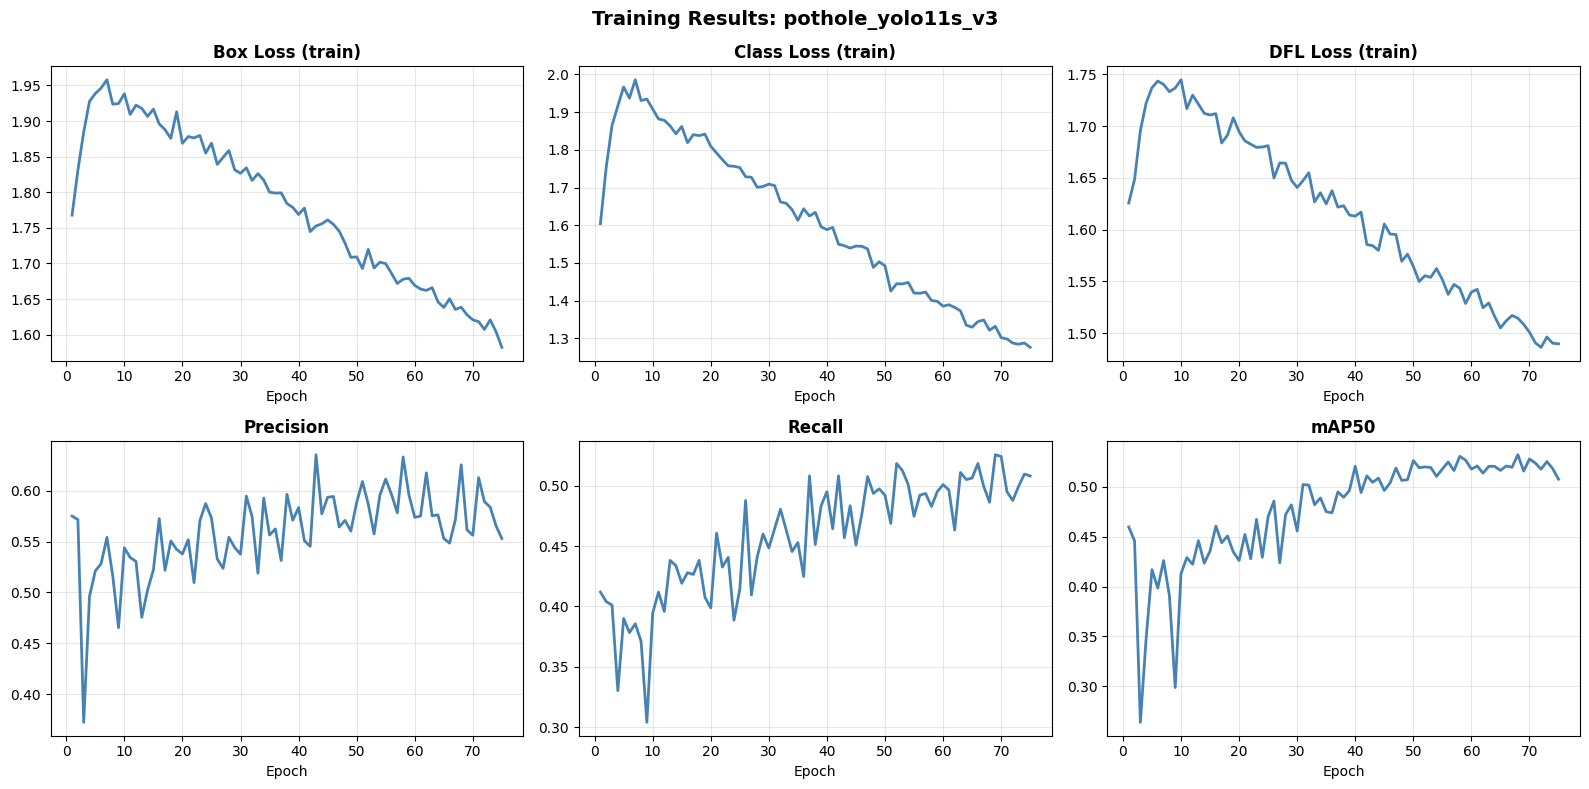

✅ Saved to: /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v3/training_summary.png

📊 pothole_yolo11s_v3 — Best Results
   mAP50      : 0.532
   Precision  : 0.635
   Recall     : 0.525
   mAP50-95   : 0.219


In [12]:
# ============================================================
# TRAINING VISUALIZATION — consistent format for team comparison
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt

RUN_NAME = "pothole_yolo11s_v3"   # change per model you're plotting
csv_path = f"{DRIVE_RUNS}/{RUN_NAME}/results.csv"

assert os.path.exists(csv_path), f"❌ results.csv not found at {csv_path}"

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(f"Training Results: {RUN_NAME}", fontsize=14, fontweight='bold')

plots = [
    ('train/box_loss', 'Box Loss (train)'),
    ('train/cls_loss', 'Class Loss (train)'),
    ('train/dfl_loss', 'DFL Loss (train)'),
    ('metrics/precision(B)', 'Precision'),
    ('metrics/recall(B)', 'Recall'),
    ('metrics/mAP50(B)', 'mAP50'),
]

for ax, (col, title) in zip(axes.flat, plots):
    if col in df.columns:
        ax.plot(df['epoch'], df[col], linewidth=2, color='steelblue')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
    else:
        ax.set_visible(False)

plt.tight_layout()
save_path = f"{DRIVE_RUNS}/{RUN_NAME}/training_summary.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved to: {save_path}")

# ── Headline numbers for your team report ──────────────────
best_map50 = df['metrics/mAP50(B)'].max()
best_precision = df['metrics/precision(B)'].max()
best_recall = df['metrics/recall(B)'].max()
best_map5095 = df['metrics/mAP50-95(B)'].max() if 'metrics/mAP50-95(B)' in df.columns else None

print(f"\n📊 {RUN_NAME} — Best Results")
print(f"   mAP50      : {best_map50:.3f}")
print(f"   Precision  : {best_precision:.3f}")
print(f"   Recall     : {best_recall:.3f}")
if best_map5095 is not None:
    print(f"   mAP50-95   : {best_map5095:.3f}")

**Standard confusion matrix + PR curve**


📊 Confusion Matrix


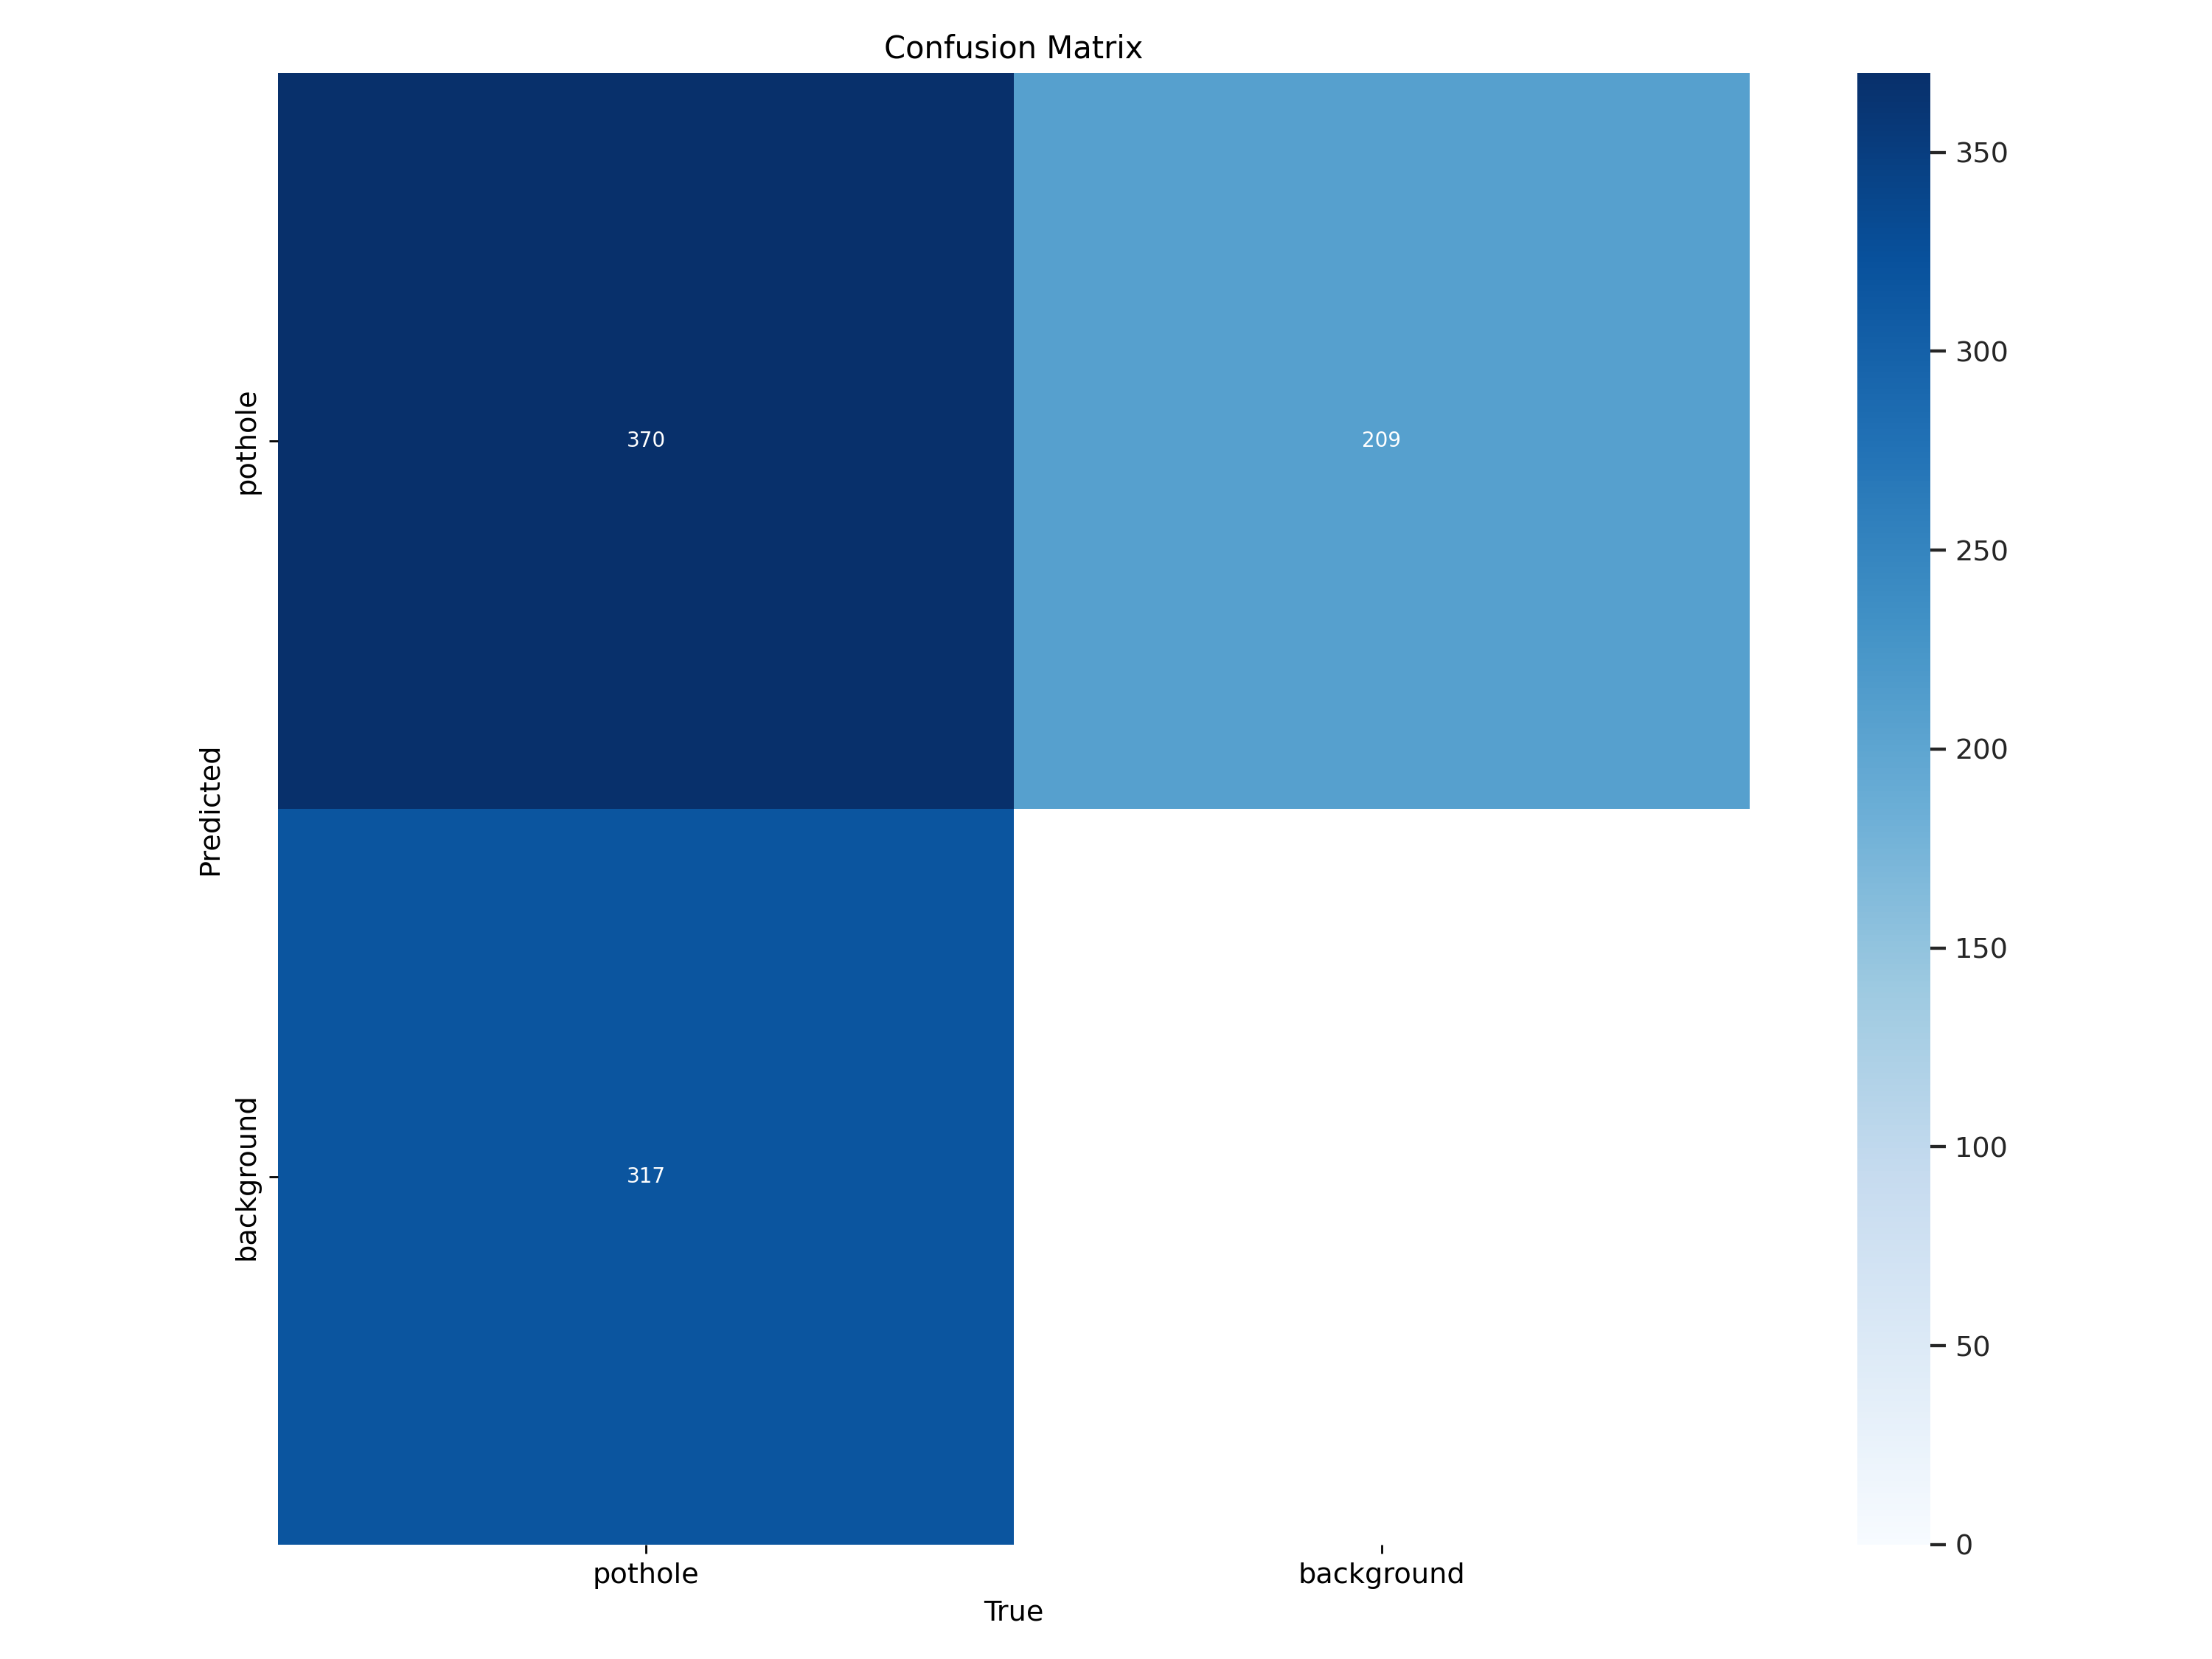


📊 Precision-Recall Curve


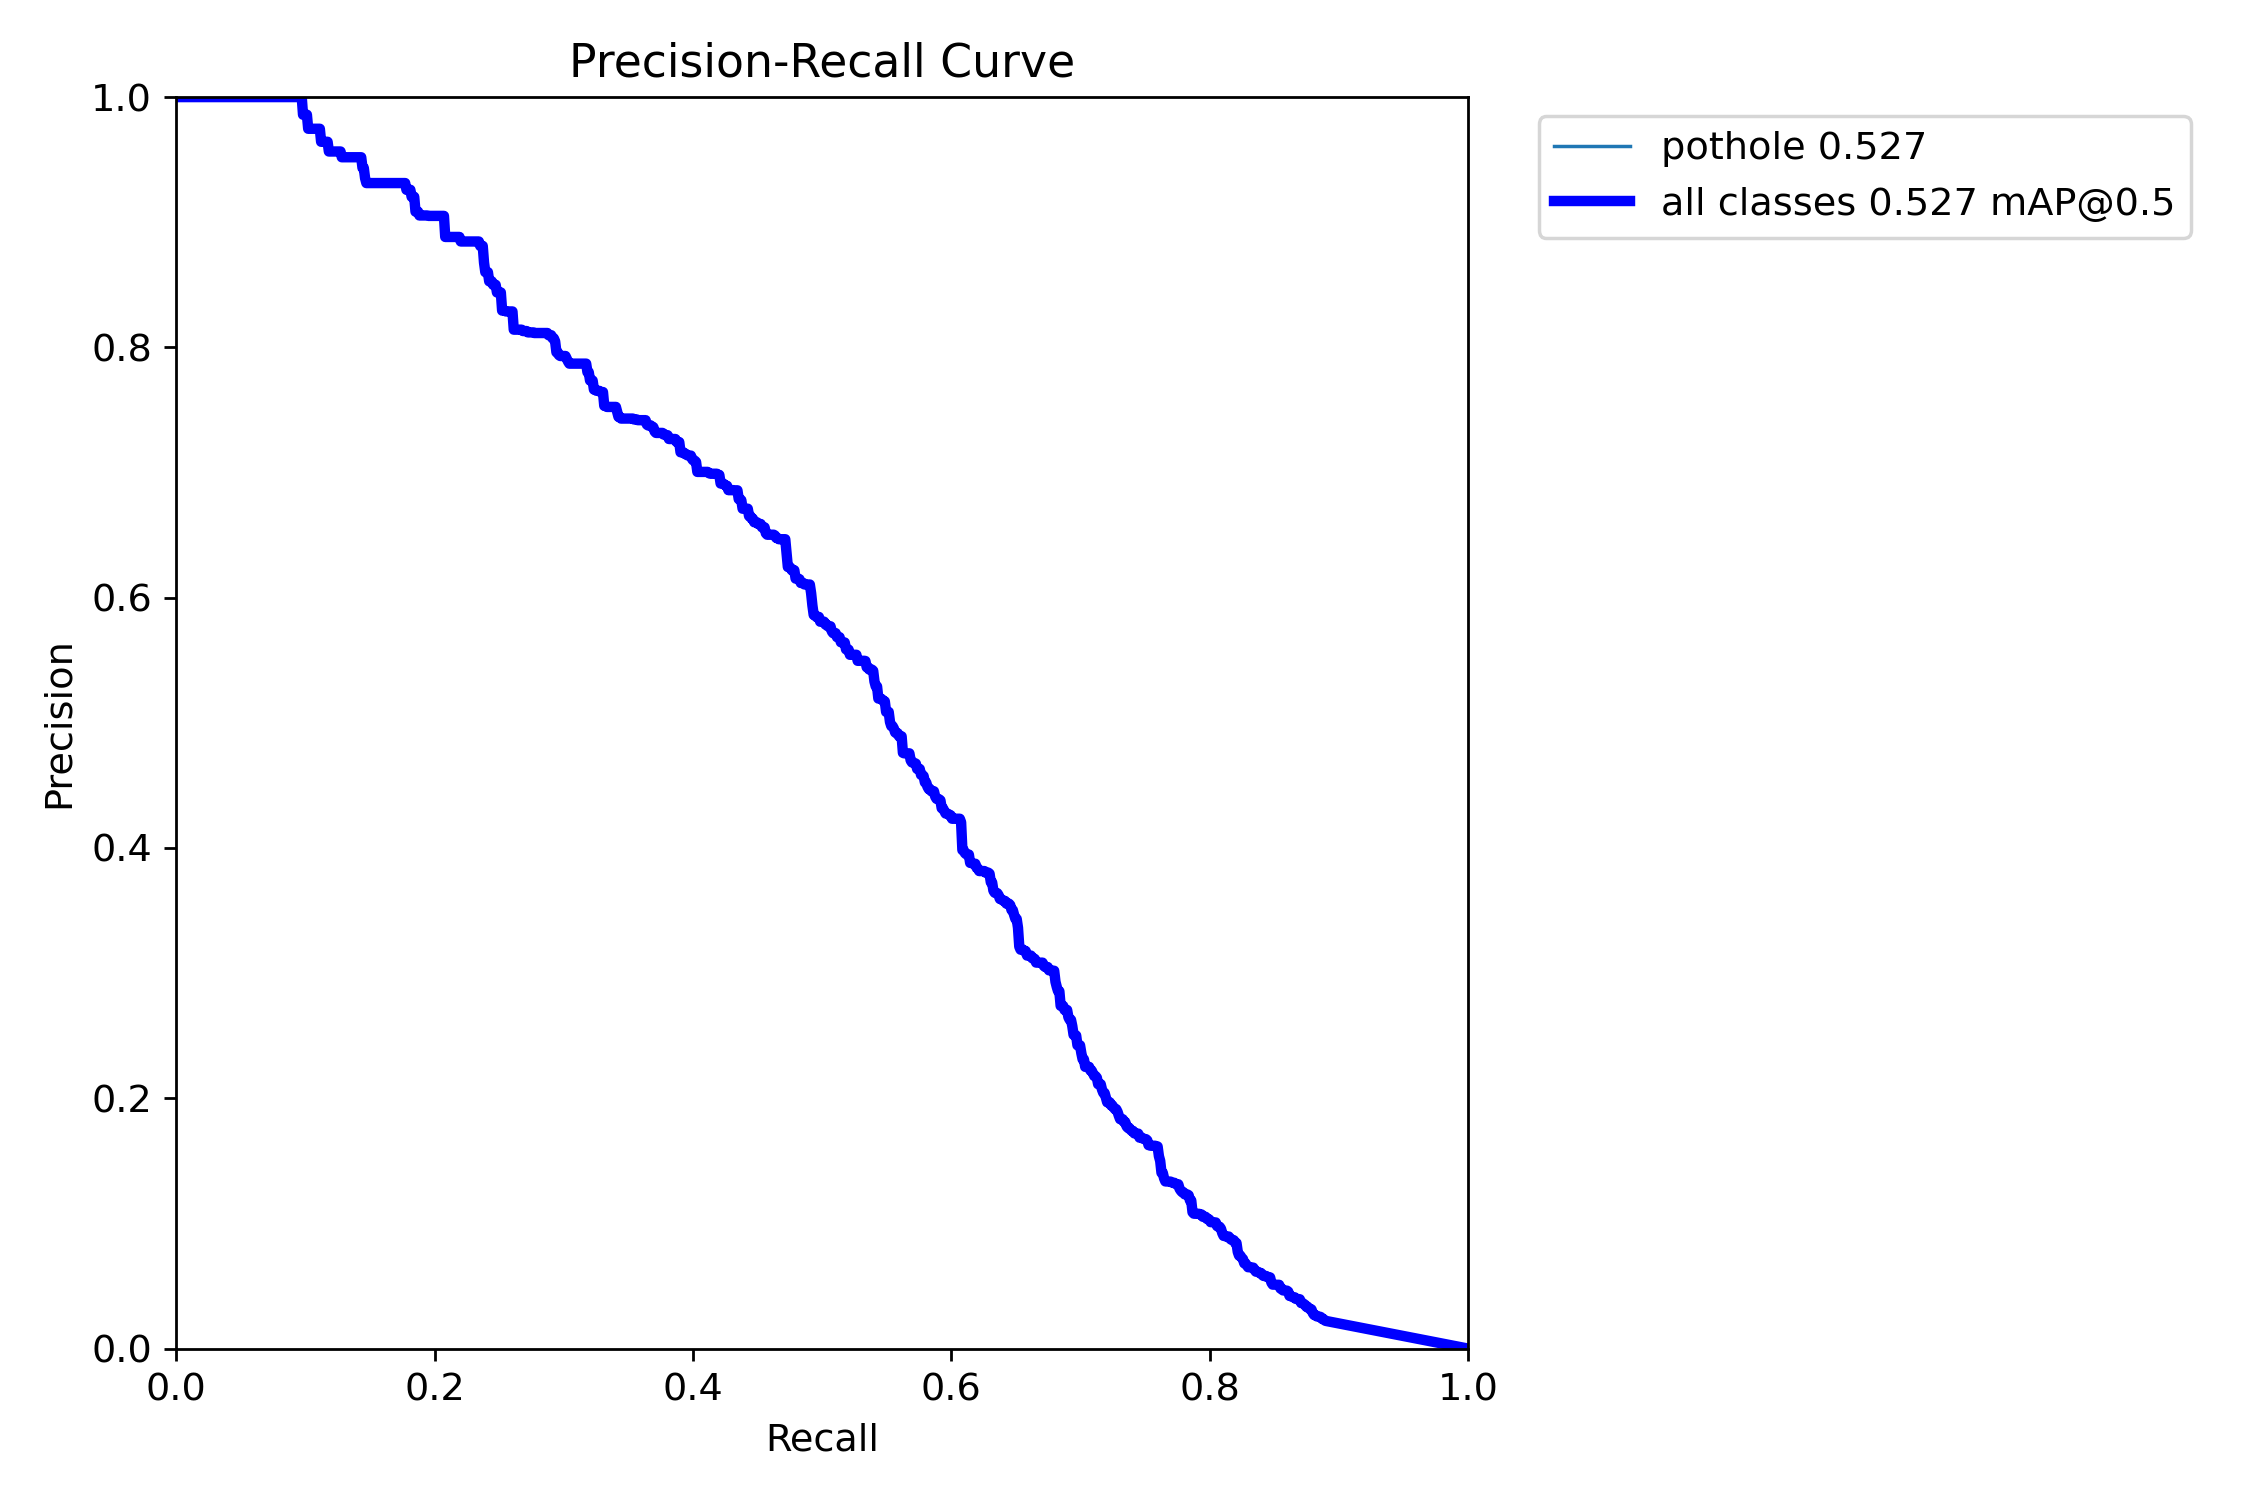


📊 F1 Score Curve


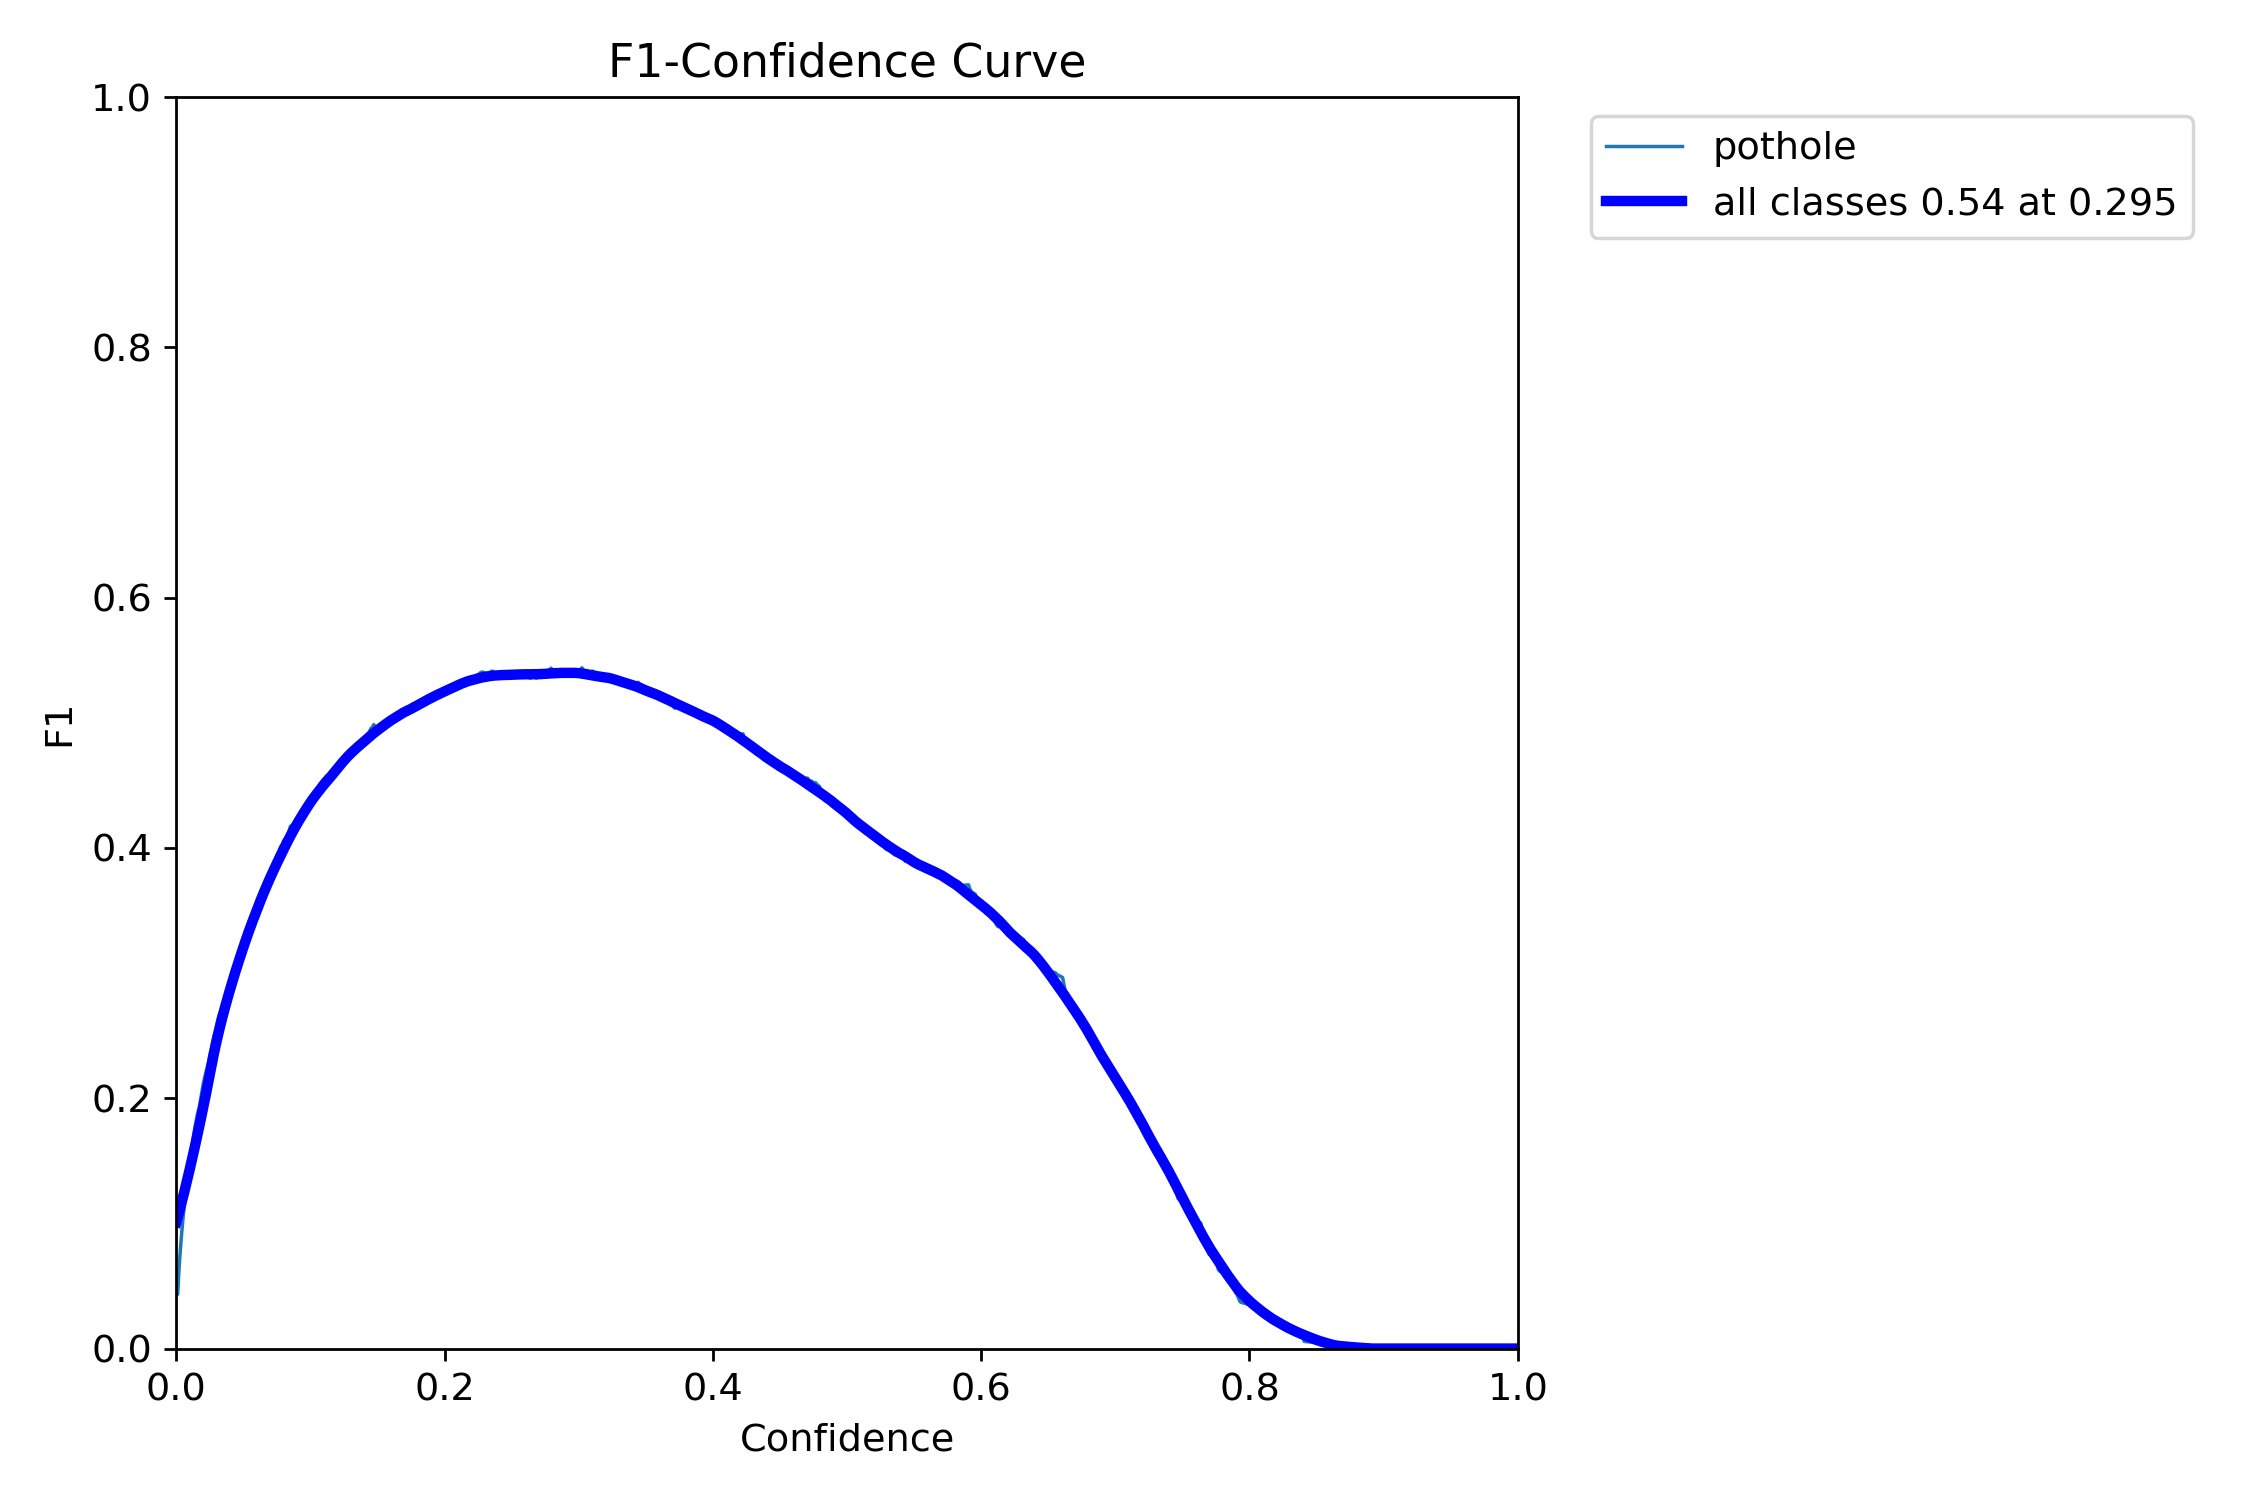


📊 Sample Validation Predictions


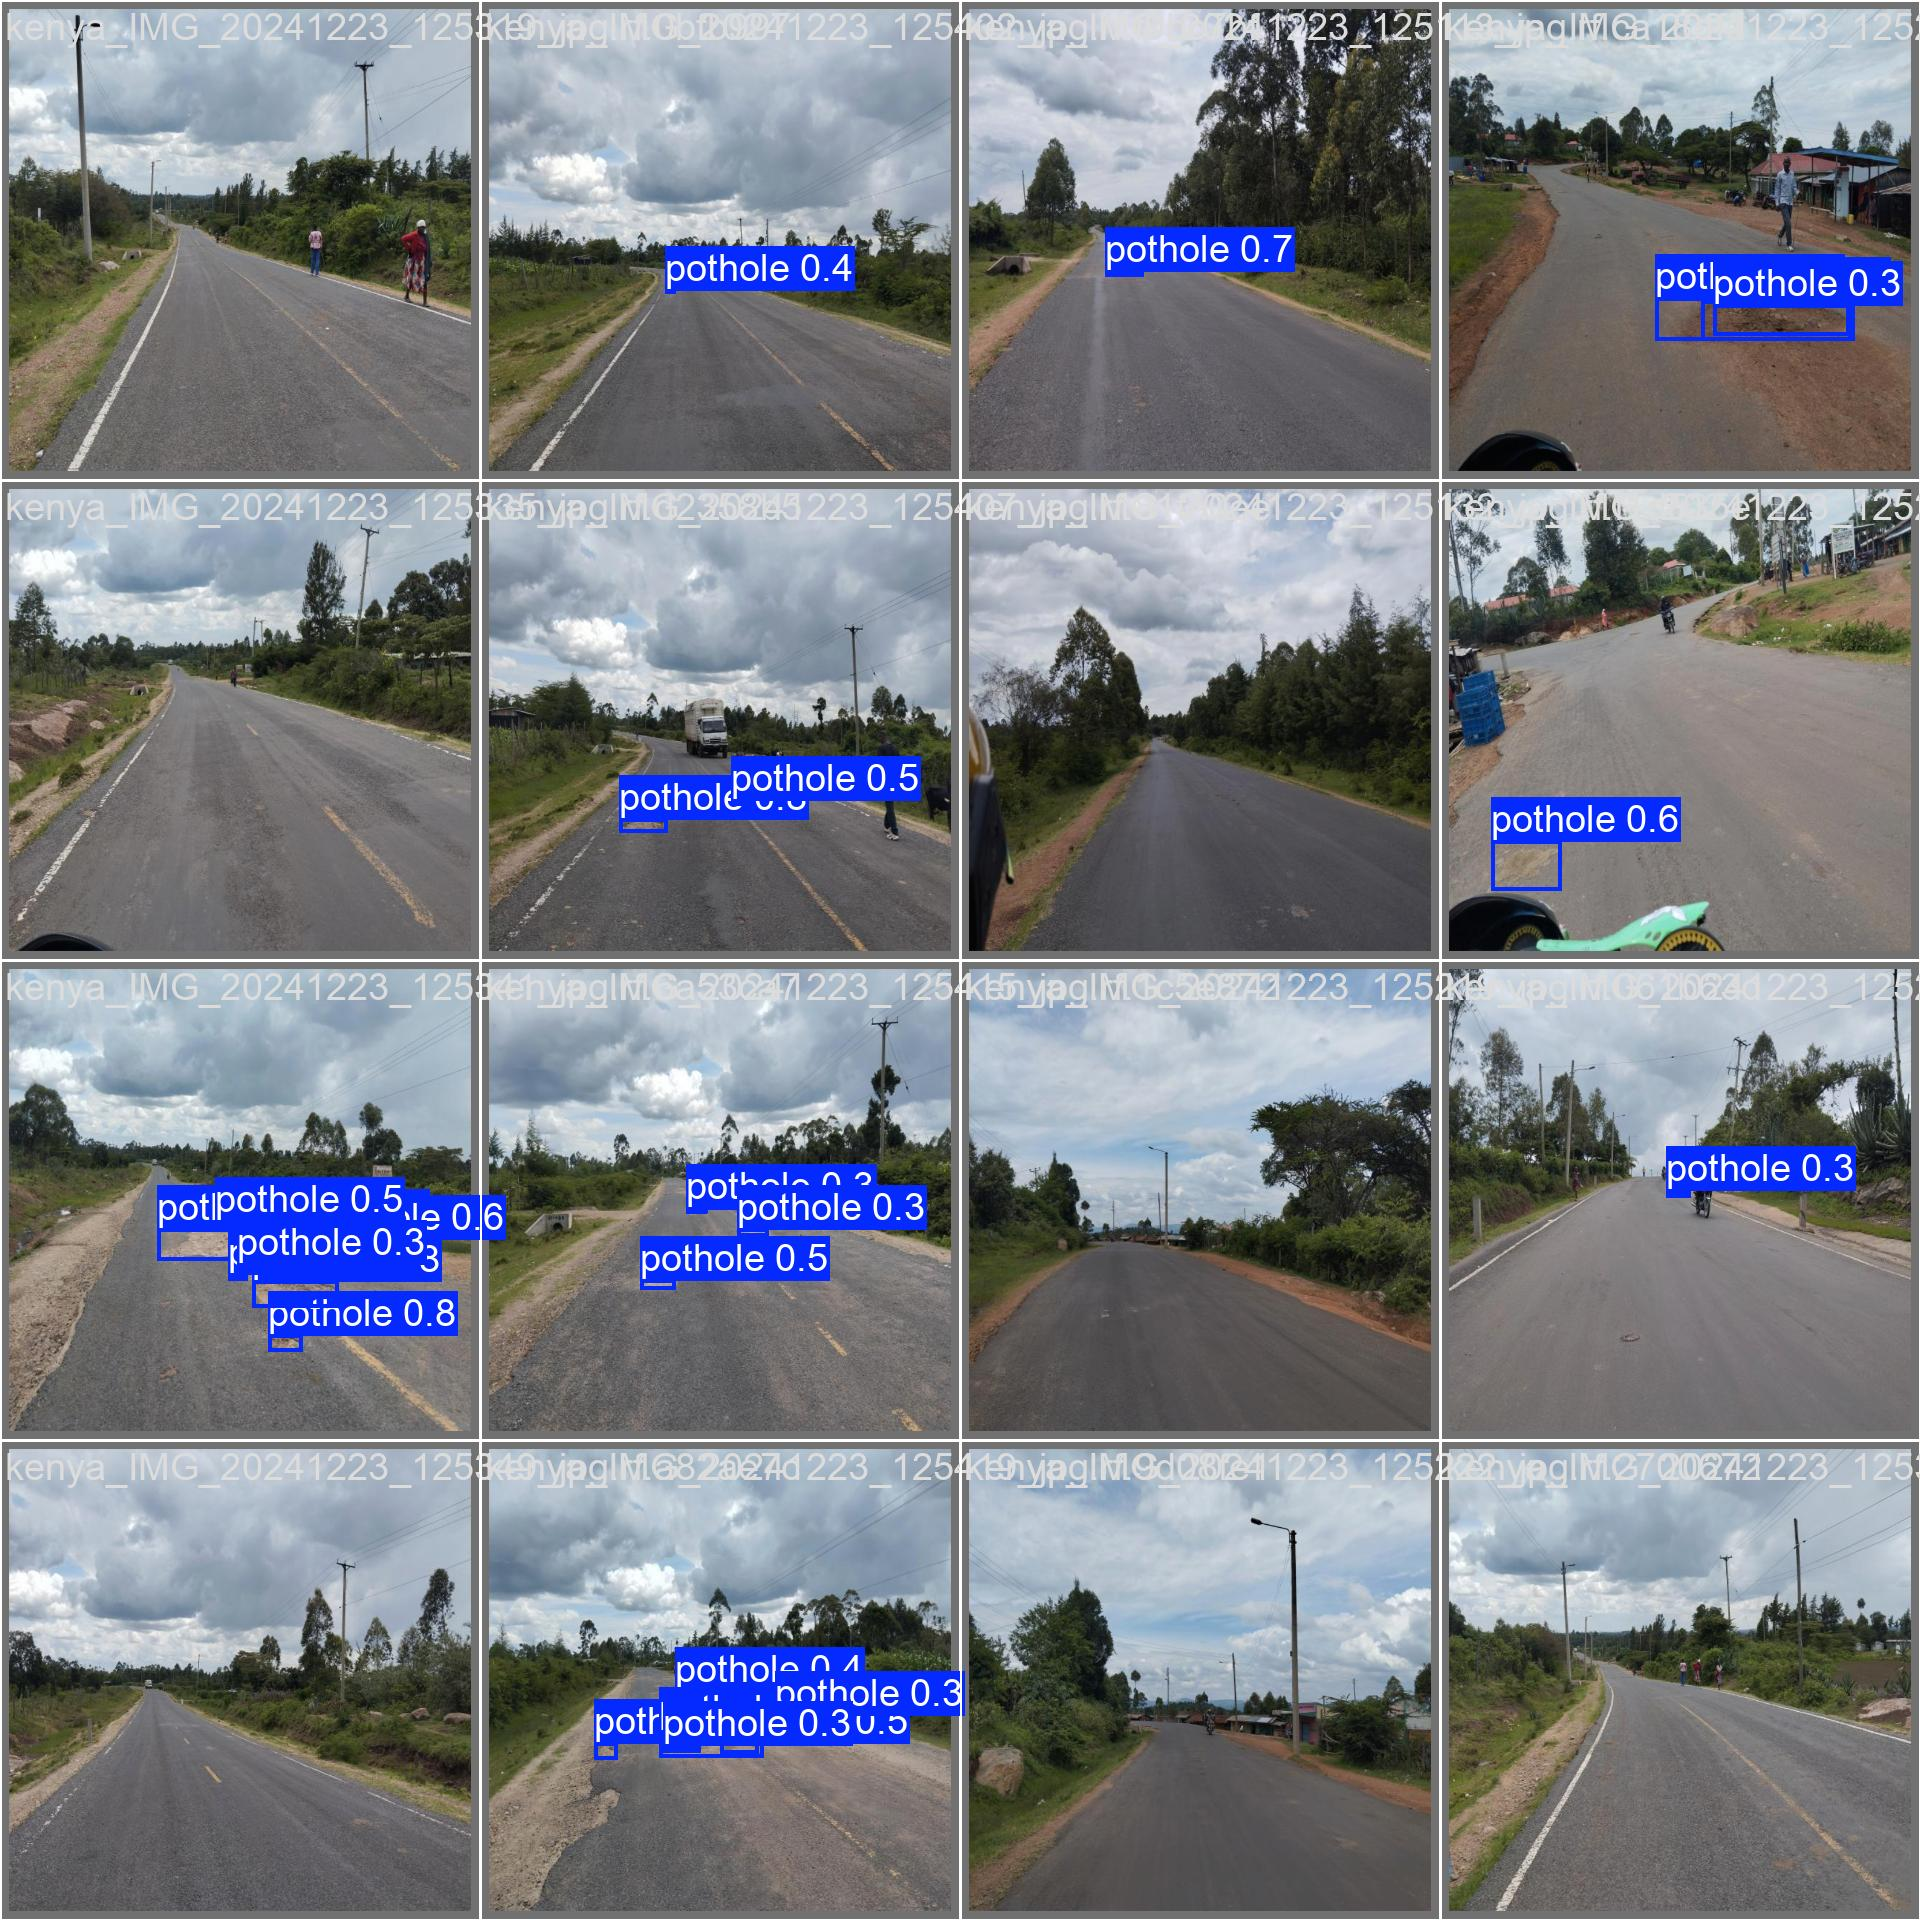

In [13]:
# ============================================================
# VIEW ULTRALYTICS' OWN CHARTS (confusion matrix, PR curve, etc.)
# ============================================================
from IPython.display import Image as IPyImage, display

RUN_NAME = "pothole_yolo11s_v3"
RUN_DIR  = f"{DRIVE_RUNS}/{RUN_NAME}"

charts = {
    'confusion_matrix.png': 'Confusion Matrix',
    'PR_curve.png':         'Precision-Recall Curve',
    'F1_curve.png':         'F1 Score Curve',
    'val_batch0_pred.jpg':  'Sample Validation Predictions',
}

for filename, title in charts.items():
    fpath = f"{RUN_DIR}/{filename}"
    if os.path.exists(fpath):
        print(f"\n{'='*50}\n📊 {title}\n{'='*50}")
        display(IPyImage(filename=fpath, width=700))
    else:
        print(f"⚠️  {filename} not found")


📊 Loss Curves + mAP over 60 Epochs


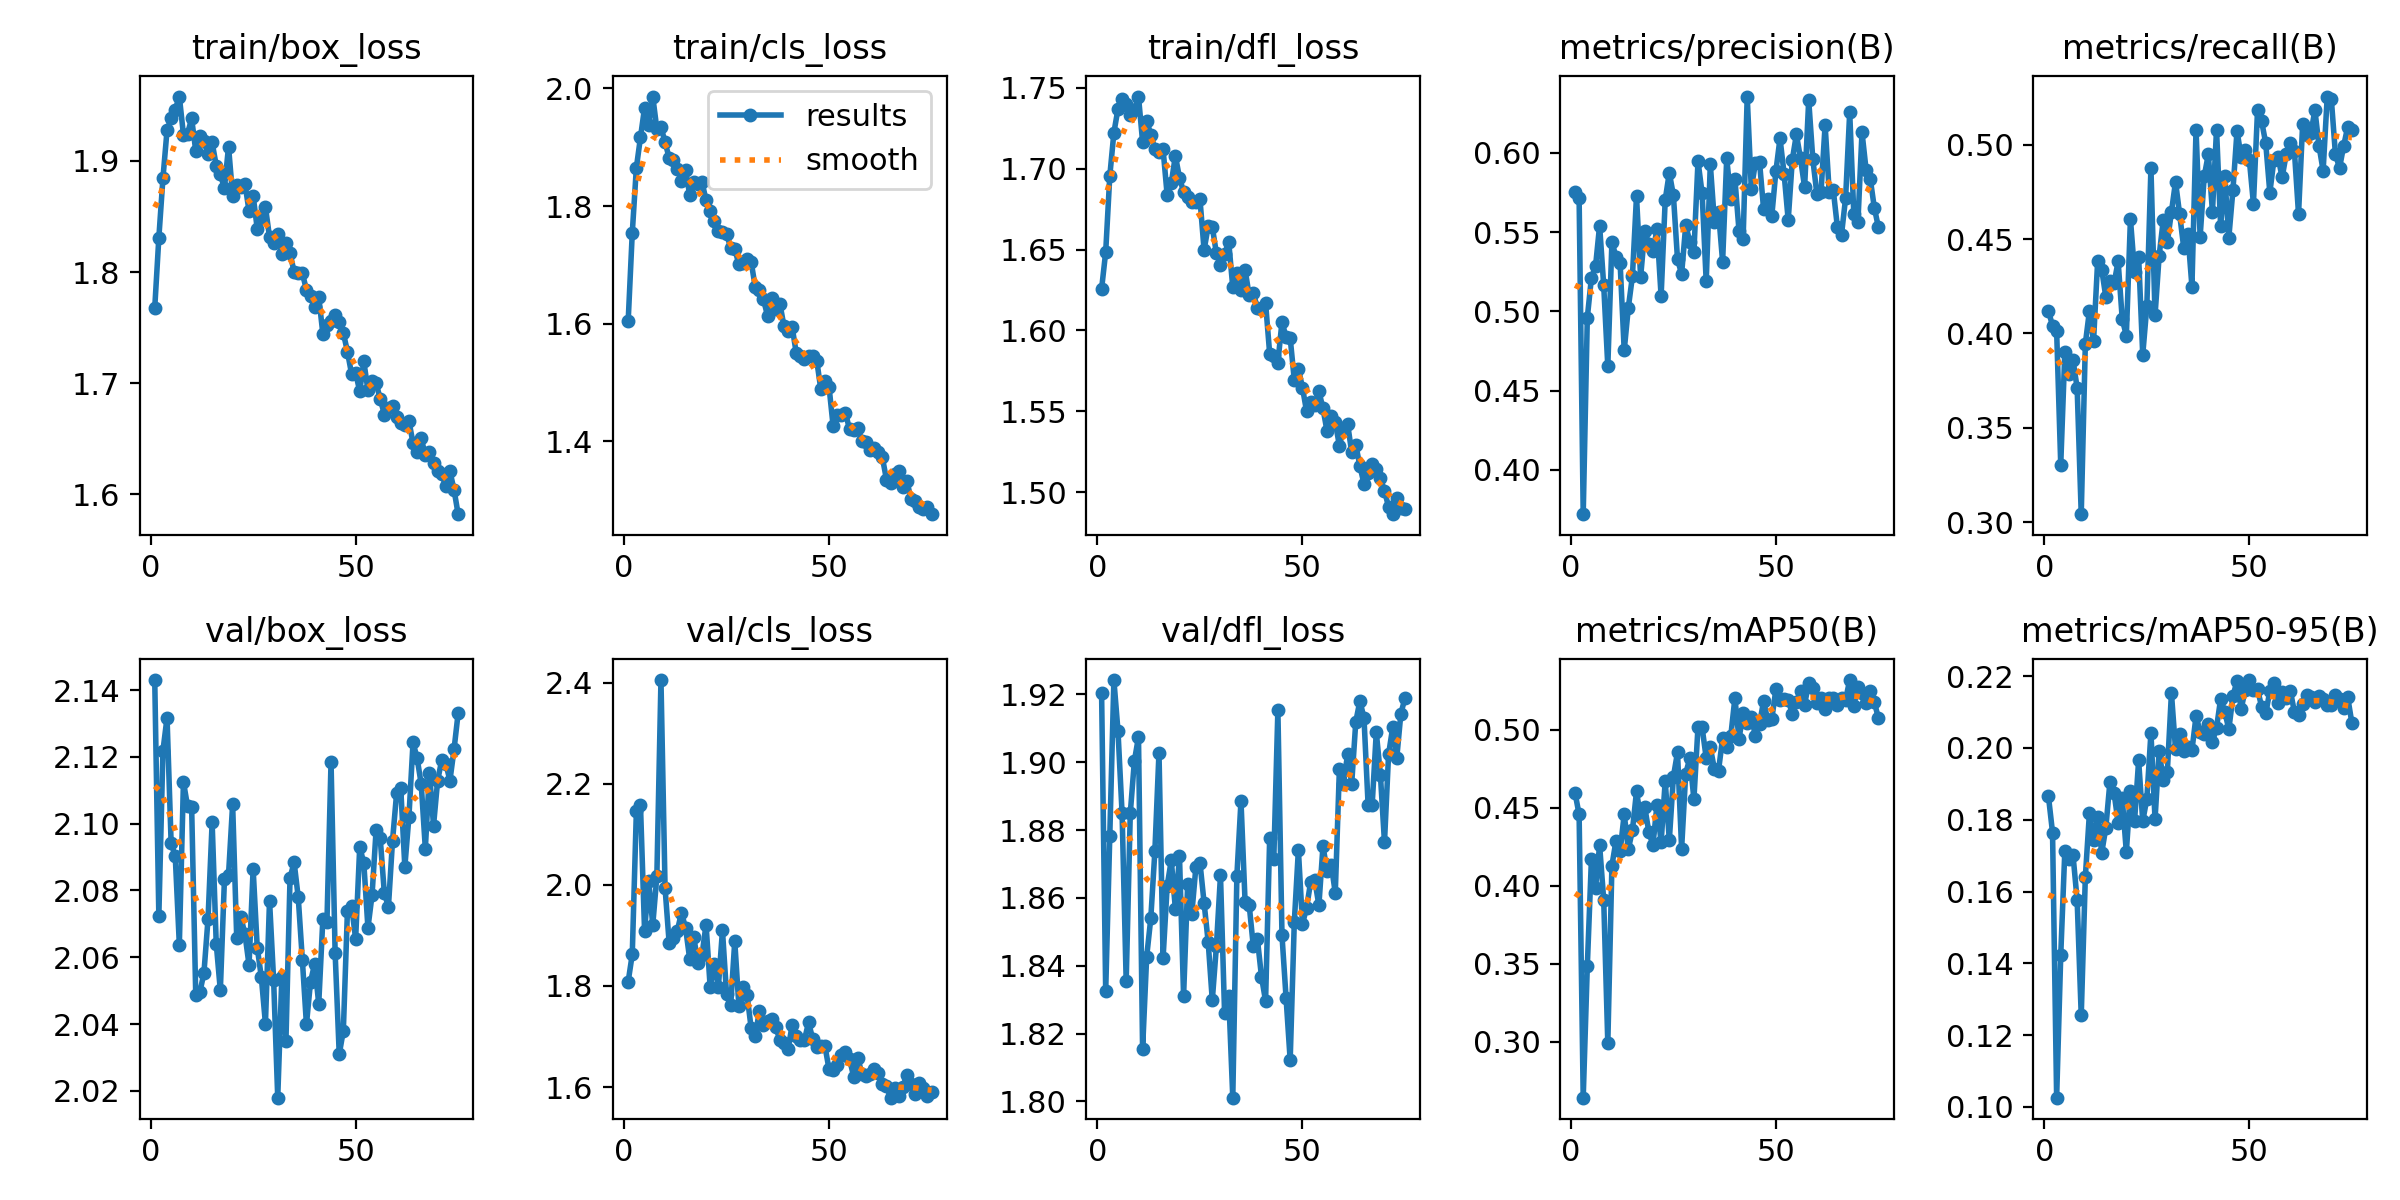


📊 Confusion Matrix


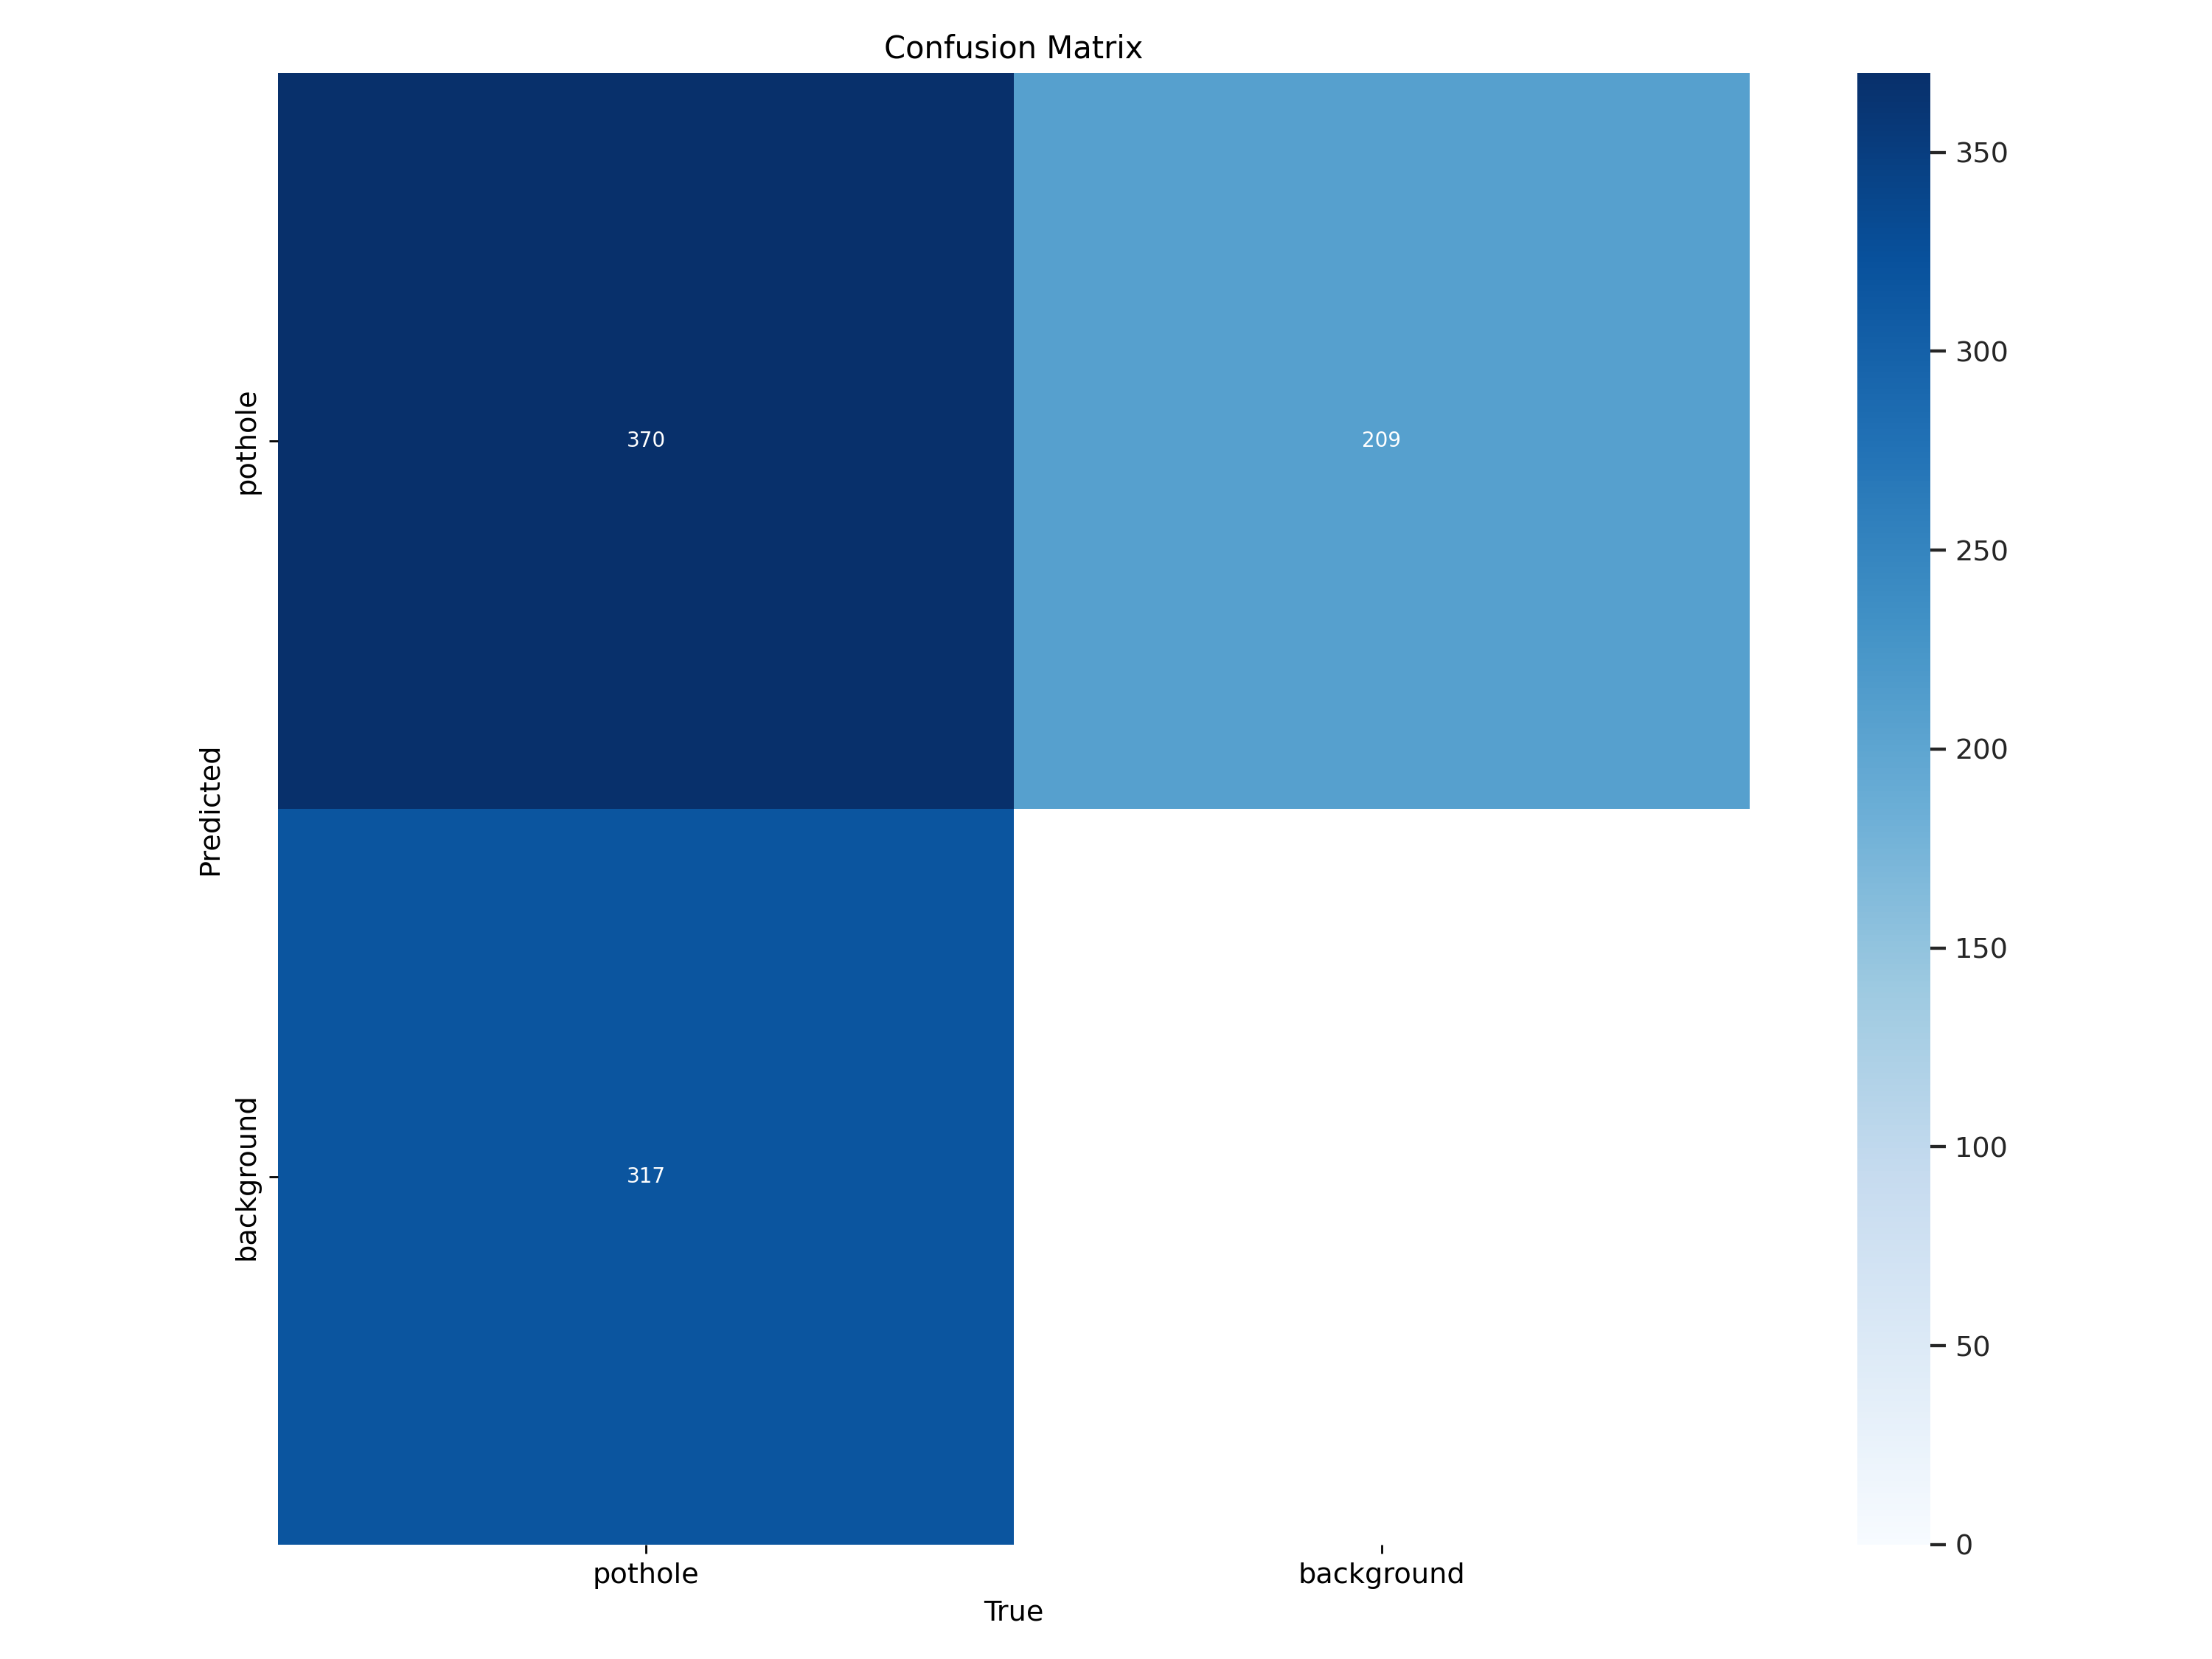


📊 Sample Validation Predictions


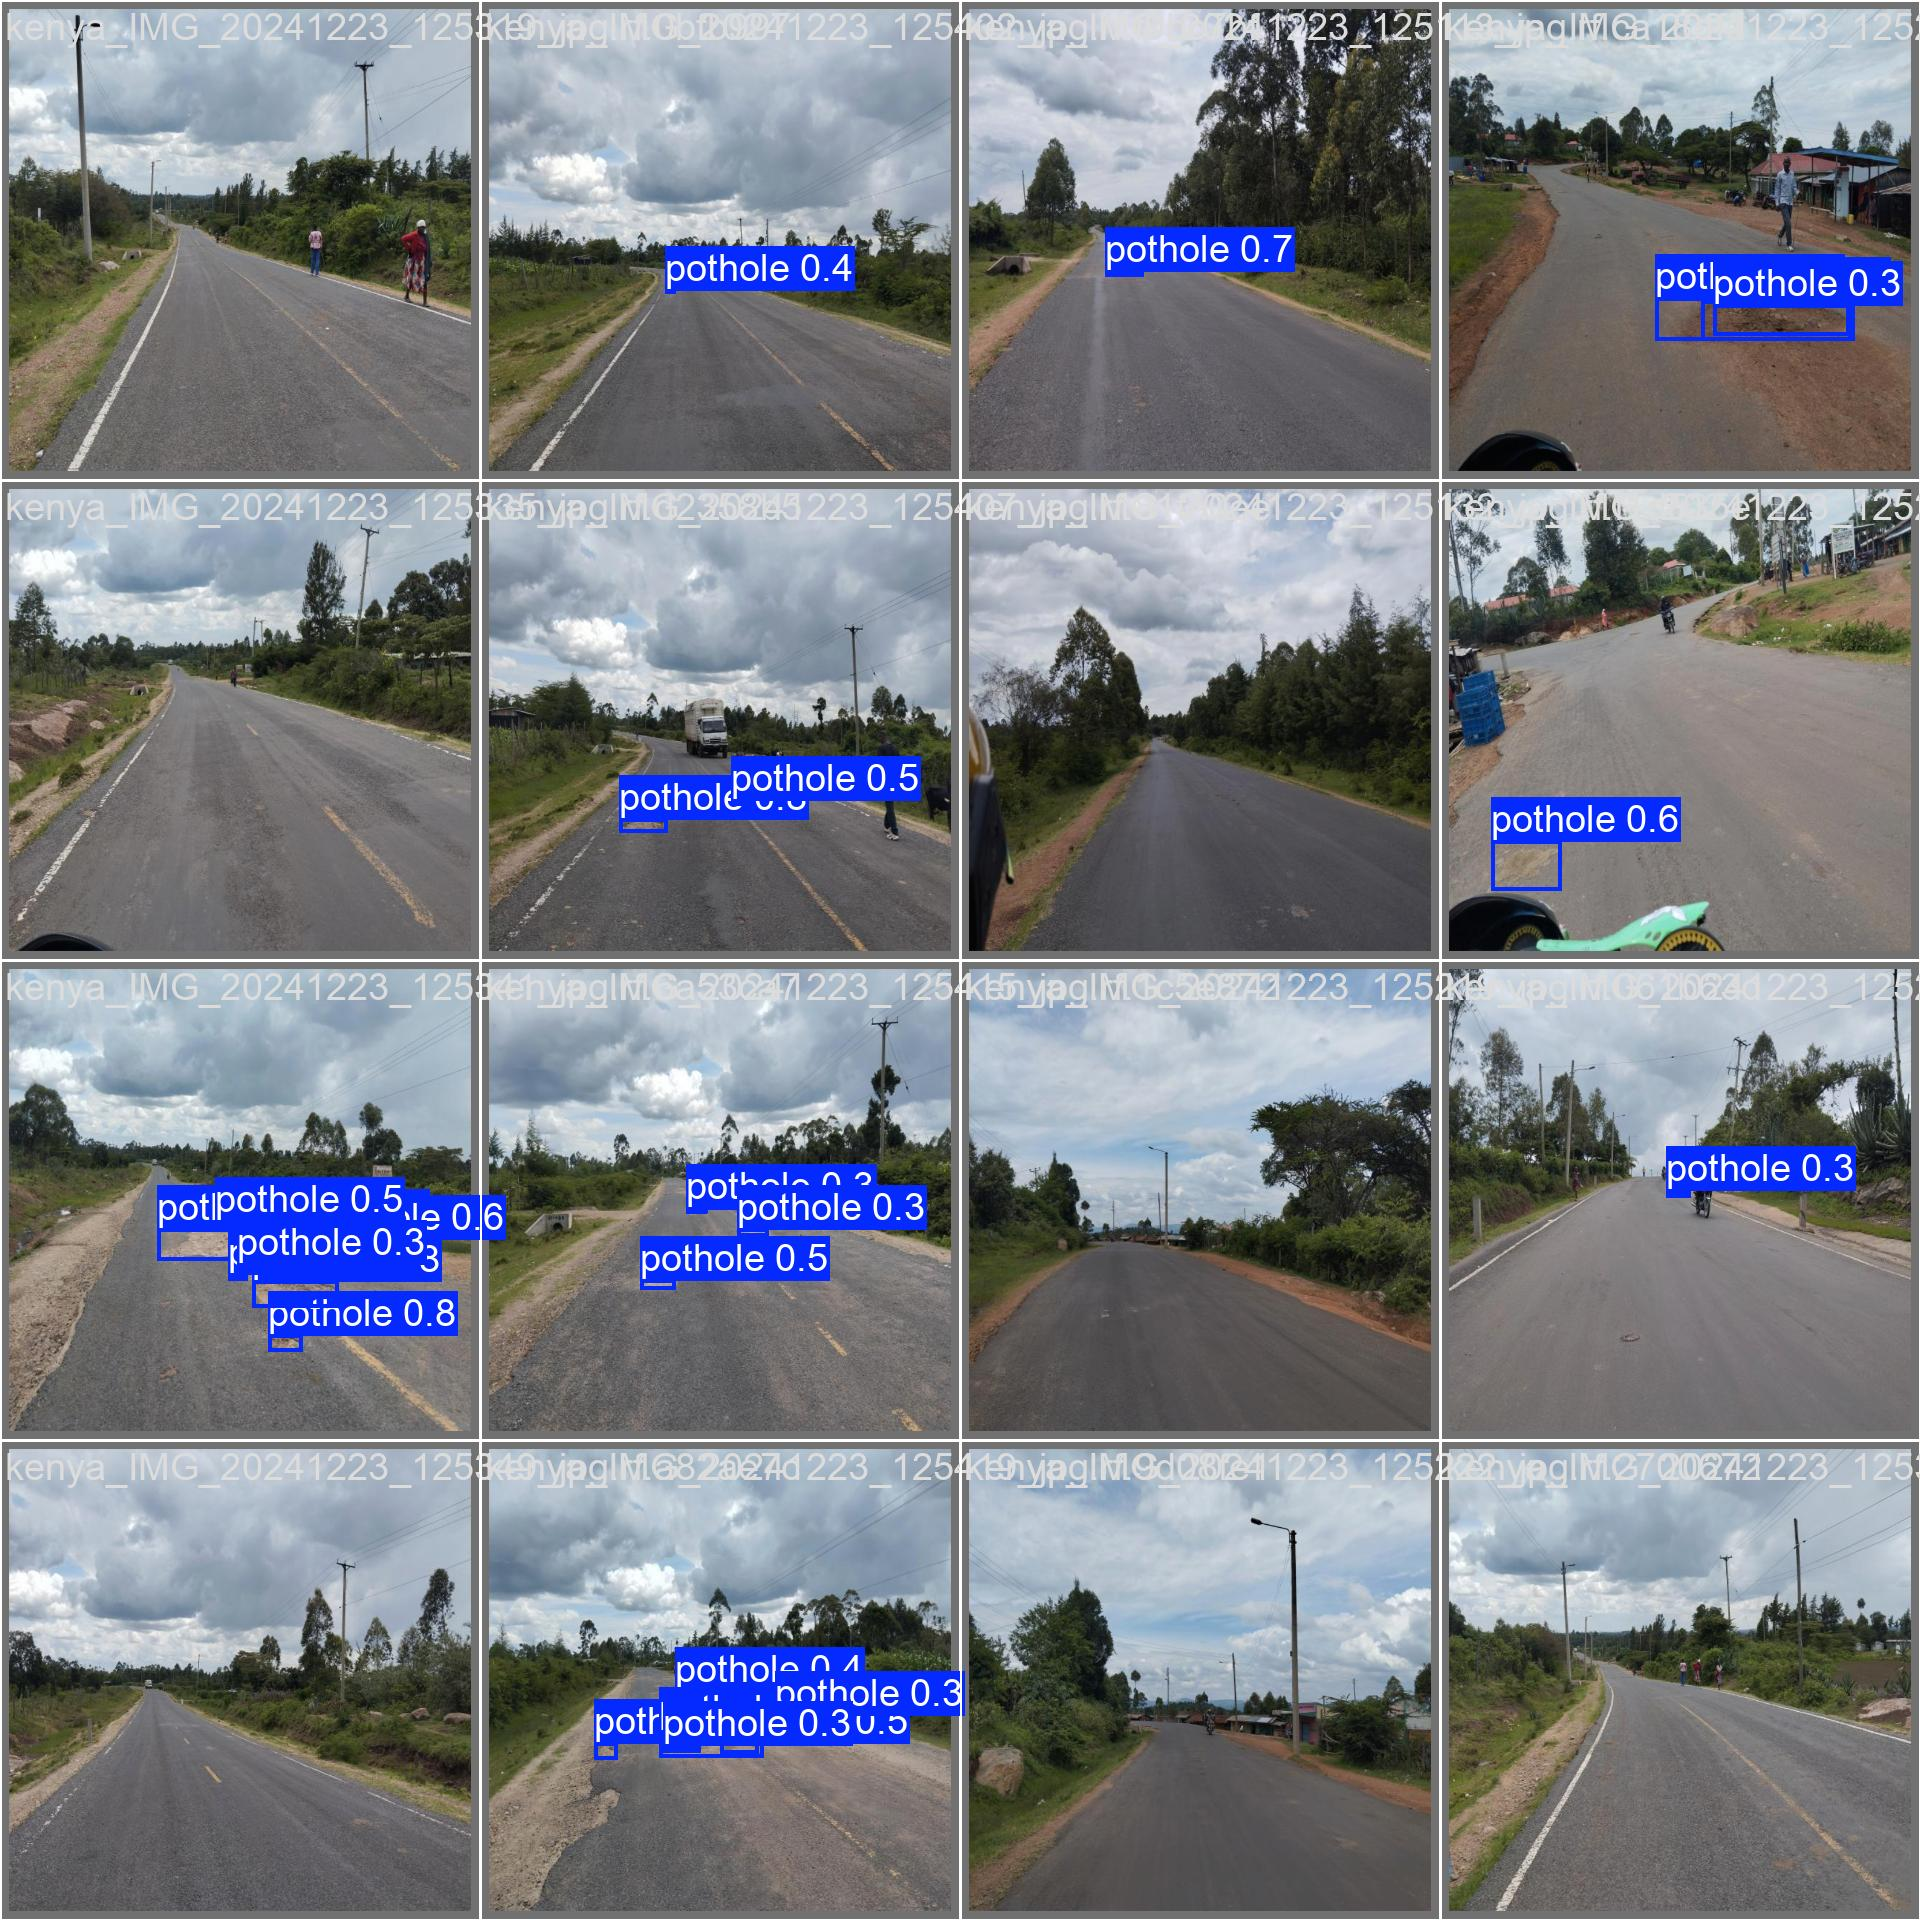


📊 Precision-Recall Curve


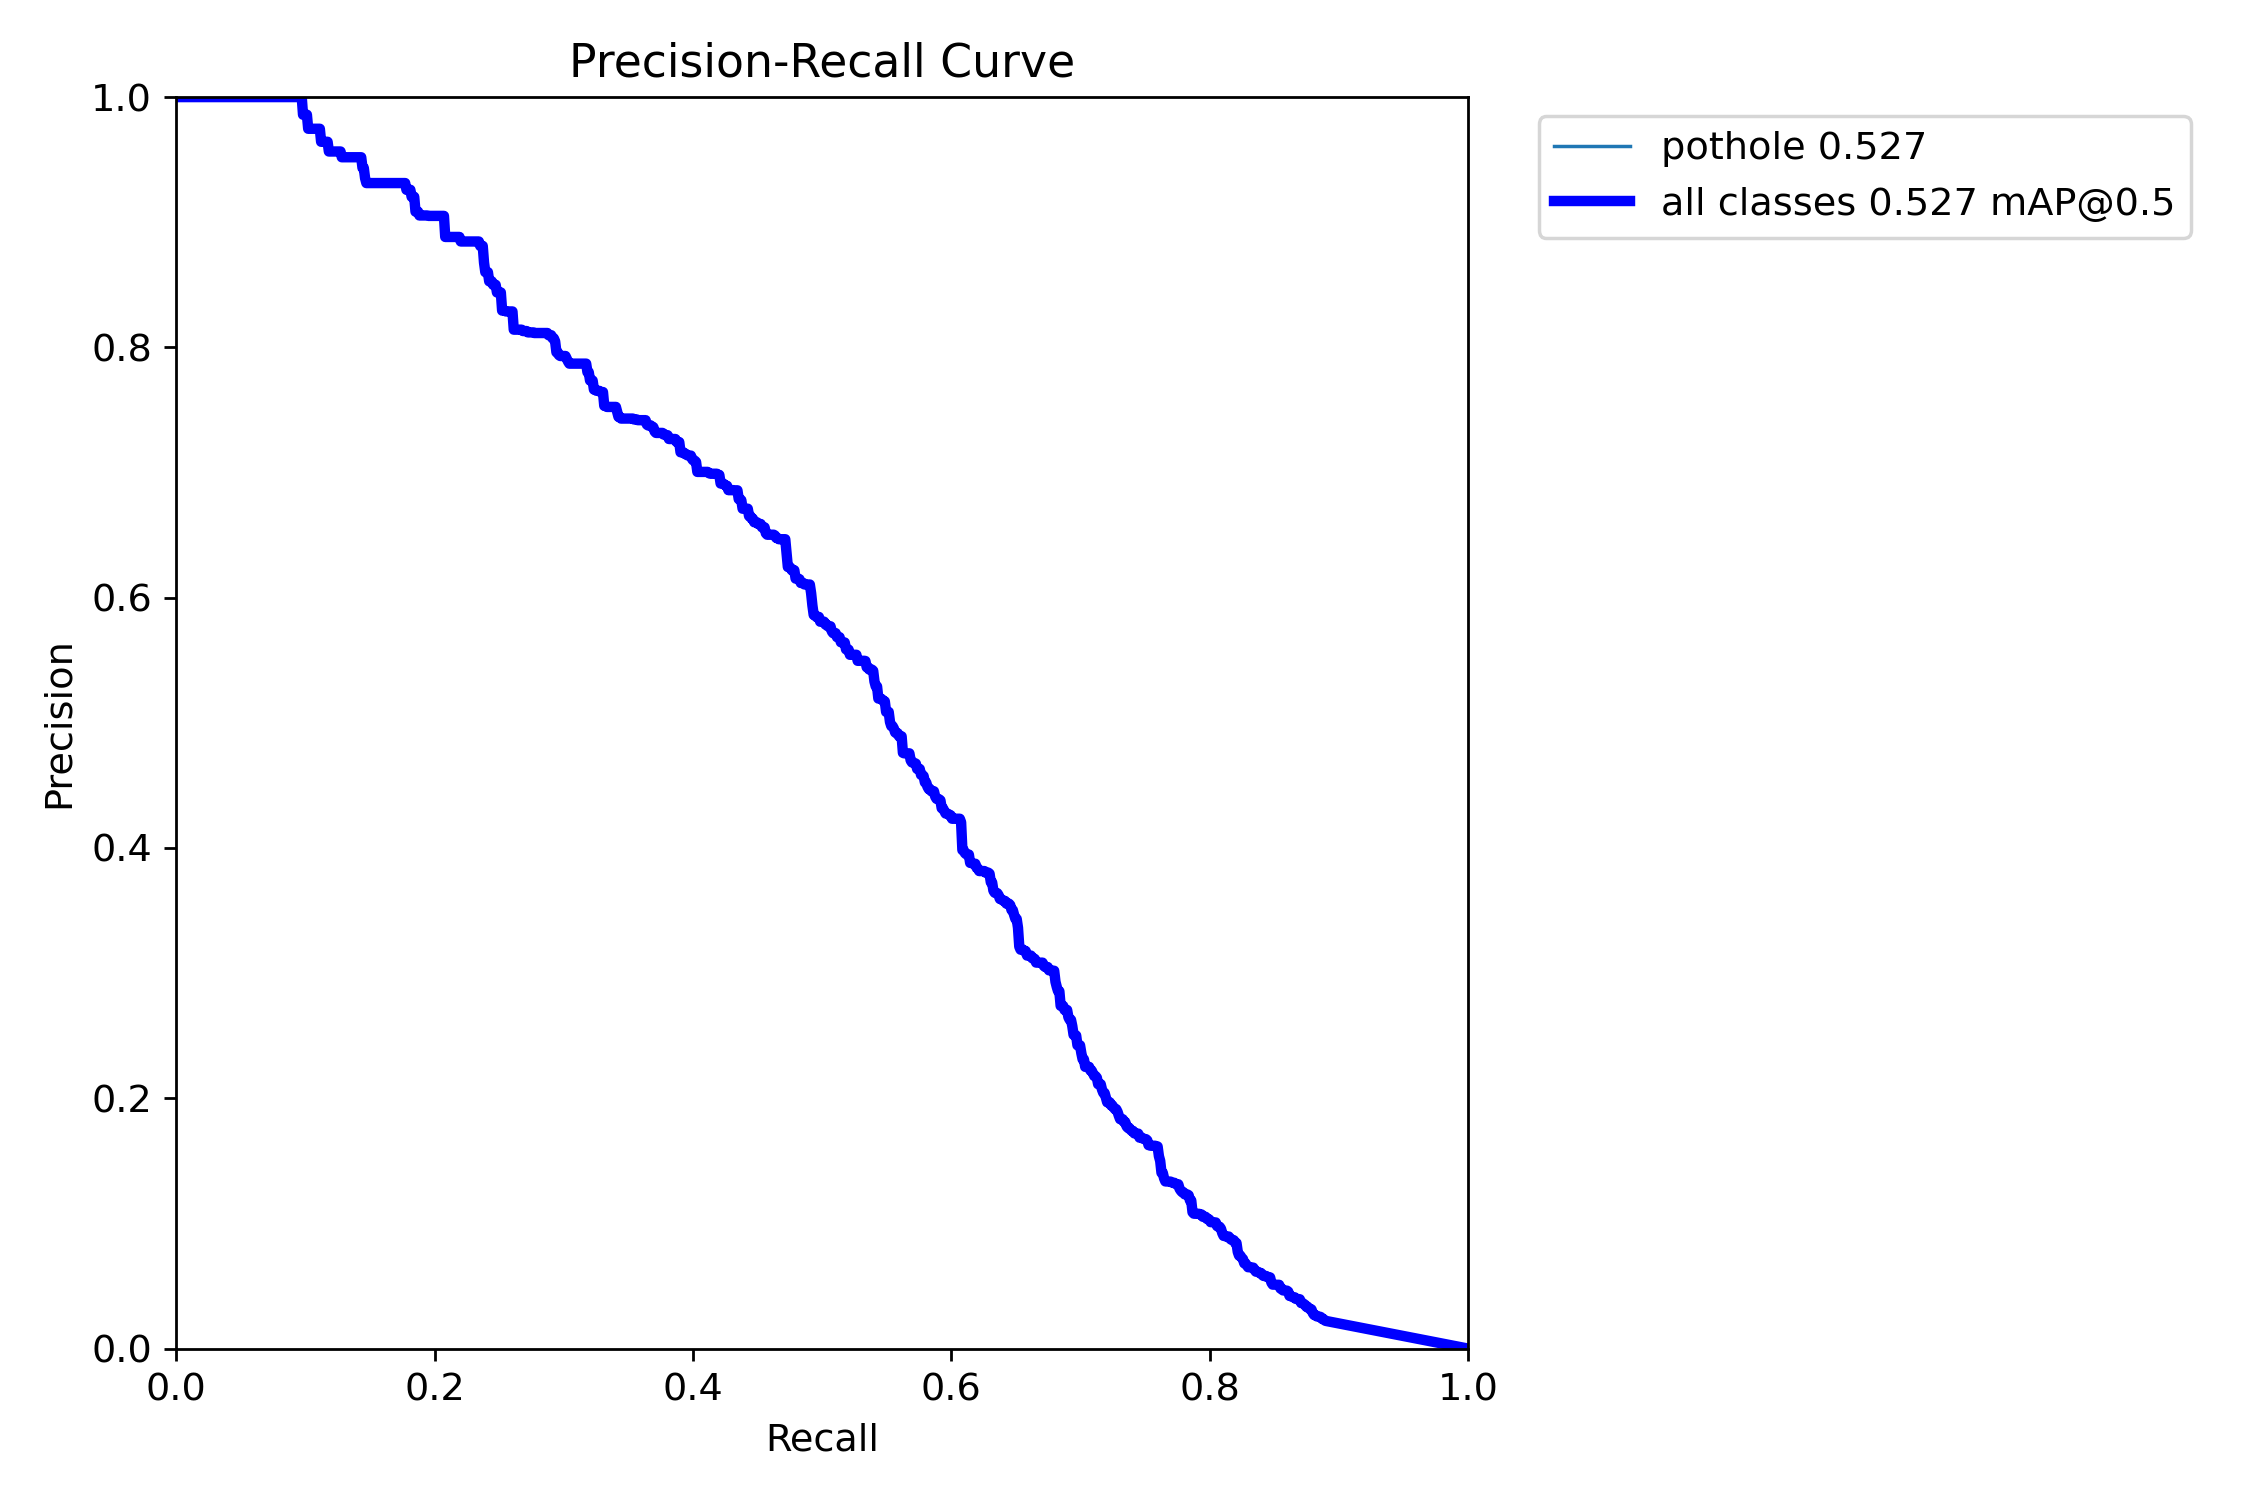


📊 F1 Score Curve


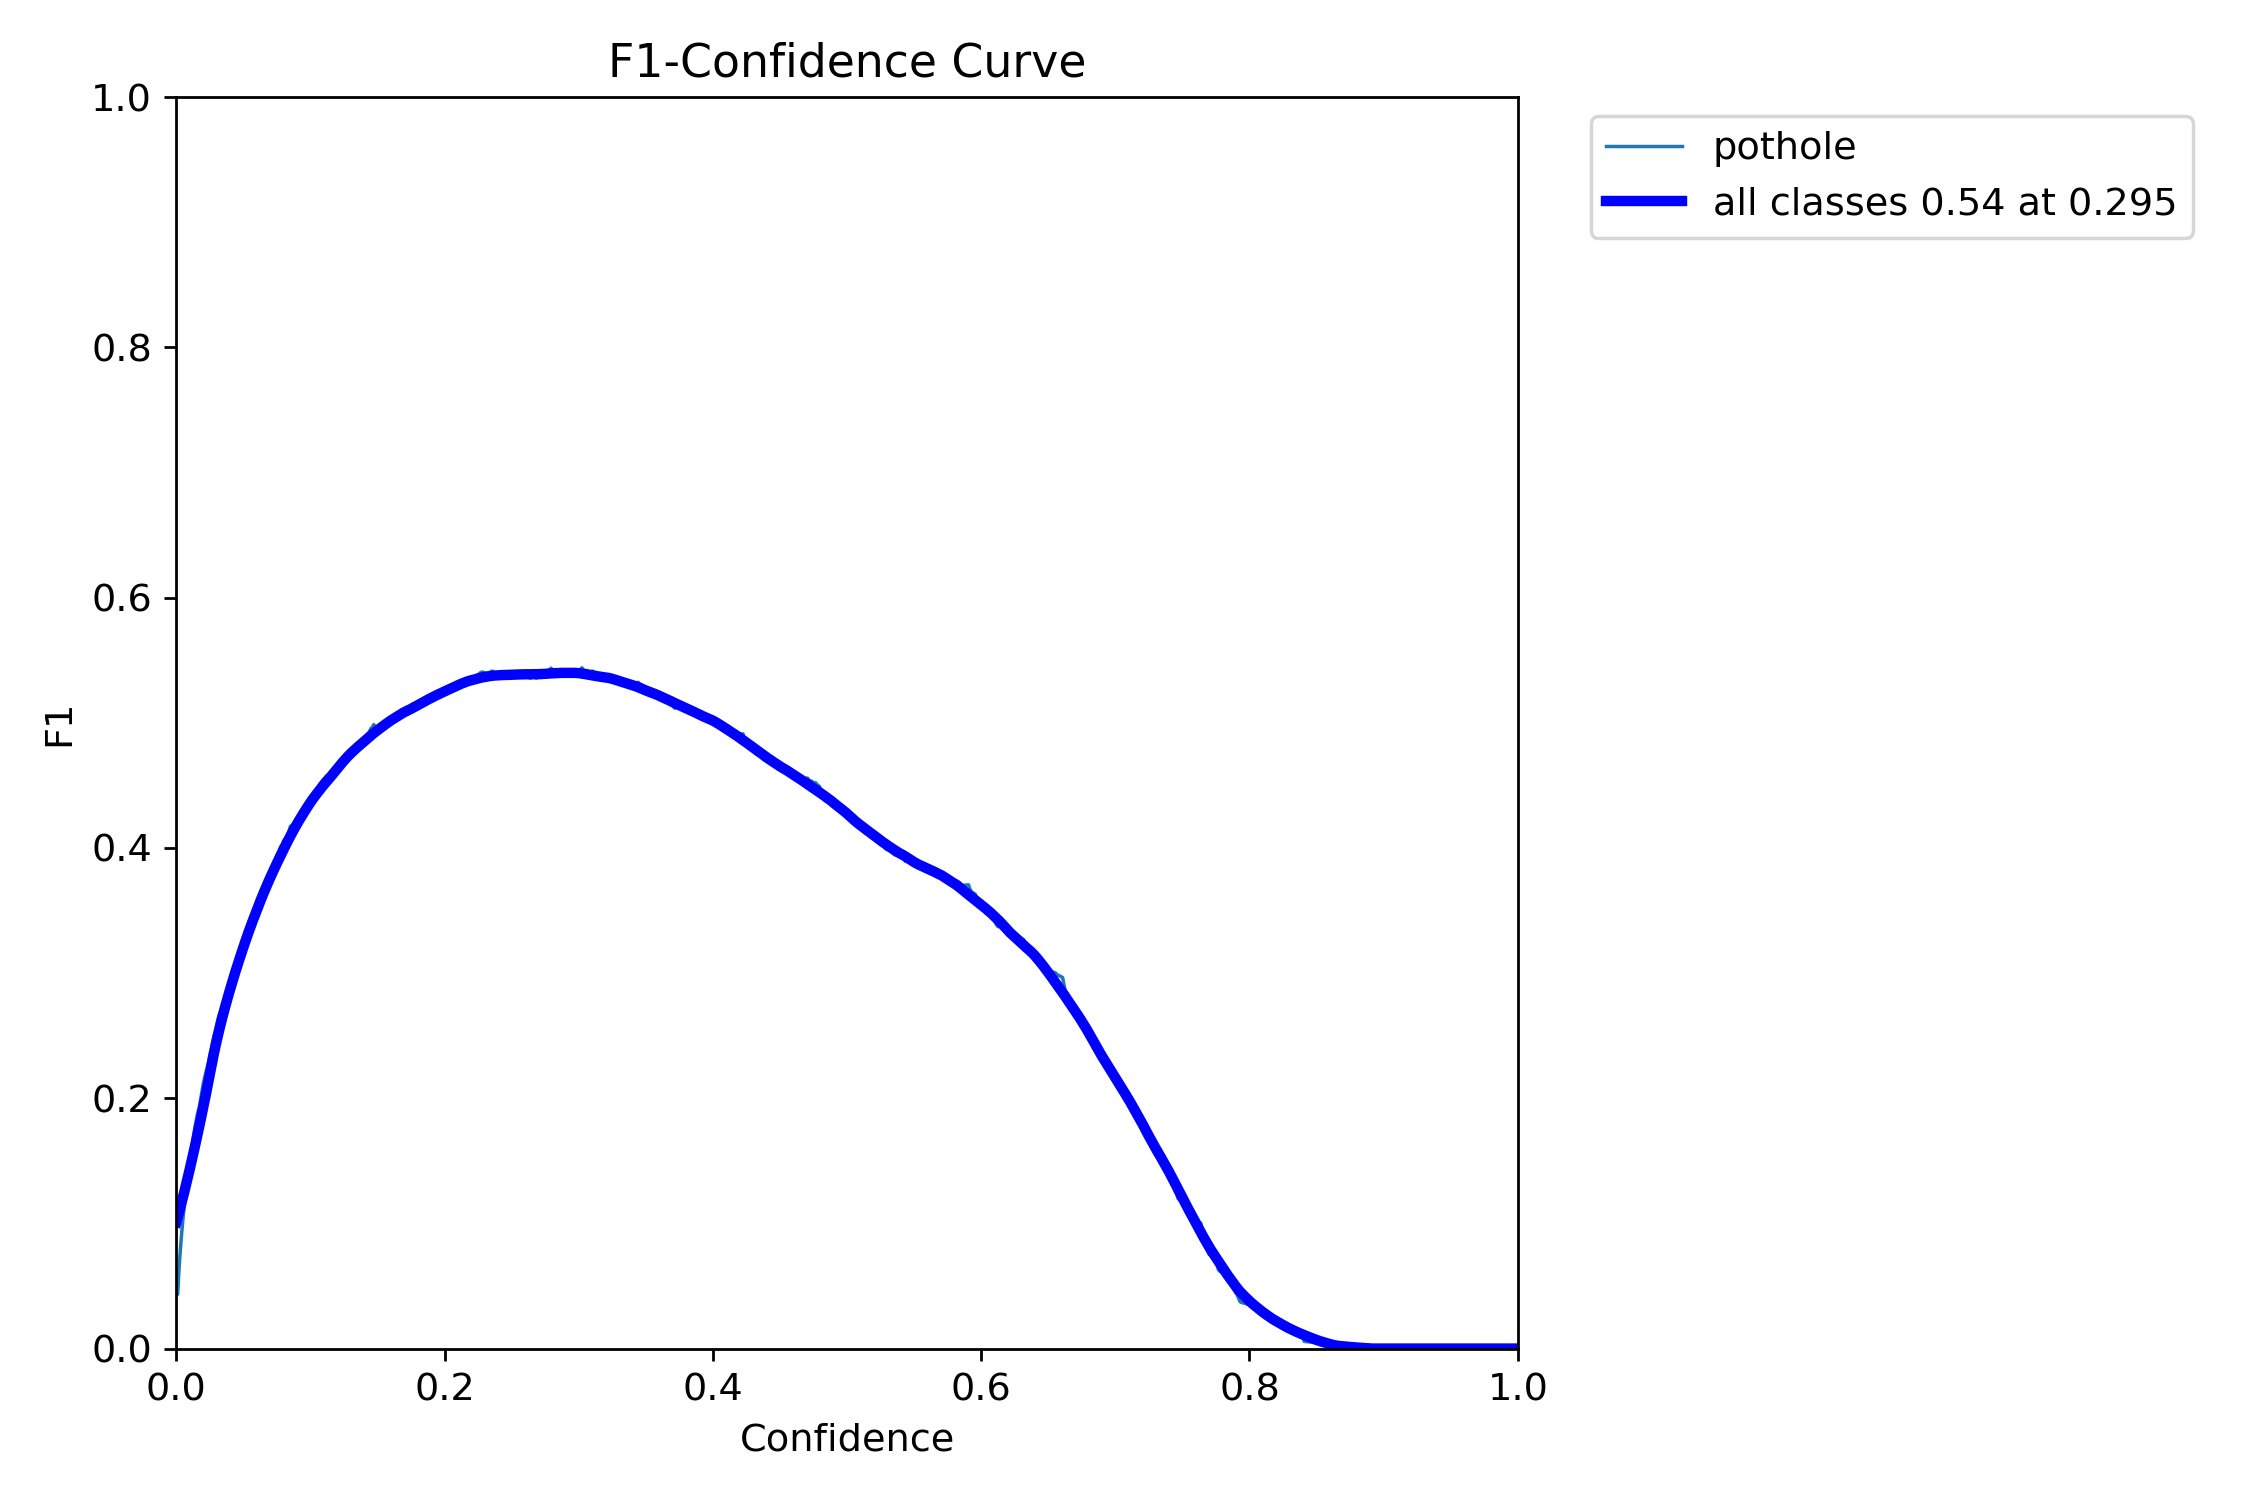

In [16]:
# ============================================================
# VIEW TRAINING CHARTS
# ============================================================
# These charts show how your model improved over 60 epochs.
# They are saved on your Drive from the completed training run.

from IPython.display import Image as IPyImage, display
import os

charts = {
    'results.png':          'Loss Curves + mAP over 60 Epochs',
    'confusion_matrix.png': 'Confusion Matrix',
    'val_batch0_pred.jpg':  'Sample Validation Predictions',
    'PR_curve.png':         'Precision-Recall Curve',
    'F1_curve.png':         'F1 Score Curve',
}

for filename, title in charts.items():
    fpath = f"{RUN_DIR}/{filename}"
    if os.path.exists(fpath):
        print(f"\n{'='*50}")
        print(f"📊 {title}")
        print('='*50)
        display(IPyImage(filename=fpath, width=700))
    else:
        print(f"⚠️  {filename} not found")

✅ Loading results from: /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v3/


📊 Training Results: pothole_yolo11s_v3

──────────────────────────────────────────────────
Loss Curves + mAP
──────────────────────────────────────────────────


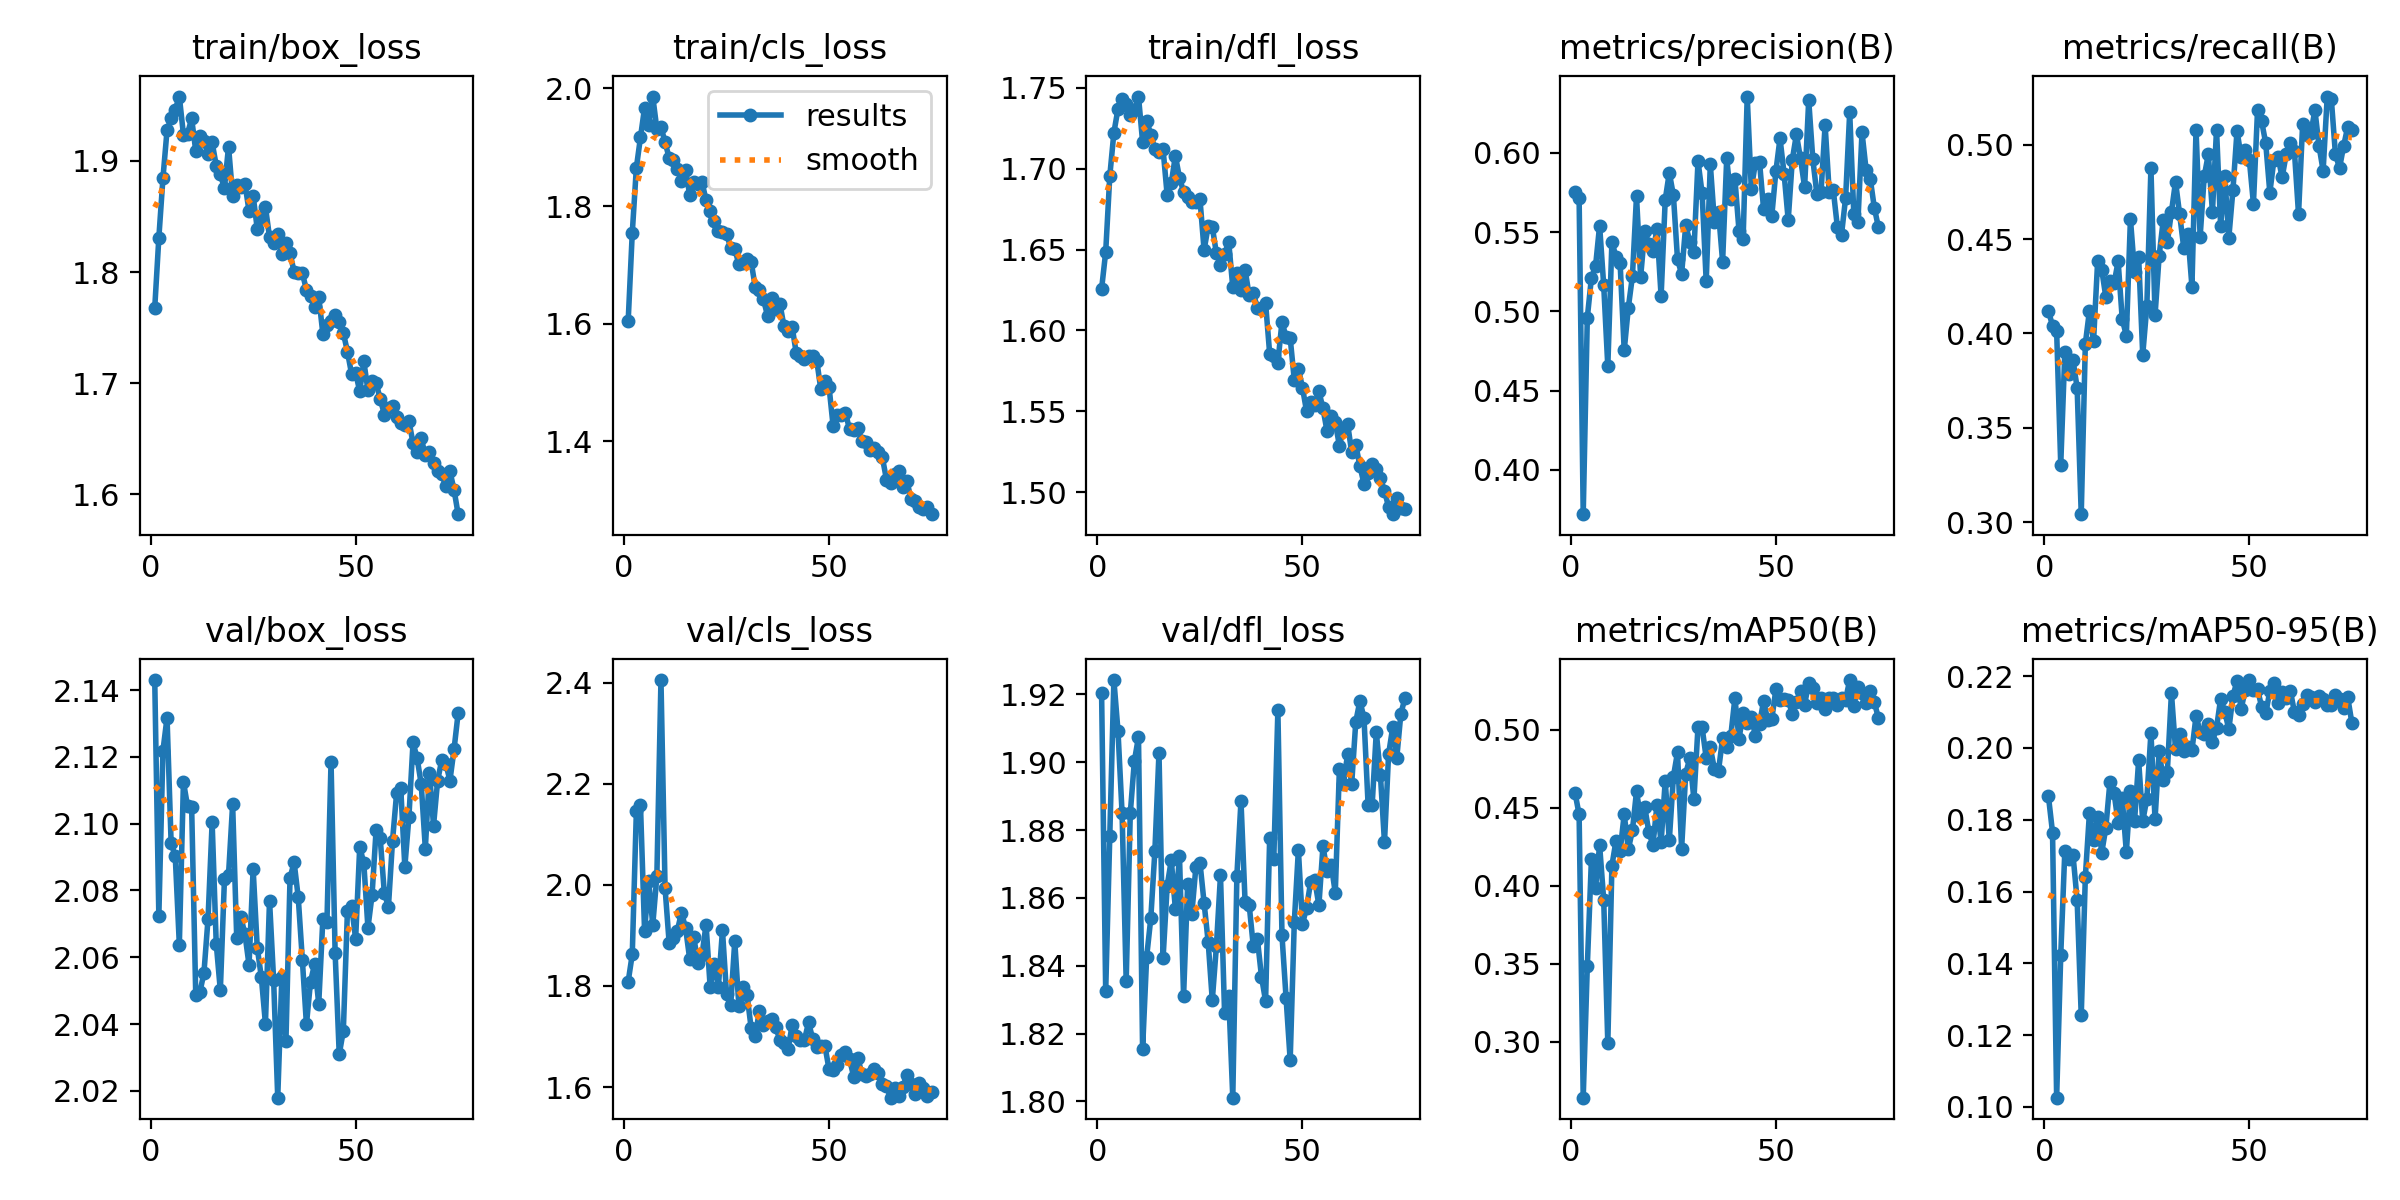


──────────────────────────────────────────────────
Confusion Matrix
──────────────────────────────────────────────────


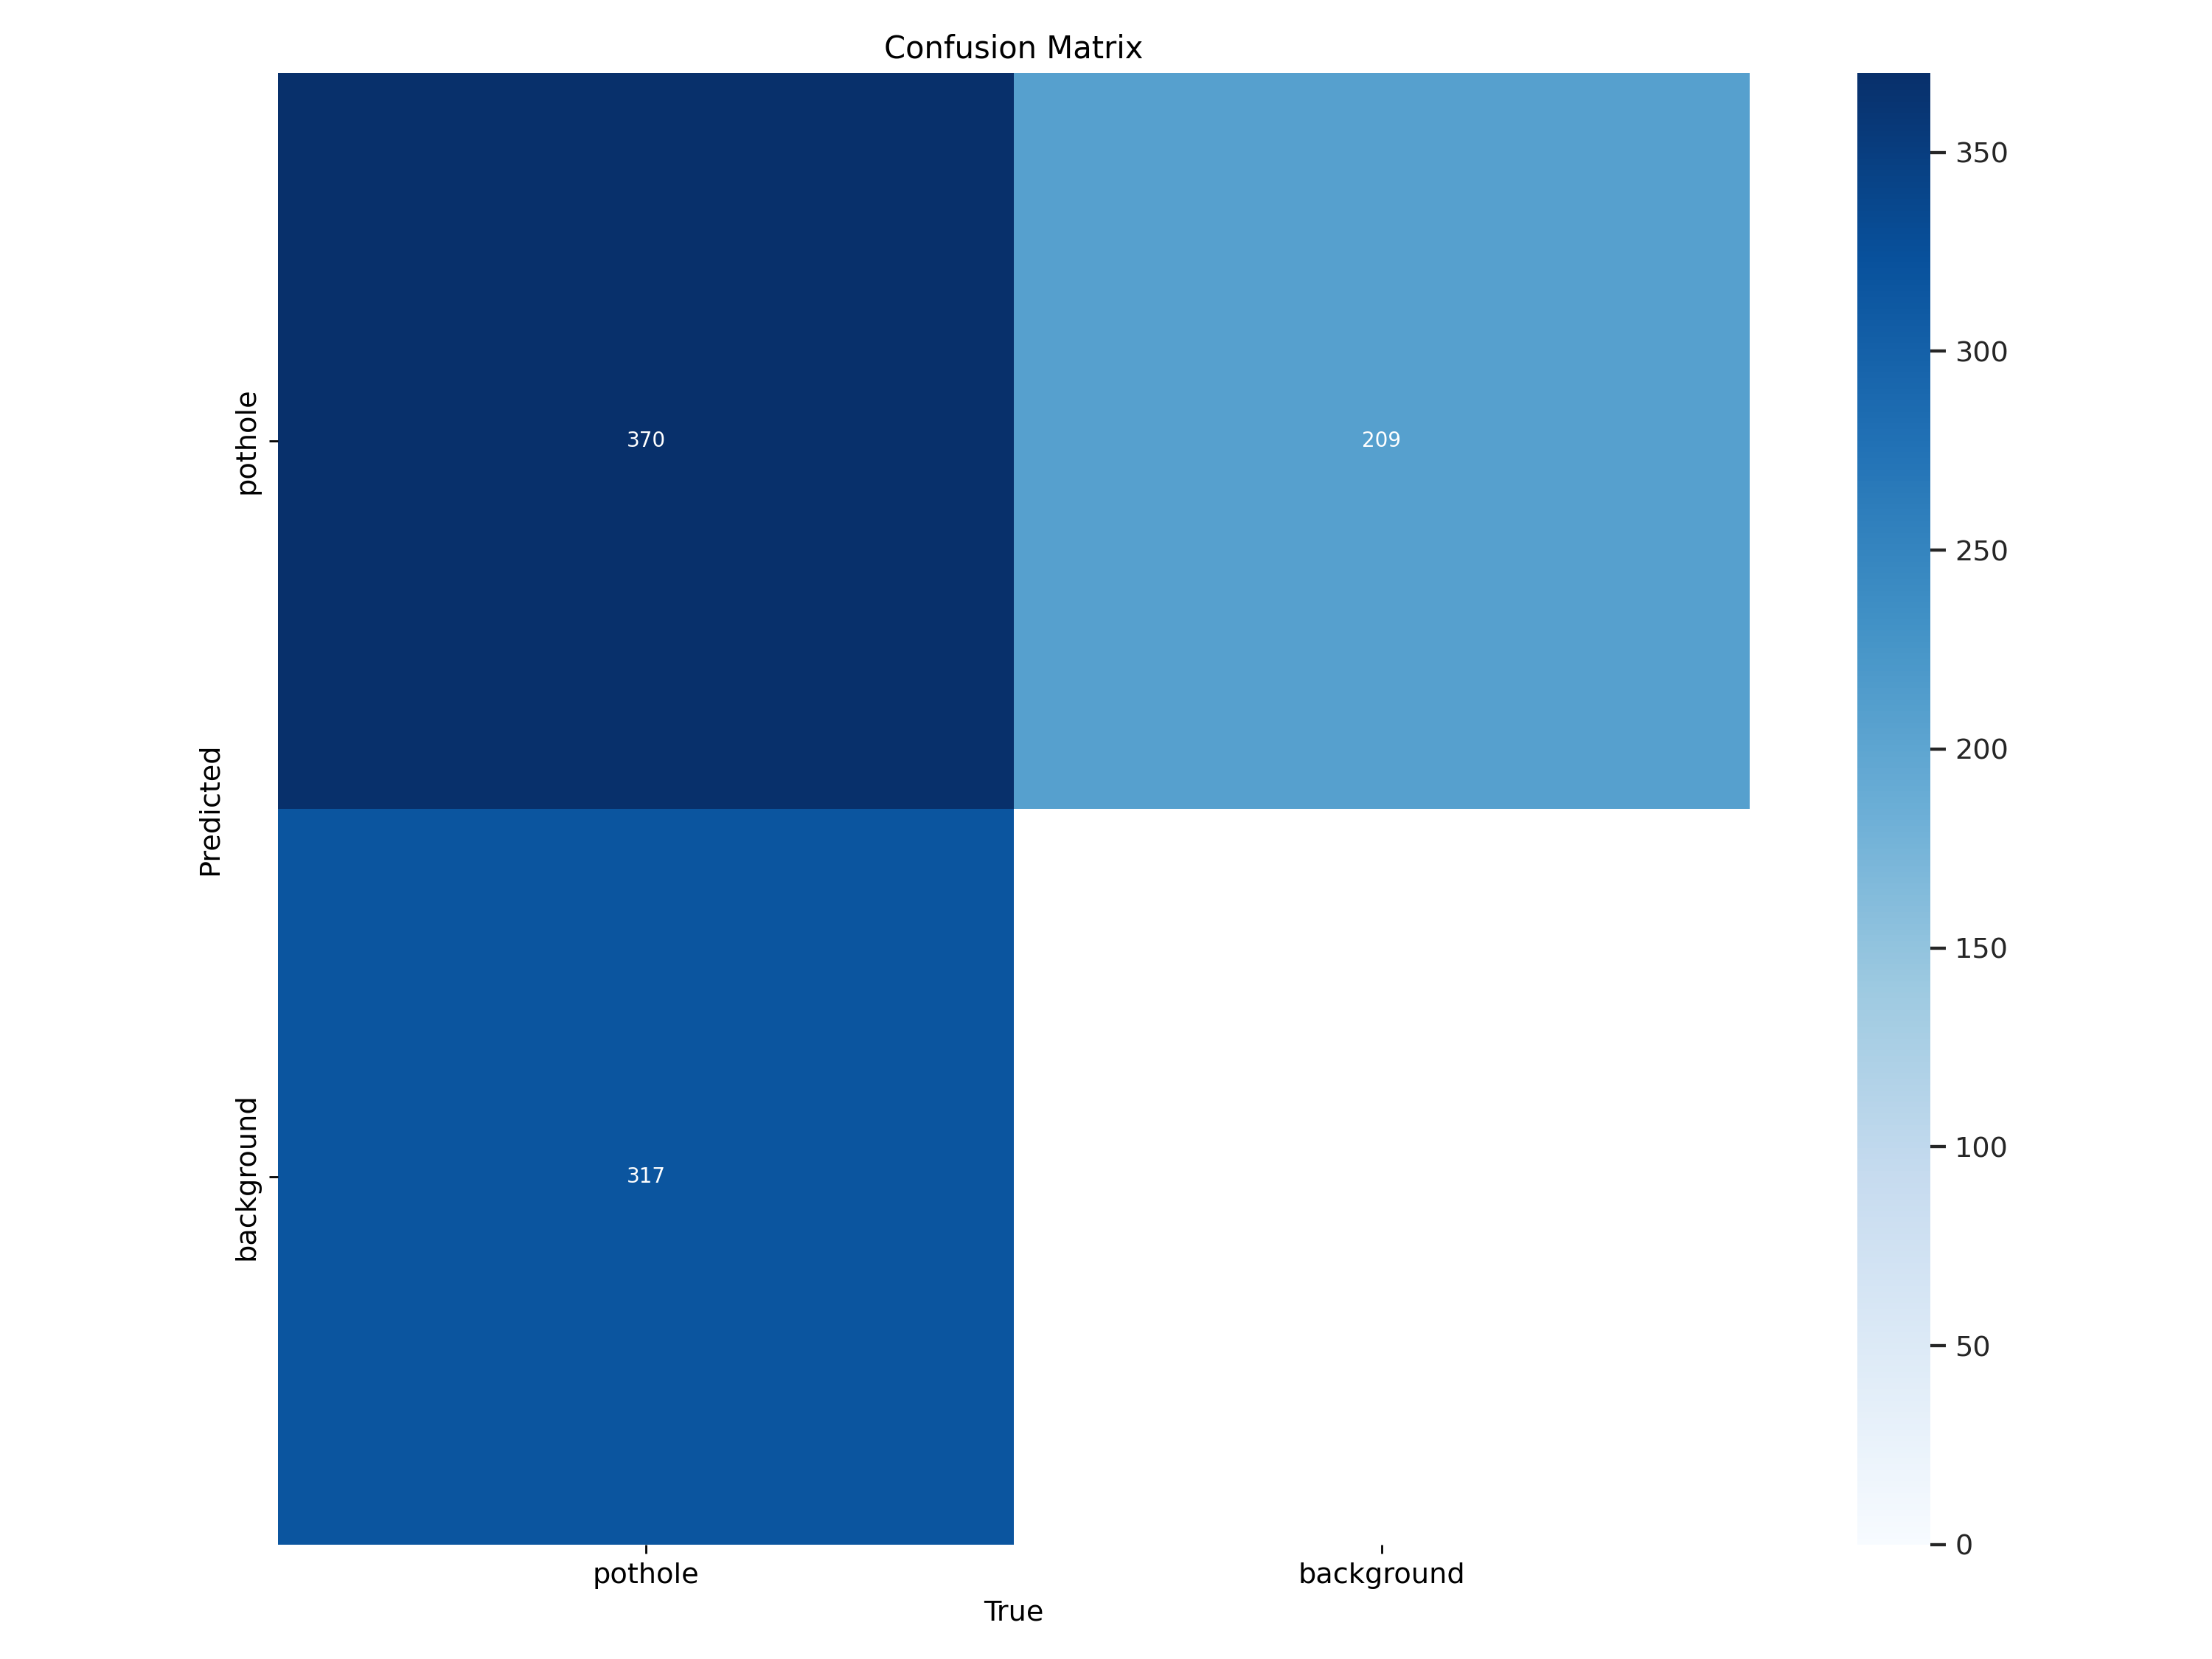


──────────────────────────────────────────────────
Confusion Matrix (Normalised)
──────────────────────────────────────────────────


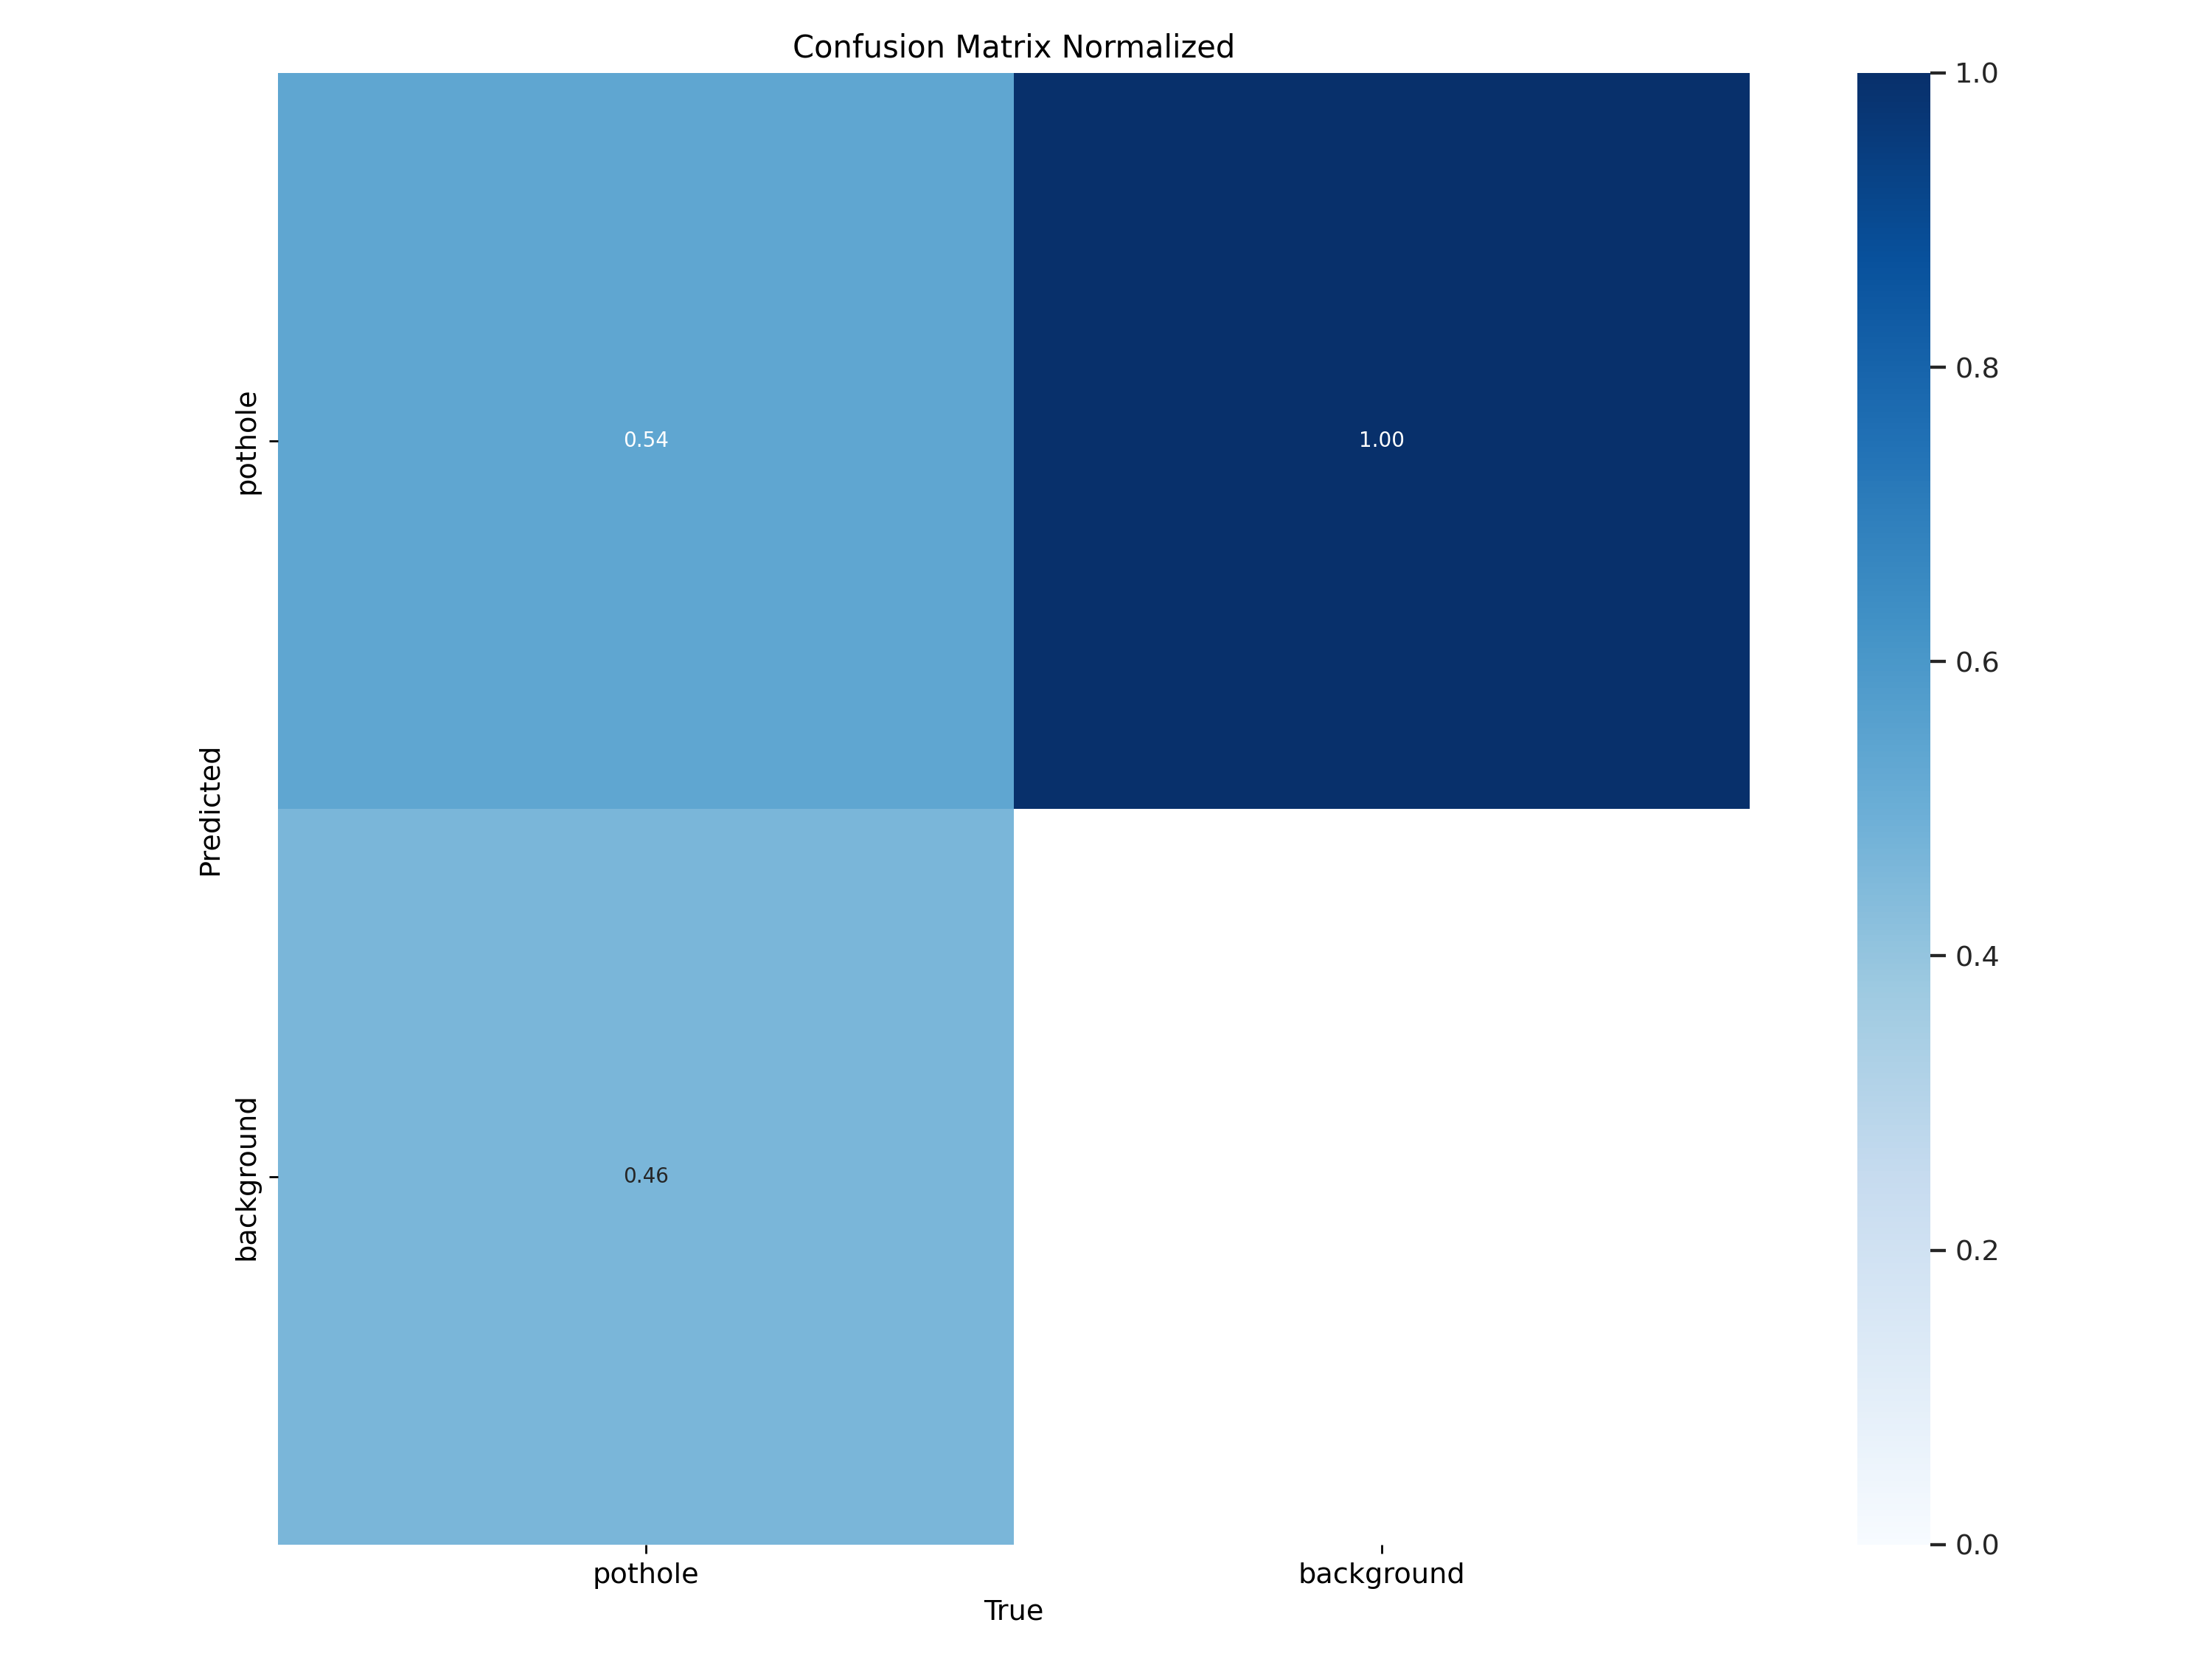


──────────────────────────────────────────────────
Sample Predictions (Batch 0)
──────────────────────────────────────────────────


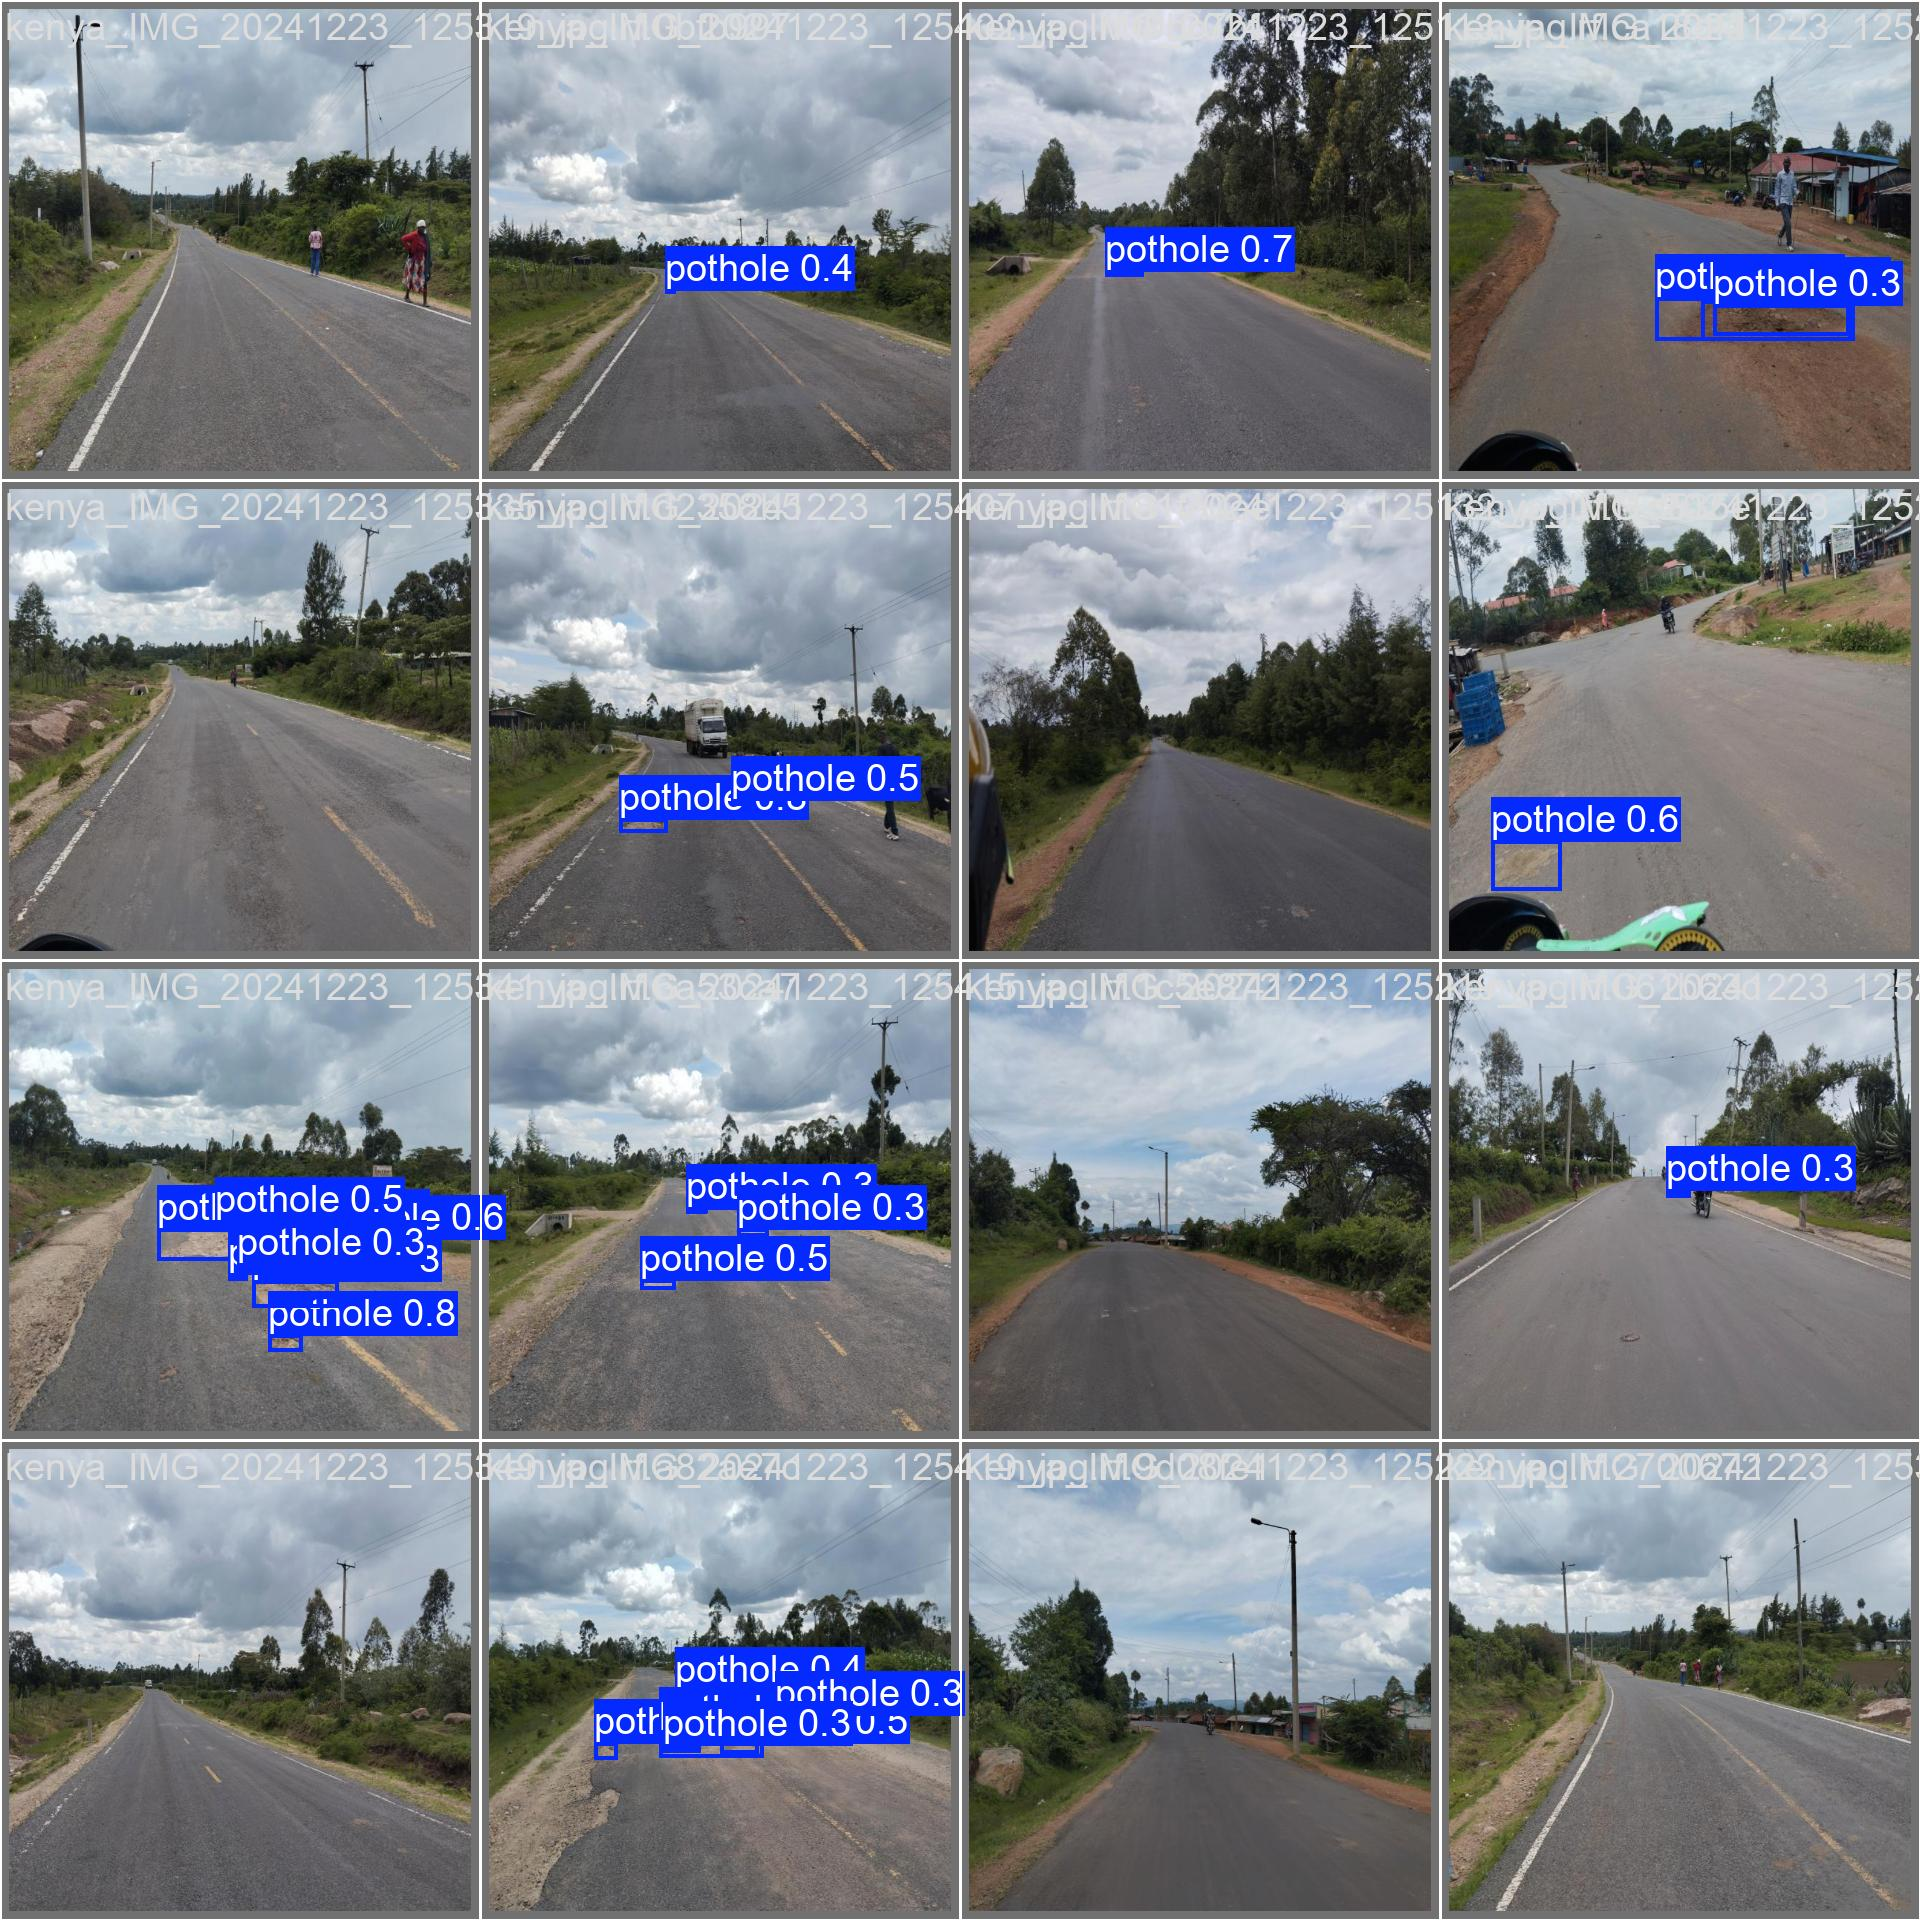


──────────────────────────────────────────────────
Sample Predictions (Batch 1)
──────────────────────────────────────────────────


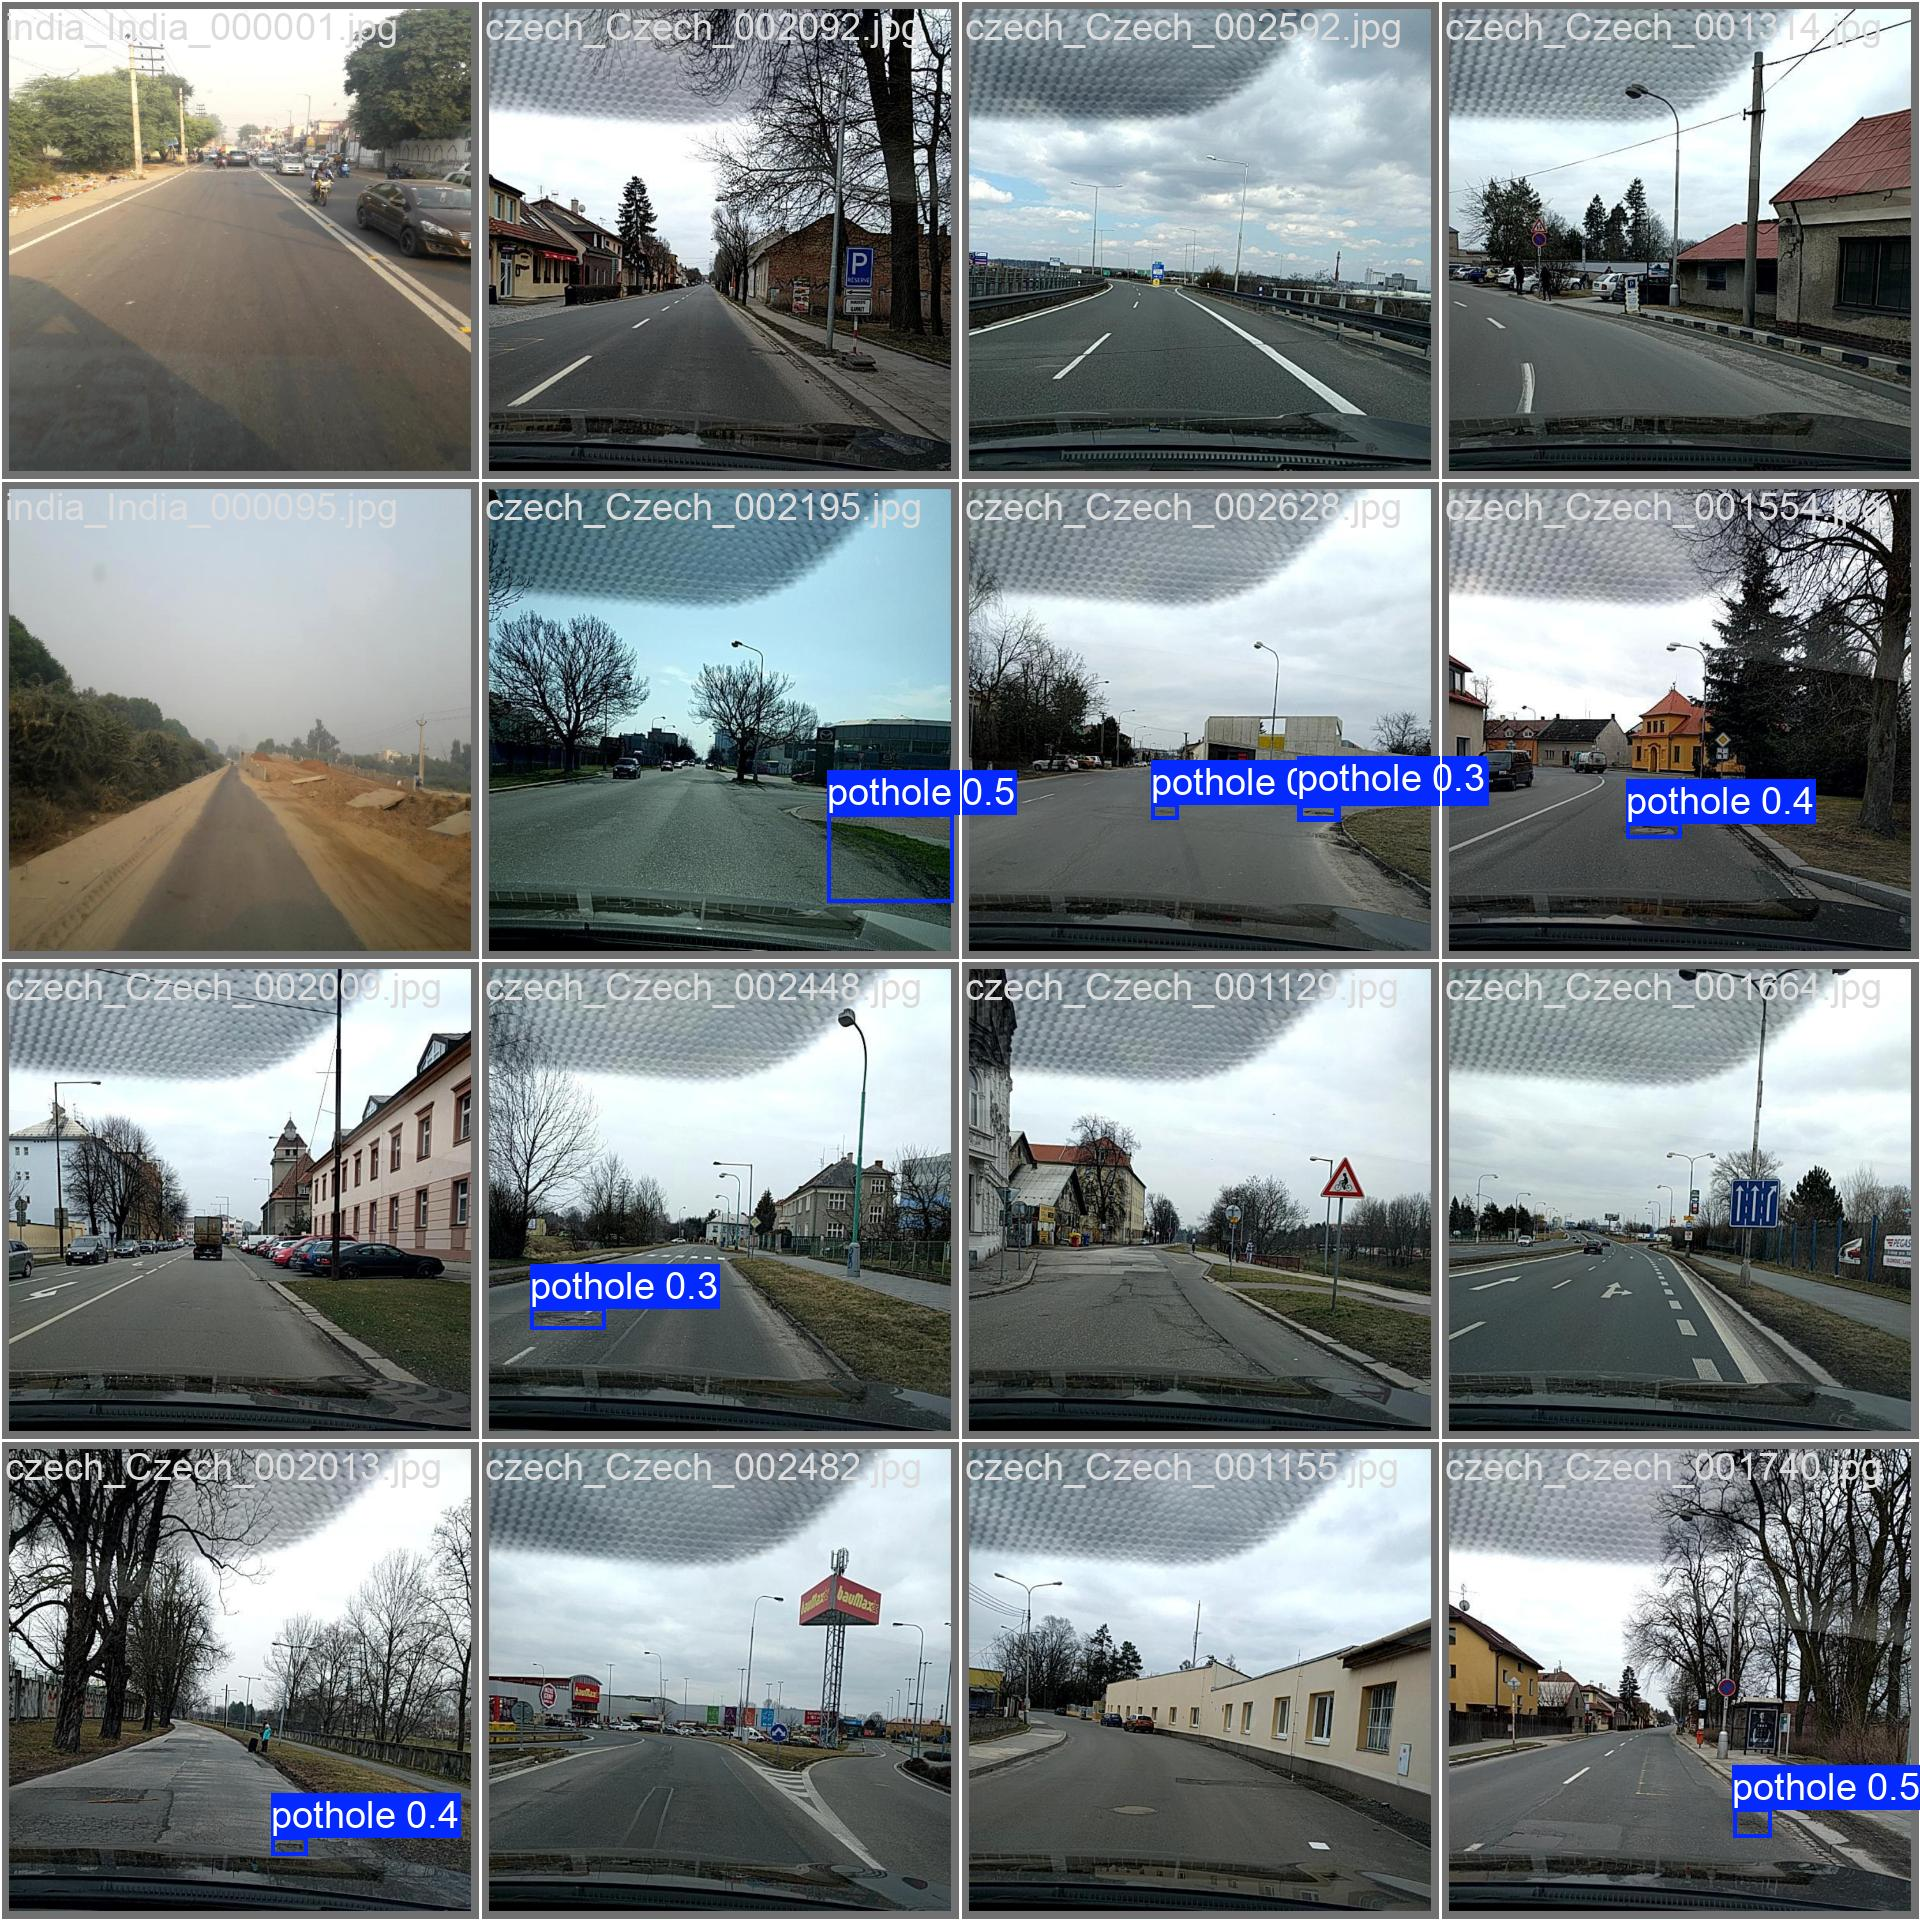


──────────────────────────────────────────────────
Precision-Recall Curve
──────────────────────────────────────────────────


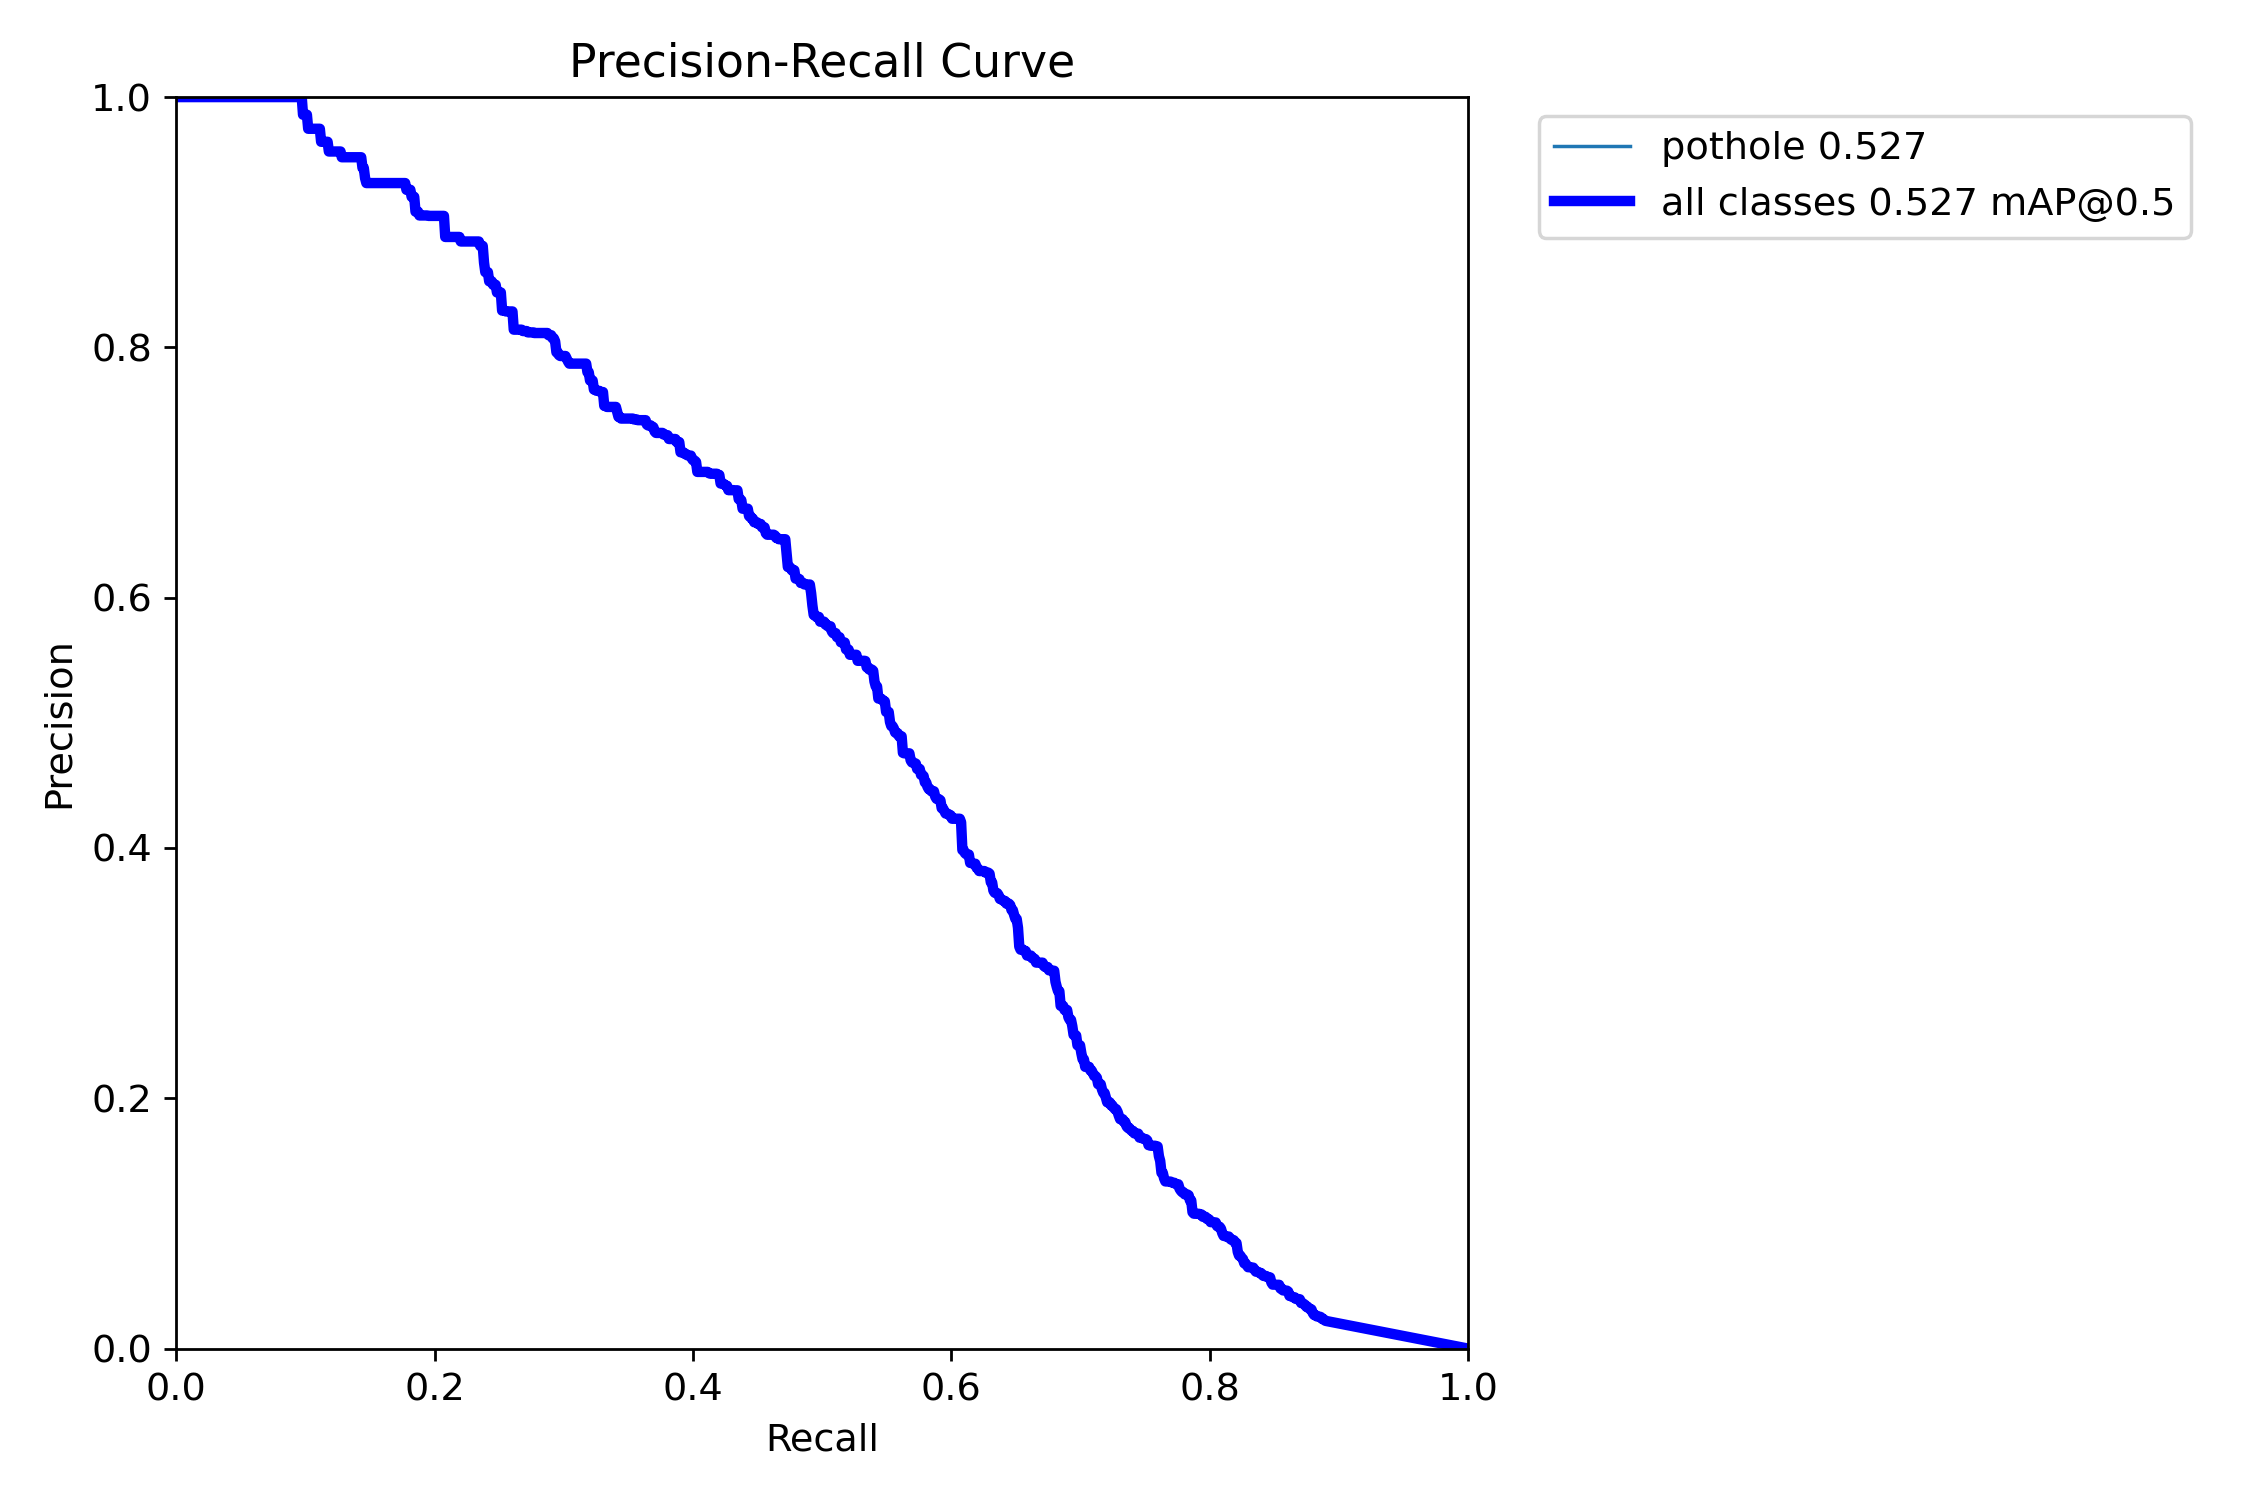


──────────────────────────────────────────────────
F1 Score Curve
──────────────────────────────────────────────────


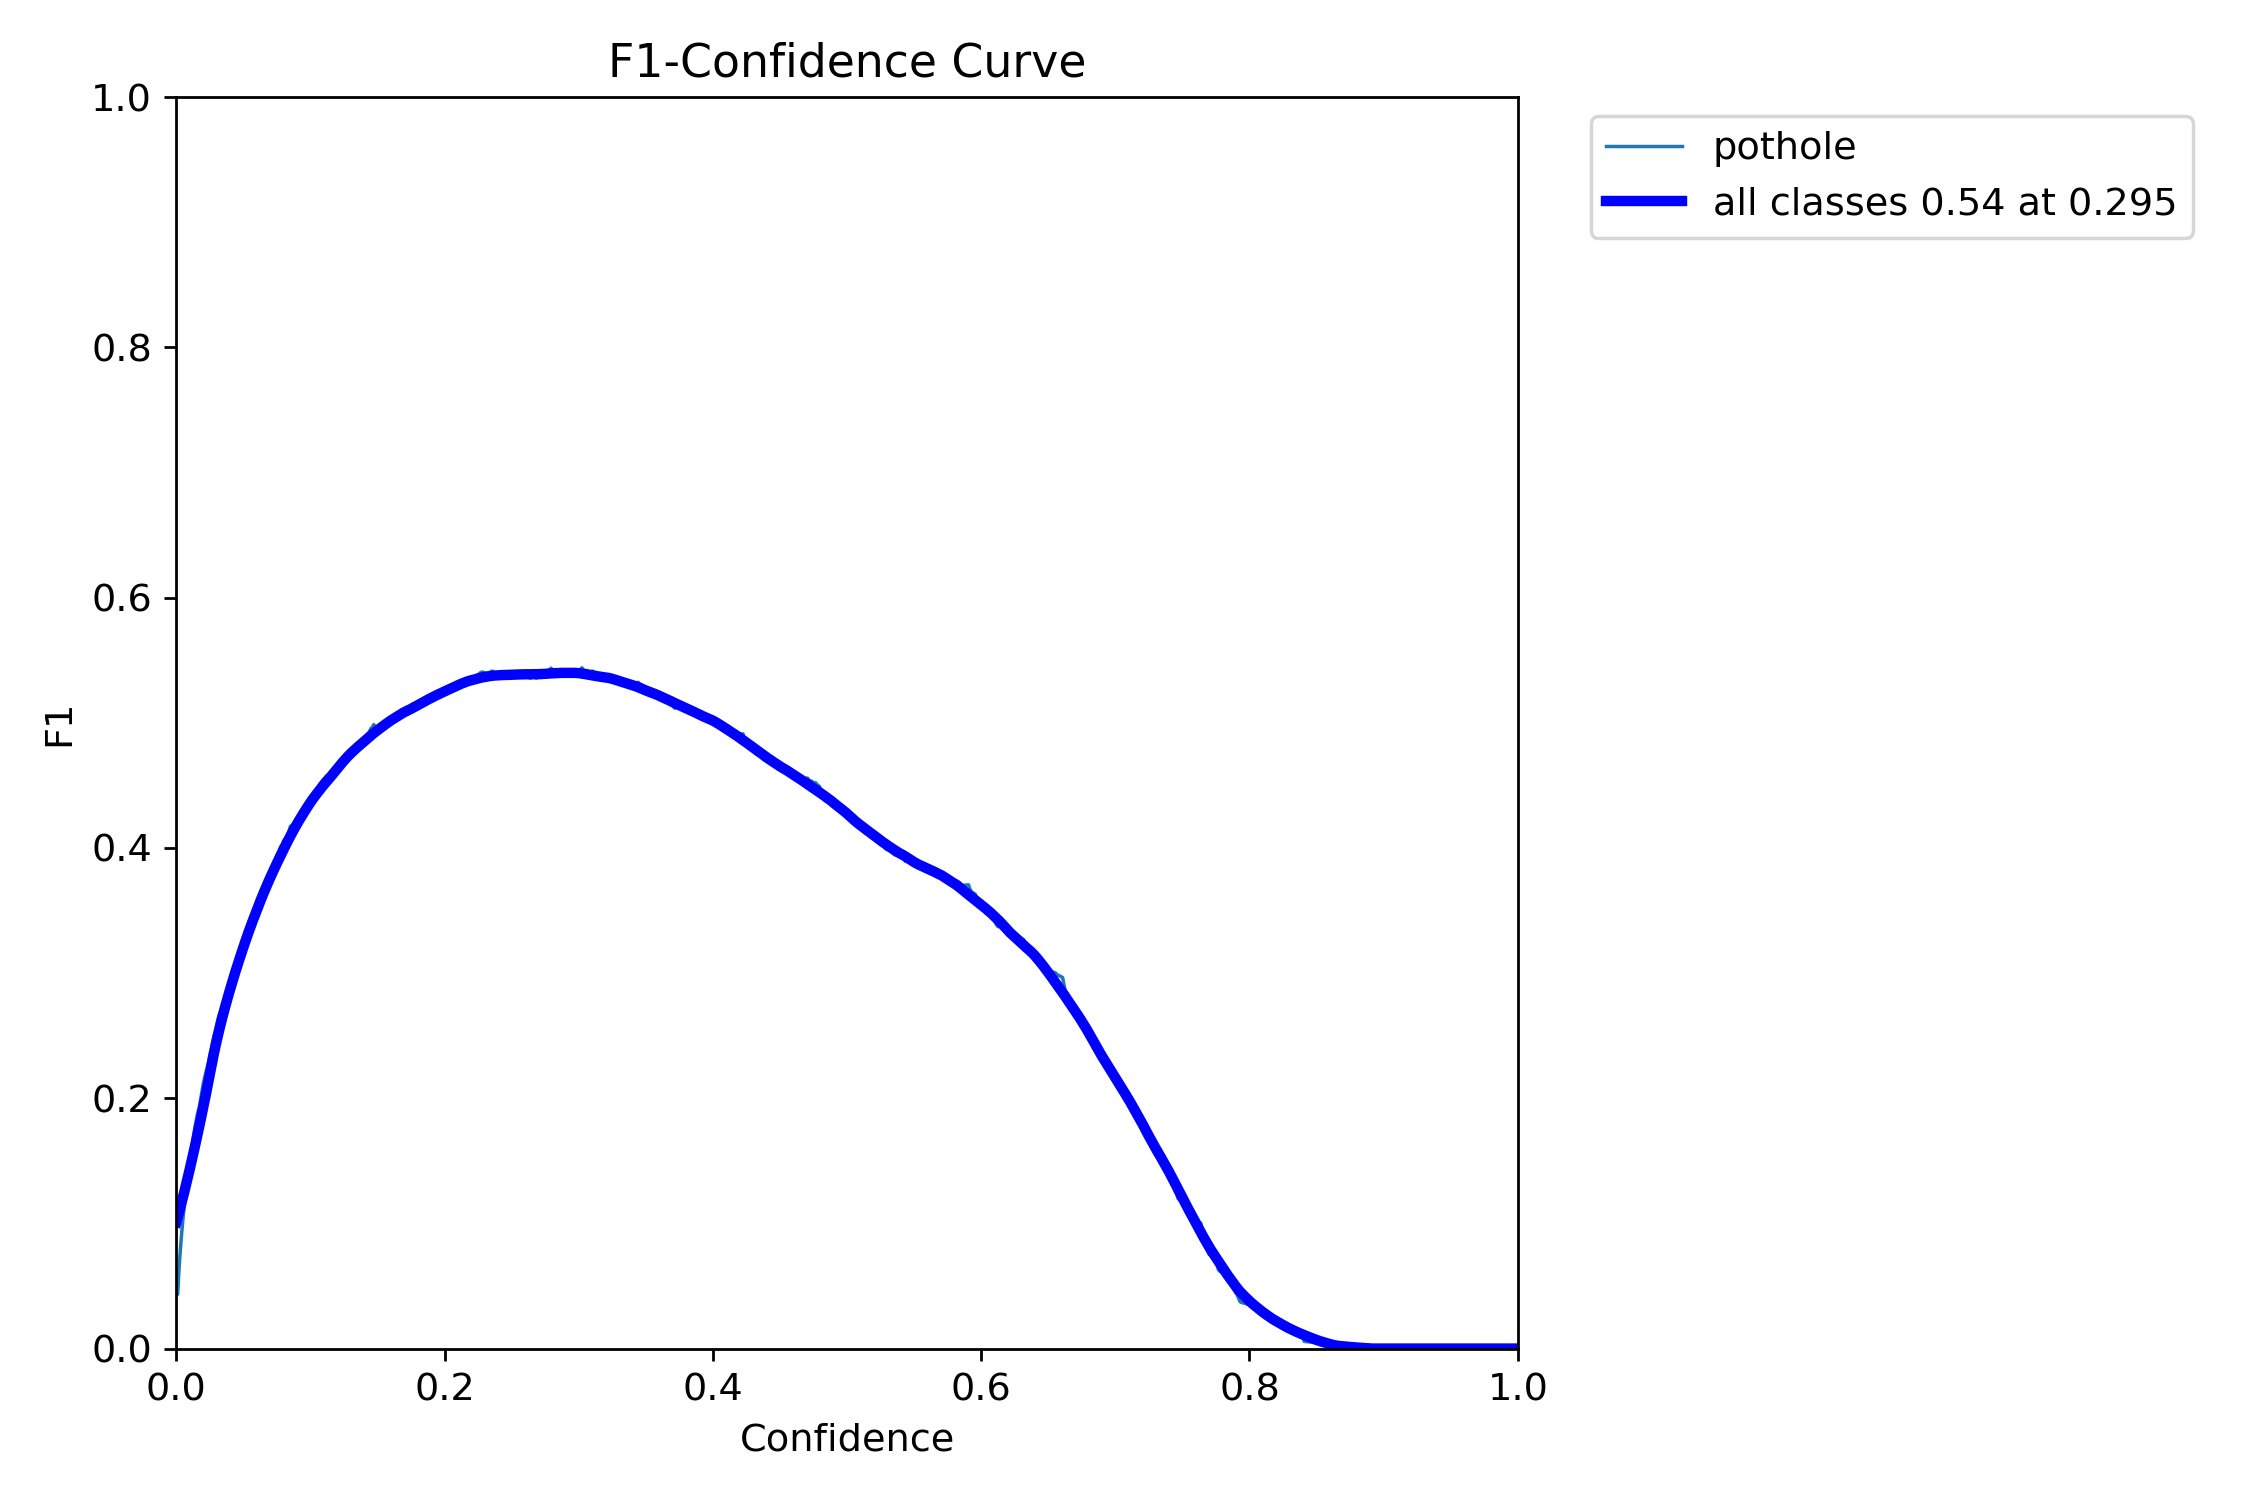


📊 Detailed training curves:


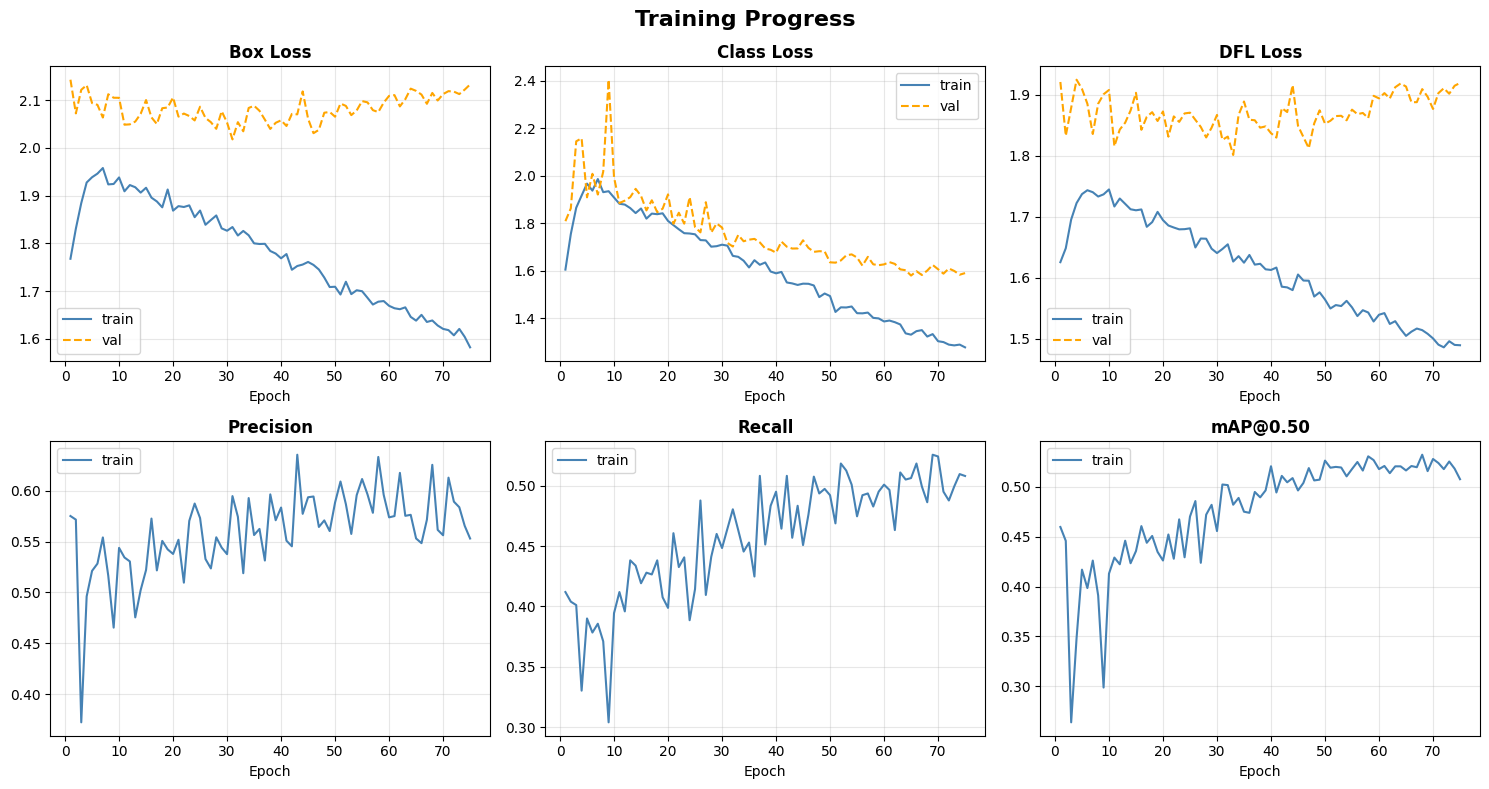

✅ Custom training curves plotted


In [17]:
# ============================================================
# SECTION 6: EVALUATE TRAINING RESULTS
# ============================================================
#
# After training, YOLO saves these files in the run folder:
#
#   results.png       → shows how loss and accuracy changed
#                       over every epoch. Loss should go DOWN.
#                       mAP should go UP.
#
#   confusion_matrix  → a grid showing what the model gets
#                       right and wrong. Diagonal = good.
#
#   val_batch_pred    → actual images with boxes drawn on them
#                       showing what the model predicted
#
# What is mAP50?
#   mAP50 = mean Average Precision at 50% overlap threshold.
#   A predicted box counts as correct if it overlaps the
#   real box by at least 50%.
#   Score ranges from 0.0 (useless) to 1.0 (perfect).
#   A score of 0.6+ is good for a first training run.
# ============================================================

import glob

RUN_NAME = "pothole_yolo11s_v3"

# Find the run folder (handles auto-numbering like _v12, _v13)
matching = glob.glob(f"{HOME}/runs/detect/{RUN_NAME}*/")
if not matching:
    # Try Drive backup
    matching = glob.glob(f"{DRIVE_RUNS}/{RUN_NAME}*/")

if not matching:
    print(f"❌ No training run found named '{RUN_NAME}'")
    print("   Make sure Section 4 completed successfully.")
else:
    RUN_DIR = max(matching, key=os.path.getmtime)
    print(f"✅ Loading results from: {RUN_DIR}\n")
    plot_training_results(RUN_DIR)

    # Also plot custom CSV curves
    csv_path = os.path.join(RUN_DIR, 'results.csv')
    if os.path.exists(csv_path):
        print("\n📊 Detailed training curves:")
        plot_training_csv(csv_path)

In [18]:
# ============================================================
# SECTION 6B: VALIDATE ON TEST SET
# ============================================================
#
# The test set contains images the model has NEVER seen.
# Not during training. Not during validation.
# This gives us the most honest accuracy number.
#
# The key number to look for: mAP50
# A model with mAP50 = 0.65 means: when the model draws a box
# around something it thinks is a pothole, it is right 65%
# of the time AND it finds 65% of the potholes in the image.
# ============================================================

DATA_YAML = f"{COMBINED_DIR}/data.yaml"
BEST_PT   = os.path.join(RUN_DIR, 'weights', 'best.pt')

if not os.path.exists(BEST_PT):
    print(f"❌ No trained weights at: {BEST_PT}")
    print("   Run Section 4 or Section 5 first.")
else:
    print(f"✅ Evaluating: {BEST_PT}\n")

    !yolo task=detect mode=val \
          model={BEST_PT} \
          data={DATA_YAML} \
          plots=True

    print("\n✅ Validation complete.")
    print("   Look for 'mAP50' in the table above.")
    print("   0.5+ = good  |  0.7+ = very good  |  0.85+ = excellent")

✅ Evaluating: /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v3/weights/best.pt

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Scanning /content/datasets/combined/valid/labels.cache... 666 images, 319 backgrounds, 0 corrupt: 100% 666/666 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 42/42 [00:12<00:00,  3.25it/s]
                   all        666        687      0.588      0.495      0.529       0.22
Speed: 1.3ms preprocess, 13.3ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val

✅ Validation complete.
   Look for 'mAP50' in the table above.
   0.5+ = good  |  0.7+ = very good  |  0.85+ = excellent


🔍 Running pothole detection on test images...
   Model: /content/drive/MyDrive/PotholeAI/runs/pothole_yolo11s_v3/weights/best.pt
   Images: /content/datasets/combined/test/images

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

image 1/642 /content/datasets/combined/test/images/czech_Czech_000086.jpg: 800x800 1 pothole, 20.5ms
image 2/642 /content/datasets/combined/test/images/czech_Czech_000263.jpg: 800x800 (no detections), 20.6ms
image 3/642 /content/datasets/combined/test/images/czech_Czech_000293.jpg: 800x800 3 potholes, 20.6ms
image 4/642 /content/datasets/combined/test/images/czech_Czech_000298.jpg: 800x800 (no detections), 20.5ms
image 5/642 /content/datasets/combined/test/images/czech_Czech_000337.jpg: 800x800 (no detections), 20.5ms
image 6/642 /content/datasets/combined/test/images/czech_Czech_000392.jpg: 800x800 1 pothole, 20.6ms
image 7/642 /content/datase

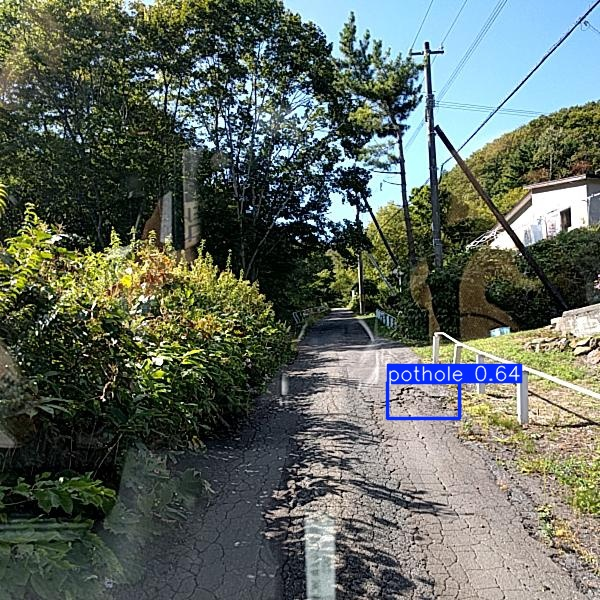


  czech_Czech_000458.jpg


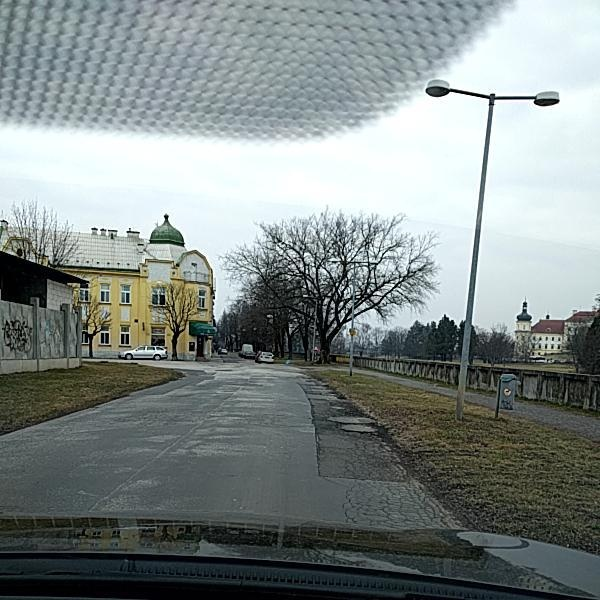


  india_India_001717.jpg


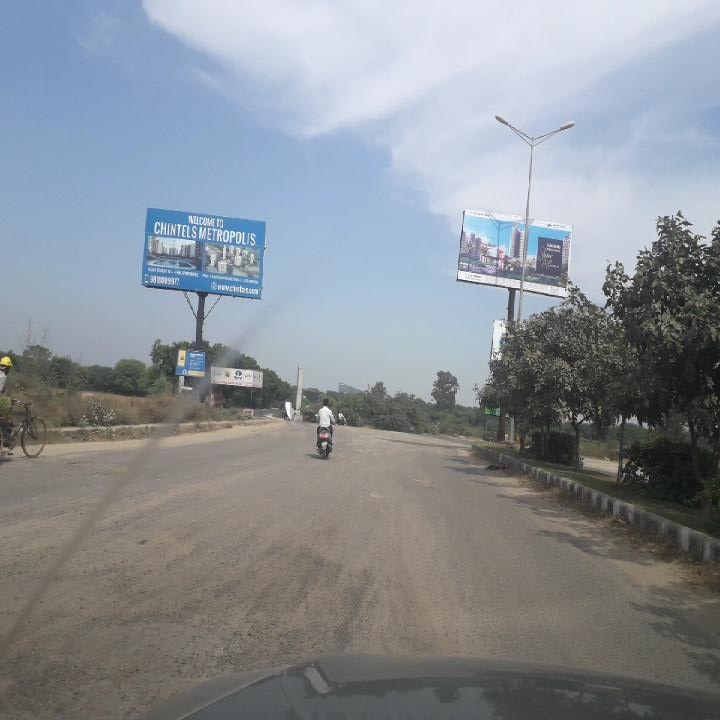


  kenya_IMG_20241223_130013_jpg.rf.4b892ff4bc151f529034d0dbe021bfcf.jpg


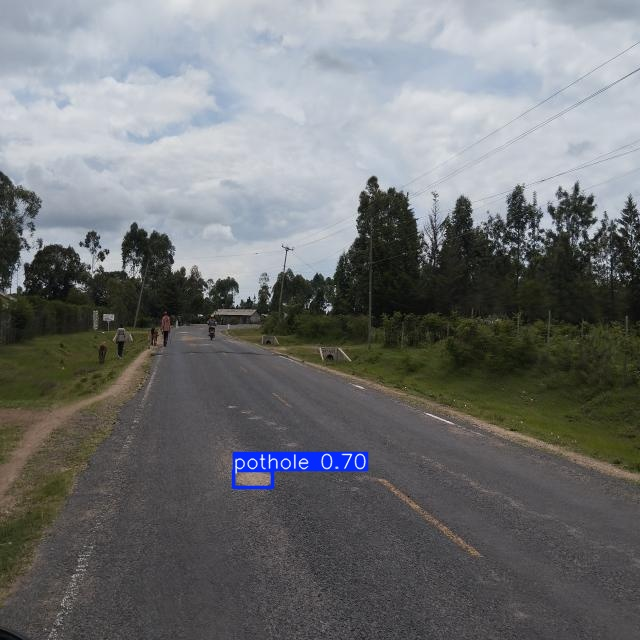

In [19]:
# ============================================================
# SECTION 7: RUN THE MODEL ON NEW ROAD IMAGES
# ============================================================
#
# This is the most exciting part.
# We take images from the test set (ones the model never saw)
# and ask the model to find potholes in them.
#
# The model draws a bounding box around each pothole it finds.
# Next to each box it shows a confidence score (0.0 to 1.0).
# For example: "pothole 0.87" means the model is 87% confident
# that what it found is a pothole.
#
# conf=0.25 means: only show detections the model is at
# least 25% confident about. Lower = shows more (including
# wrong ones). Higher = shows fewer (only very confident ones).
# ============================================================

DATA_YAML  = f"{COMBINED_DIR}/data.yaml"
BEST_PT    = os.path.join(RUN_DIR, 'weights', 'best.pt')
TEST_IMGS  = f"{COMBINED_DIR}/test/images"

import yaml
with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)
test_path = cfg.get('test', TEST_IMGS)

if not os.path.exists(BEST_PT):
    print("❌ No trained model found. Run Section 4 first.")
elif not os.path.exists(test_path):
    print(f"❌ Test images not found at: {test_path}")
else:
    os.chdir(HOME)
    print(f"🔍 Running pothole detection on test images...")
    print(f"   Model: {BEST_PT}")
    print(f"   Images: {test_path}\n")

    !yolo task=detect mode=predict \
          model={BEST_PT} \
          conf=0.25 \
          source={test_path} \
          save=True \
          name=pothole_predictions

    # Display random sample of predictions
    pred_dirs = glob.glob(f'{HOME}/runs/detect/pothole_predictions*/')
    if pred_dirs:
        latest = max(pred_dirs, key=os.path.getmtime)
        show_random_predictions(latest, n=4)
    else:
        print("❌ No prediction output found")

**Drive folder for uploading new road images + running detection**

In [18]:
# ============================================================
# CREATE UPLOAD FOLDER FOR NEW ROAD PHOTOS
# ============================================================
NEW_IMAGES_DIR = f"{DRIVE_ROOT}/new_road_images"
os.makedirs(NEW_IMAGES_DIR, exist_ok=True)
print(f"✅ Upload folder ready:")
print(f"   {NEW_IMAGES_DIR}")
print(f"\n   In Google Drive: My Drive → PotholeAI → new_road_images")
print(f"   Drop any road photos there directly — no re-upload to Colab needed.")

✅ Upload folder ready:
   /content/drive/MyDrive/PotholeAI/new_road_images

   In Google Drive: My Drive → PotholeAI → new_road_images
   Drop any road photos there directly — no re-upload to Colab needed.


**RUN DETECTION ON NEW UPLOADED IMAGES**

In [14]:
NEW_IMAGES_DIR = f"{DRIVE_ROOT}/new_road_images"
print(f"Checking: {NEW_IMAGES_DIR}\n")

if os.path.exists(NEW_IMAGES_DIR):
    all_files = os.listdir(NEW_IMAGES_DIR)
    print(f"Total items found: {len(all_files)}")
    for f in all_files:
        print(f"  - {f}")
else:
    print("❌ Folder doesn't exist at all")

Checking: /content/drive/MyDrive/PotholeAI/new_road_images

Total items found: 5
  - pothole.jpeg
  - iStock-655985038.jpg
  - Asphalt-Tarmac-Pothole-Repairs-Livingston.jpg
  - images (2).jpg
  - images (3).jpg


✅ Found 5 images to test
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

image 1/5 /content/drive/MyDrive/PotholeAI/new_road_images/Asphalt-Tarmac-Pothole-Repairs-Livingston.jpg: 352x800 (no detections), 80.3ms
image 2/5 /content/drive/MyDrive/PotholeAI/new_road_images/iStock-655985038.jpg: 384x800 2 potholes, 98.9ms
image 3/5 /content/drive/MyDrive/PotholeAI/new_road_images/images (2).jpg: 512x800 3 potholes, 53.2ms
image 4/5 /content/drive/MyDrive/PotholeAI/new_road_images/images (3).jpg: 320x800 3 potholes, 53.2ms
image 5/5 /content/drive/MyDrive/PotholeAI/new_road_images/pothole.jpeg: 544x800 1 pothole, 59.2ms
Speed: 4.2ms preprocess, 69.0ms inference, 40.2ms postprocess per image at shape (1, 3, 544, 800)
Results saved to /content/drive/MyDrive/PotholeAI/predictions/pothole_yolo11s_v3_new_images3
💡 Learn more at https://docs.ultralytics.com/modes/predict

✅ Resul

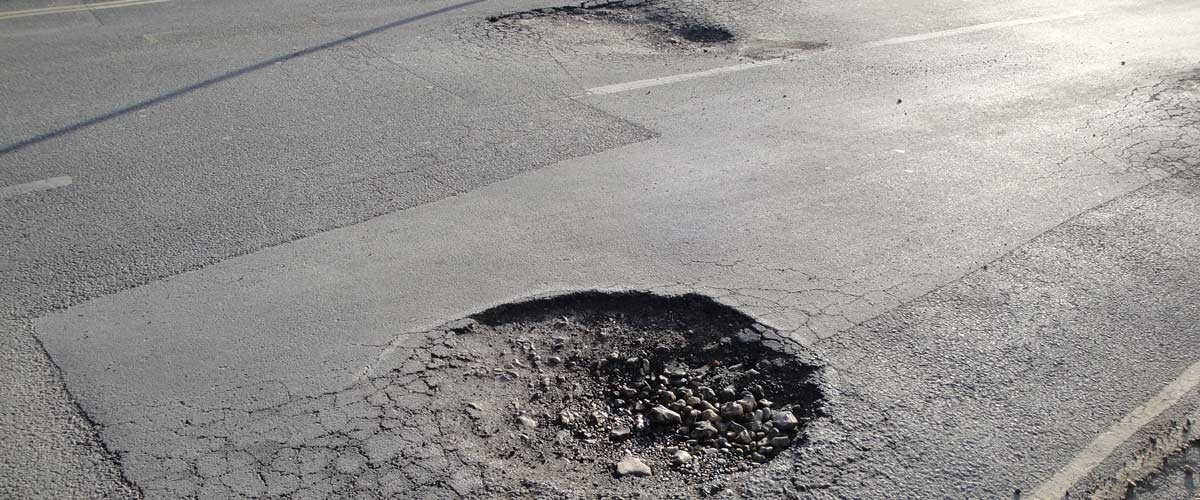

iStock-655985038.jpg


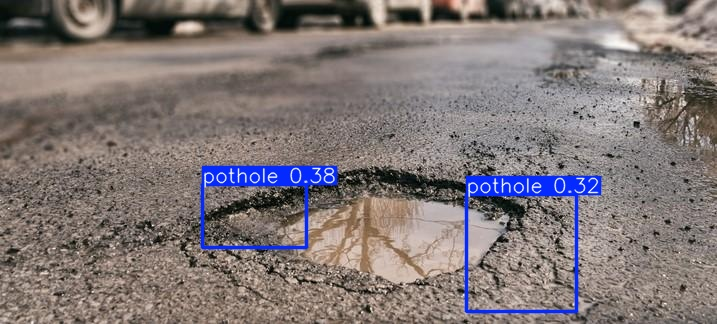

images (2).jpg


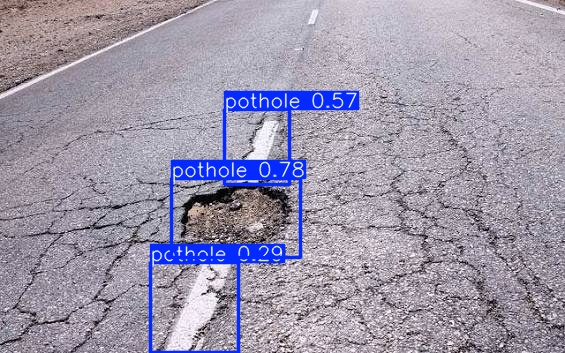

images (3).jpg


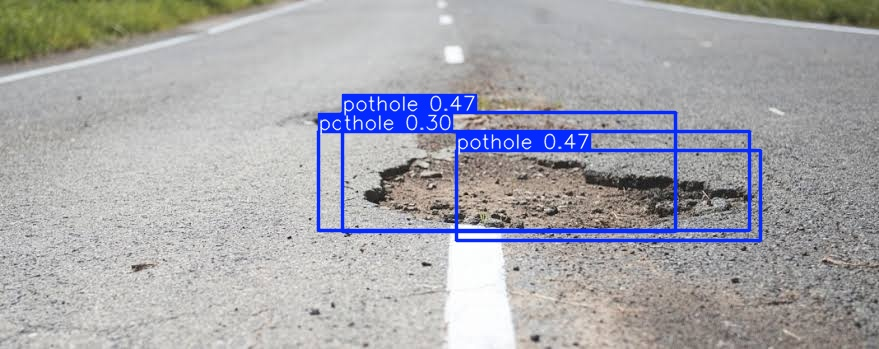

pothole.jpg


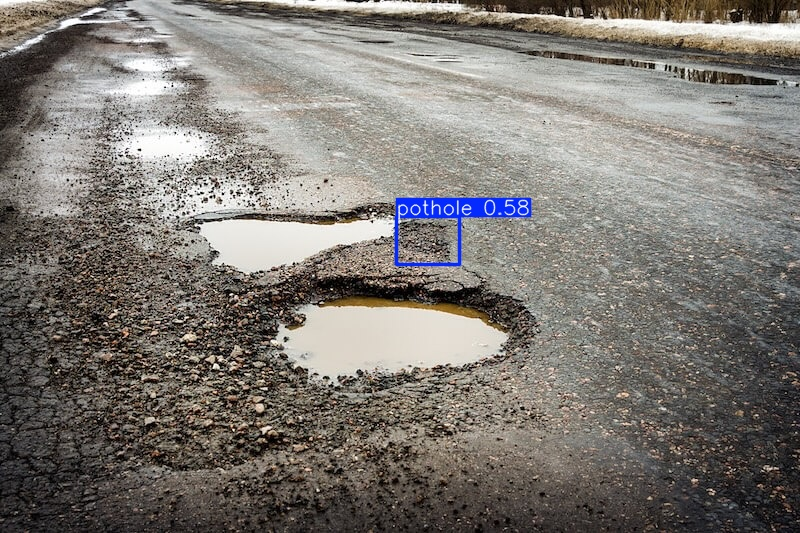

In [15]:
# ============================================================
# RUN DETECTION ON NEW UPLOADED IMAGES — results saved to Drive
# ============================================================
RUN_NAME = "pothole_yolo11s_v3"   # change to whichever model you want to test
BEST_PT  = f"{DRIVE_RUNS}/{RUN_NAME}/weights/best.pt"
NEW_IMAGES_DIR = f"{DRIVE_ROOT}/new_road_images"

assert os.path.exists(BEST_PT), f"❌ Model not found at {BEST_PT}"
n_images = len([f for f in os.listdir(NEW_IMAGES_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))])
assert n_images > 0, f"❌ No images found in {NEW_IMAGES_DIR} — upload some first"
print(f"✅ Found {n_images} images to test")

os.chdir(HOME)
!yolo task=detect mode=predict \
      model={BEST_PT} \
      conf=0.25 \
      source={NEW_IMAGES_DIR} \
      save=True \
      project={DRIVE_ROOT}/predictions \
      name={RUN_NAME}_new_images

print(f"\n✅ Results saved to: {DRIVE_ROOT}/predictions/{RUN_NAME}_new_images/")

# Display them
from IPython.display import display, Image as IPyImage
import glob
pred_dirs = sorted(glob.glob(f"{DRIVE_ROOT}/predictions/{RUN_NAME}_new_images*/"))
if pred_dirs:
    for img in glob.glob(f"{pred_dirs[-1]}/*.jpg"):
        print(os.path.basename(img))
        display(IPyImage(filename=img, width=640))